In [10]:
# ============================================================
# SIGNALDRAW NOTEBOOK WIDGET
# ============================================================
#
# INSTALL:
#
# pip install anywidget traitlets numpy plotly
#
# ============================================================

import anywidget
import traitlets
import numpy as np


class SignalDraw(anywidget.AnyWidget):

    # ========================================================
    # FRONTEND
    # ========================================================

    _esm = r"""
    import * as Plotly from "https://cdn.plot.ly/plotly-2.35.2.min.js";

    export function render({ model, el }) {

        // ====================================================
        // ROOT LAYOUT
        // ====================================================

        const root = document.createElement("div");

        root.style.display = "flex";
        root.style.flexDirection = "row";
        root.style.gap = "20px";
        root.style.fontFamily = "Arial";

        el.appendChild(root);

        // ====================================================
        // CONTROL PANEL
        // ====================================================

        const controls = document.createElement("div");

        controls.style.width = "300px";

        root.appendChild(controls);

        // ====================================================
        // PLOT
        // ====================================================

        const plotDiv = document.createElement("div");

        plotDiv.style.width = "900px";
        plotDiv.style.height = "500px";

        root.appendChild(plotDiv);

        // ====================================================
        // SLIDER FACTORY
        // ====================================================

        function createSlider(
            label,
            min,
            max,
            step,
            value
        ) {

            const container = document.createElement("div");

            container.style.marginBottom = "15px";

            const text = document.createElement("div");

            text.innerText = label + ": " + value;

            text.style.marginBottom = "5px";

            const slider = document.createElement("input");

            slider.type = "range";

            slider.min = min;
            slider.max = max;
            slider.step = step;
            slider.value = value;

            slider.style.width = "100%";

            container.appendChild(text);
            container.appendChild(slider);

            controls.appendChild(container);

            return {
                slider,
                text,
                label
            };
        }

        // ====================================================
        // CREATE CONTROLS
        // ====================================================

        const freq1 = createSlider(
            "Freq 1 (Hz)",
            1,
            50,
            1,
            5
        );

        const amp1 = createSlider(
            "Amp 1",
            0,
            5,
            0.1,
            1
        );

        const freq2 = createSlider(
            "Freq 2 (Hz)",
            1,
            50,
            1,
            15
        );

        const amp2 = createSlider(
            "Amp 2",
            0,
            5,
            0.1,
            1
        );

        const noise = createSlider(
            "Noise",
            0,
            1,
            0.01,
            0.05
        );

        // ====================================================
        // BUTTONS
        // ====================================================

        const exportBtn = document.createElement("button");

        exportBtn.innerText =
            "Copy CSV to Clipboard";

        exportBtn.style.width = "100%";
        exportBtn.style.padding = "10px";
        exportBtn.style.marginTop = "20px";

        controls.appendChild(exportBtn);

        // ====================================================
        // SIGNAL GENERATOR
        // ====================================================

        function generateSignal() {

            const fs = 500;

            const duration = 2;

            const N = fs * duration;

            let t = [];

            let x = [];

            for(let i=0; i<N; i++) {

                const time = i / fs;

                const s1 =
                    parseFloat(amp1.slider.value) *
                    Math.sin(
                        2 *
                        Math.PI *
                        parseFloat(freq1.slider.value) *
                        time
                    );

                const s2 =
                    parseFloat(amp2.slider.value) *
                    Math.sin(
                        2 *
                        Math.PI *
                        parseFloat(freq2.slider.value) *
                        time
                    );

                const n =
                    parseFloat(noise.slider.value) *
                    (Math.random() * 2 - 1);

                const y = s1 + s2 + n;

                t.push(time);

                x.push(y);
            }

            return {
                t,
                x
            };
        }

        // ====================================================
        // UPDATE FUNCTION
        // ====================================================

        async function updatePlot() {

            const signal = generateSignal();

            // ================================================
            // UPDATE PLOT
            // ================================================

            Plotly.react(
                plotDiv,
                [
                    {
                        x: signal.t,
                        y: signal.x,
                        mode: "lines",
                        name: "Signal"
                    }
                ],
                {
                    title:
                        "Interactive Signal Generator",

                    xaxis: {
                        title: "Time (s)"
                    },

                    yaxis: {
                        title: "Amplitude"
                    }
                }
            );

            // ================================================
            // SEND DATA TO PYTHON
            // ================================================

            model.set("time", [...signal.t]);

            model.set("signal", [...signal.x]);

            model.set(
                "version",
                model.get("version") + 1
            );

            await model.save_changes();
        }

        // ====================================================
        // EVENTS
        // ====================================================

        const sliders = [
            freq1,
            amp1,
            freq2,
            amp2,
            noise
        ];

        sliders.forEach(obj => {

            obj.slider.addEventListener(
                "input",
                async () => {

                    obj.text.innerText =
                        obj.label +
                        ": " +
                        obj.slider.value;

                    await updatePlot();
                }
            );
        });

        // ====================================================
        // EXPORT CSV
        // ====================================================

        exportBtn.addEventListener(
            "click",
            async () => {

                const signal = generateSignal();

                let csv = "time,signal\n";

                for(let i=0; i<signal.t.length; i++) {

                    csv +=
                        signal.t[i] +
                        "," +
                        signal.x[i] +
                        "\n";
                }

                await navigator.clipboard.writeText(csv);

                exportBtn.innerText = "Copied!";

                setTimeout(() => {

                    exportBtn.innerText =
                        "Copy CSV to Clipboard";

                }, 1000);
            }
        );

        // ====================================================
        // INITIAL PLOT
        // ====================================================

        updatePlot();
    }
    """

    # ========================================================
    # PYTHON TRAITS
    # ========================================================

    signal = traitlets.List([]).tag(sync=True)

    time = traitlets.List([]).tag(sync=True)

    version = traitlets.Int(0).tag(sync=True)

    # ========================================================
    # NUMPY HELPERS
    # ========================================================

    @property
    def signal_numpy(self):

        return np.array(self.signal)

    @property
    def time_numpy(self):

        return np.array(self.time)


# ============================================================
# CREATE WIDGET
# ============================================================

ui = SignalDraw()

ui

In [11]:
x = np.array(ui.signal)

print(x.shape)
print(x[:10])

(0,)
[]


In [8]:
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

fs = 500

X = fft(x)
freqs = fftfreq(len(x), 1/fs)

plt.plot(freqs[:len(freqs)//2],
         np.abs(X[:len(X)//2]))
plt.xlabel("Hz")
plt.ylabel("Magnitude")
plt.title("FFT")
plt.show()

ValueError: invalid number of data points (0) specified

In [12]:
# ============================================================
# SIGNALDRAW FRONTEND PROTOTYPE
# ============================================================
#
# INSTALL:
#
# pip install anywidget traitlets numpy plotly
#
# ============================================================

import anywidget
import traitlets
import numpy as np


class SignalDraw(anywidget.AnyWidget):

    # ========================================================
    # FRONTEND
    # ========================================================

    _esm = r"""
    import * as Plotly from "https://cdn.plot.ly/plotly-2.35.2.min.js";

    export function render({ model, el }) {

        // ====================================================
        // ROOT
        // ====================================================

        const root = document.createElement("div");

        root.style.display = "flex";
        root.style.flexDirection = "column";
        root.style.width = "100%";
        root.style.height = "100%";
        root.style.background = "#111";
        root.style.color = "white";
        root.style.fontFamily = "Arial";
        root.style.padding = "10px";
        root.style.boxSizing = "border-box";

        el.appendChild(root);

        // ====================================================
        // TOP BAR
        // ====================================================

        const topbar = document.createElement("div");

        topbar.style.display = "flex";
        topbar.style.alignItems = "center";
        topbar.style.gap = "20px";
        topbar.style.padding = "10px";
        topbar.style.background = "#1e1e1e";
        topbar.style.borderRadius = "10px";
        topbar.style.marginBottom = "10px";

        root.appendChild(topbar);

        // ====================================================
        // TITLE
        // ====================================================

        const title = document.createElement("div");

        title.innerText = "SignalDraw";

        title.style.fontSize = "24px";
        title.style.fontWeight = "bold";

        topbar.appendChild(title);

        // ====================================================
        // NUMBER OF SIGNALS
        // ====================================================

        const signalsLabel = document.createElement("div");

        signalsLabel.innerText = "#Signals";

        topbar.appendChild(signalsLabel);

        const signalsSelect = document.createElement("select");

        for(let i=1; i<=5; i++) {

            const option = document.createElement("option");

            option.value = i;
            option.text = i;

            if(i === 2) option.selected = true;

            signalsSelect.appendChild(option);
        }

        topbar.appendChild(signalsSelect);

        // ====================================================
        // NOISE CHECKBOX
        // ====================================================

        const noiseContainer = document.createElement("div");

        noiseContainer.style.display = "flex";
        noiseContainer.style.alignItems = "center";
        noiseContainer.style.gap = "5px";

        const noiseCheckbox =
            document.createElement("input");

        noiseCheckbox.type = "checkbox";

        const noiseLabel =
            document.createElement("label");

        noiseLabel.innerText = "Noise";

        noiseContainer.appendChild(noiseCheckbox);
        noiseContainer.appendChild(noiseLabel);

        topbar.appendChild(noiseContainer);

        // ====================================================
        // MAIN CONTENT
        // ====================================================

        const main = document.createElement("div");

        main.style.display = "flex";
        main.style.flexDirection = "row";
        main.style.gap = "10px";
        main.style.height = "900px";

        root.appendChild(main);

        // ====================================================
        // LEFT PANEL
        // ====================================================

        const leftPanel = document.createElement("div");

        leftPanel.style.width = "35%";
        leftPanel.style.overflowY = "auto";
        leftPanel.style.display = "flex";
        leftPanel.style.flexDirection = "column";
        leftPanel.style.gap = "10px";

        main.appendChild(leftPanel);

        // ====================================================
        // RIGHT PANEL
        // ====================================================

        const rightPanel = document.createElement("div");

        rightPanel.style.width = "65%";
        rightPanel.style.display = "flex";
        rightPanel.style.flexDirection = "column";
        rightPanel.style.gap = "10px";

        main.appendChild(rightPanel);

        // ====================================================
        // SUM SIGNAL PLOT
        // ====================================================

        const sumPlot = document.createElement("div");

        sumPlot.style.height = "50%";
        sumPlot.style.background = "#1e1e1e";
        sumPlot.style.borderRadius = "10px";

        rightPanel.appendChild(sumPlot);

        // ====================================================
        // FFT PLOT
        // ====================================================

        const fftPlot = document.createElement("div");

        fftPlot.style.height = "50%";
        fftPlot.style.background = "#1e1e1e";
        fftPlot.style.borderRadius = "10px";

        rightPanel.appendChild(fftPlot);

        // ====================================================
        // SIGNAL CONFIGS
        // ====================================================

        let signalConfigs = [];

        // ====================================================
        // CREATE INPUT
        // ====================================================

        function createInput(label, value) {

            const container =
                document.createElement("div");

            container.style.display = "flex";
            container.style.flexDirection = "column";
            container.style.marginBottom = "10px";

            const text =
                document.createElement("label");

            text.innerText = label;

            const input =
                document.createElement("input");

            input.type = "number";

            input.value = value;

            input.style.padding = "5px";
            input.style.borderRadius = "5px";
            input.style.border = "none";

            container.appendChild(text);
            container.appendChild(input);

            return {
                container,
                input
            };
        }

        // ====================================================
        // CREATE SLIDER
        // ====================================================

        function createSlider(label, value) {

            const container =
                document.createElement("div");

            container.style.display = "flex";
            container.style.flexDirection = "column";
            container.style.marginBottom = "10px";

            const text =
                document.createElement("label");

            text.innerText = label;

            const slider =
                document.createElement("input");

            slider.type = "range";

            slider.min = 0;
            slider.max = 5;
            slider.step = 0.1;
            slider.value = value;

            container.appendChild(text);
            container.appendChild(slider);

            return {
                container,
                slider
            };
        }

        // ====================================================
        // CREATE SIGNAL CARD
        // ====================================================

        function createSignalCard(index) {

            const card =
                document.createElement("div");

            card.style.background = "#1e1e1e";
            card.style.borderRadius = "10px";
            card.style.padding = "10px";

            const title =
                document.createElement("h3");

            title.innerText = "Sine " + (index + 1);

            card.appendChild(title);

            const fs =
                createInput("Fs", 500);

            const amp =
                createSlider("Amplitude", 1);

            const freq =
                createInput("Frequency", 5);

            const phase =
                createInput("Phase", 0);

            card.appendChild(fs.container);
            card.appendChild(amp.container);
            card.appendChild(freq.container);
            card.appendChild(phase.container);

            // ================================================
            // SIGNAL PLOT
            // ================================================

            const plot =
                document.createElement("div");

            plot.style.height = "200px";

            card.appendChild(plot);

            leftPanel.appendChild(card);

            signalConfigs.push({
                fs,
                amp,
                freq,
                phase,
                plot
            });
        }

        // ====================================================
        // NOISE CARD
        // ====================================================

        let noiseCard = null;

        function createNoiseCard() {

            noiseCard =
                document.createElement("div");

            noiseCard.style.background = "#1e1e1e";
            noiseCard.style.borderRadius = "10px";
            noiseCard.style.padding = "10px";

            const title =
                document.createElement("h3");

            title.innerText = "Noise";

            noiseCard.appendChild(title);

            const select =
                document.createElement("select");

            [
                "White",
                "Wandering",
                "60Hz"
            ].forEach(type => {

                const option =
                    document.createElement("option");

                option.value = type;
                option.text = type;

                select.appendChild(option);
            });

            noiseCard.appendChild(select);

            const intensity =
                createSlider("Intensity", 0.1);

            noiseCard.appendChild(
                intensity.container
            );

            leftPanel.appendChild(noiseCard);

            return {
                select,
                intensity
            };
        }

        let noiseConfig = null;

        // ====================================================
        // GENERATE SIGNALS UI
        // ====================================================

        function buildSignals() {

            leftPanel.innerHTML = "";

            signalConfigs = [];

            const count =
                parseInt(signalsSelect.value);

            for(let i=0; i<count; i++) {

                createSignalCard(i);
            }

            if(noiseCheckbox.checked) {

                noiseConfig =
                    createNoiseCard();
            }

            updatePlots();
        }

        // ====================================================
        // SIGNAL GENERATION
        // ====================================================

        function generateSignals() {

            const allSignals = [];

            let total = [];

            let t = [];

            signalConfigs.forEach((cfg, idx) => {

                const fs =
                    parseFloat(cfg.fs.input.value);

                const amp =
                    parseFloat(cfg.amp.slider.value);

                const freq =
                    parseFloat(cfg.freq.input.value);

                const phase =
                    parseFloat(cfg.phase.input.value);

                const duration = 2;

                const N = fs * duration;

                let x = [];

                let time = [];

                for(let i=0; i<N; i++) {

                    const tt = i / fs;

                    const y =
                        amp *
                        Math.sin(
                            2 *
                            Math.PI *
                            freq *
                            tt +
                            phase
                        );

                    x.push(y);

                    time.push(tt);
                }

                allSignals.push({
                    x,
                    time
                });

                t = time;

                if(total.length === 0) {

                    total = [...x];

                } else {

                    total =
                        total.map(
                            (v, i) => v + x[i]
                        );
                }
            });

            // ================================================
            // NOISE
            // ================================================

            if(
                noiseCheckbox.checked &&
                noiseConfig
            ) {

                const type =
                    noiseConfig.select.value;

                const intensity =
                    parseFloat(
                        noiseConfig
                        .intensity
                        .slider
                        .value
                    );

                total = total.map((v, i) => {

                    let n = 0;

                    if(type === "White") {

                        n =
                            intensity *
                            (Math.random()*2-1);
                    }

                    if(type === "Wandering") {

                        n =
                            intensity *
                            Math.sin(
                                2 *
                                Math.PI *
                                0.2 *
                                t[i]
                            );
                    }

                    if(type === "60Hz") {

                        n =
                            intensity *
                            Math.sin(
                                2 *
                                Math.PI *
                                60 *
                                t[i]
                            );
                    }

                    return v + n;
                });
            }

            return {
                allSignals,
                total,
                t
            };
        }

        // ====================================================
        // FFT
        // ====================================================

        function computeFFT(signal) {

            const N = signal.length;

            let mags = [];

            let freqs = [];

            for(let k=0; k<N/2; k++) {

                let re = 0;
                let im = 0;

                for(let n=0; n<N; n++) {

                    const angle =
                        2 *
                        Math.PI *
                        k *
                        n /
                        N;

                    re +=
                        signal[n] *
                        Math.cos(angle);

                    im -=
                        signal[n] *
                        Math.sin(angle);
                }

                mags.push(
                    Math.sqrt(re*re + im*im)
                );

                freqs.push(k);
            }

            return {
                mags,
                freqs
            };
        }

        // ====================================================
        // UPDATE PLOTS
        // ====================================================

        function updatePlots() {

            const data =
                generateSignals();

            // ================================================
            // INDIVIDUAL SIGNALS
            // ================================================

            data.allSignals.forEach((sig, idx) => {

                Plotly.react(
                    signalConfigs[idx].plot,
                    [
                        {
                            x: sig.time,
                            y: sig.x,
                            mode: "lines"
                        }
                    ],
                    {
                        title:
                            "Signal " + (idx + 1),

                        paper_bgcolor:"#1e1e1e",

                        plot_bgcolor:"#1e1e1e",

                        font:{
                            color:"white"
                        }
                    }
                );
            });

            // ================================================
            // SUM SIGNAL
            // ================================================

            Plotly.react(
                sumPlot,
                [
                    {
                        x: data.t,
                        y: data.total,
                        mode: "lines",
                        name: "Sum"
                    }
                ],
                {
                    title: "Summed Signal",

                    paper_bgcolor:"#1e1e1e",

                    plot_bgcolor:"#1e1e1e",

                    font:{
                        color:"white"
                    }
                }
            );

            // ================================================
            // FFT
            // ================================================

            const fft =
                computeFFT(data.total);

            Plotly.react(
                fftPlot,
                [
                    {
                        x: fft.freqs,
                        y: fft.mags,
                        mode: "lines"
                    }
                ],
                {
                    title: "FFT",

                    paper_bgcolor:"#1e1e1e",

                    plot_bgcolor:"#1e1e1e",

                    font:{
                        color:"white"
                    }
                }
            );

            // ================================================
            // SEND TO PYTHON
            // ================================================

            model.set(
                "signal",
                [...data.total]
            );

            model.set(
                "time",
                [...data.t]
            );

            model.save_changes();
        }

        // ====================================================
        // EVENTS
        // ====================================================

        signalsSelect.addEventListener(
            "change",
            buildSignals
        );

        noiseCheckbox.addEventListener(
            "change",
            buildSignals
        );

        setInterval(updatePlots, 500);

        // ====================================================
        // INITIAL BUILD
        // ====================================================

        buildSignals();
    }
    """

    # ========================================================
    # PYTHON SIDE
    # ========================================================

    signal = traitlets.List([]).tag(sync=True)

    time = traitlets.List([]).tag(sync=True)

    @property
    def signal_numpy(self):

        return np.array(self.signal)

    @property
    def time_numpy(self):

        return np.array(self.time)


# ============================================================
# CREATE WIDGET
# ============================================================

ui = SignalDraw()

ui

In [13]:
# ============================================================
# SIGNALDRAW - FULL UPDATED VERSION
# ============================================================
#
# INSTALL:
#
# pip install anywidget traitlets numpy
#
# ============================================================

import anywidget
import traitlets
import numpy as np


class SignalDraw(anywidget.AnyWidget):

    _esm = r"""
    import * as Plotly from "https://cdn.plot.ly/plotly-2.35.2.min.js";

    export function render({ model, el }) {

        // ====================================================
        // ROOT
        // ====================================================

        const root = document.createElement("div");

        root.style.display = "flex";
        root.style.flexDirection = "column";
        root.style.width = "100%";
        root.style.background = "#111";
        root.style.color = "white";
        root.style.padding = "10px";
        root.style.boxSizing = "border-box";
        root.style.fontFamily = "Arial";

        el.appendChild(root);

        // ====================================================
        // TOPBAR
        // ====================================================

        const topbar = document.createElement("div");

        topbar.style.display = "flex";
        topbar.style.alignItems = "center";
        topbar.style.gap = "20px";
        topbar.style.padding = "10px";
        topbar.style.background = "#1b1b1b";
        topbar.style.borderRadius = "10px";
        topbar.style.marginBottom = "10px";

        root.appendChild(topbar);

        // TITLE

        const title = document.createElement("div");

        title.innerText = "SignalDraw";

        title.style.fontSize = "32px";
        title.style.fontWeight = "bold";

        topbar.appendChild(title);

        // NUMBER SIGNALS

        const signalsLabel = document.createElement("div");

        signalsLabel.innerText = "#Signals";

        topbar.appendChild(signalsLabel);

        const signalsSelect = document.createElement("select");

        for(let i=1; i<=5; i++) {

            const option = document.createElement("option");

            option.value = i;
            option.text = i;

            if(i===2) option.selected = true;

            signalsSelect.appendChild(option);
        }

        topbar.appendChild(signalsSelect);

        // NOISE CHECKBOX

        const noiseContainer = document.createElement("div");

        noiseContainer.style.display = "flex";
        noiseContainer.style.alignItems = "center";
        noiseContainer.style.gap = "5px";

        const noiseCheckbox =
            document.createElement("input");

        noiseCheckbox.type = "checkbox";

        noiseCheckbox.checked = true;

        const noiseLabel =
            document.createElement("label");

        noiseLabel.innerText = "Noise";

        noiseContainer.appendChild(noiseCheckbox);
        noiseContainer.appendChild(noiseLabel);

        topbar.appendChild(noiseContainer);

        // ====================================================
        // MAIN
        // ====================================================

        const main = document.createElement("div");

        main.style.display = "flex";
        main.style.gap = "10px";

        root.appendChild(main);

        // ====================================================
        // LEFT PANEL
        // ====================================================

        const leftPanel = document.createElement("div");

        leftPanel.style.width = "35%";
        leftPanel.style.display = "flex";
        leftPanel.style.flexDirection = "column";
        leftPanel.style.gap = "10px";
        leftPanel.style.maxHeight = "900px";
        leftPanel.style.overflowY = "auto";

        main.appendChild(leftPanel);

        // ====================================================
        // RIGHT PANEL
        // ====================================================

        const rightPanel = document.createElement("div");

        rightPanel.style.width = "65%";
        rightPanel.style.display = "flex";
        rightPanel.style.flexDirection = "column";
        rightPanel.style.gap = "10px";

        main.appendChild(rightPanel);

        // ====================================================
        // SUM SIGNAL PLOT
        // ====================================================

        const sumPlot = document.createElement("div");

        sumPlot.style.height = "400px";
        sumPlot.style.width = "100%";
        sumPlot.style.background = "#1b1b1b";
        sumPlot.style.borderRadius = "10px";

        rightPanel.appendChild(sumPlot);

        // ====================================================
        // FFT PLOT
        // ====================================================

        const fftPlot = document.createElement("div");

        fftPlot.style.height = "400px";
        fftPlot.style.width = "100%";
        fftPlot.style.background = "#1b1b1b";
        fftPlot.style.borderRadius = "10px";

        rightPanel.appendChild(fftPlot);

        // ====================================================
        // HELPERS
        // ====================================================

        function createInput(label, value) {

            const container =
                document.createElement("div");

            container.style.display = "flex";
            container.style.flexDirection = "column";
            container.style.marginBottom = "10px";

            const text =
                document.createElement("label");

            text.innerText = label;

            text.style.marginBottom = "5px";

            const input =
                document.createElement("input");

            input.type = "number";

            input.value = value;

            input.style.padding = "8px";
            input.style.borderRadius = "5px";
            input.style.border = "none";

            container.appendChild(text);
            container.appendChild(input);

            return {
                container,
                input
            };
        }

        function createSlider(label, value) {

            const container =
                document.createElement("div");

            container.style.display = "flex";
            container.style.flexDirection = "column";
            container.style.marginBottom = "10px";

            const text =
                document.createElement("label");

            text.innerText = label;

            text.style.marginBottom = "5px";

            const slider =
                document.createElement("input");

            slider.type = "range";

            slider.min = 0;
            slider.max = 5;
            slider.step = 0.1;
            slider.value = value;

            container.appendChild(text);
            container.appendChild(slider);

            return {
                container,
                slider
            };
        }

        // ====================================================
        // SIGNAL CARDS
        // ====================================================

        let signalConfigs = [];

        function createSignalCard(index) {

            const card =
                document.createElement("div");

            card.style.background = "#1b1b1b";
            card.style.borderRadius = "10px";
            card.style.padding = "10px";

            const title =
                document.createElement("h3");

            title.innerText = "Sine " + (index+1);

            card.appendChild(title);

            const fs =
                createInput("Fs", 500);

            const amp =
                createSlider("Amplitude", 1);

            const freq =
                createInput("Frequency", 5);

            const phase =
                createInput("Phase", 0);

            card.appendChild(fs.container);
            card.appendChild(amp.container);
            card.appendChild(freq.container);
            card.appendChild(phase.container);

            // PLOT

            const plot =
                document.createElement("div");

            plot.style.height = "250px";
            plot.style.width = "100%";

            card.appendChild(plot);

            leftPanel.appendChild(card);

            signalConfigs.push({
                fs,
                amp,
                freq,
                phase,
                plot
            });
        }

        // ====================================================
        // NOISE CARD
        // ====================================================

        let noiseConfig = null;

        function createNoiseCard() {

            const card =
                document.createElement("div");

            card.style.background = "#1b1b1b";
            card.style.borderRadius = "10px";
            card.style.padding = "10px";

            const title =
                document.createElement("h3");

            title.innerText = "Noise";

            card.appendChild(title);

            const select =
                document.createElement("select");

            [
                "White",
                "Wandering",
                "60Hz"
            ].forEach(type => {

                const option =
                    document.createElement("option");

                option.value = type;
                option.text = type;

                select.appendChild(option);
            });

            select.style.marginBottom = "10px";

            card.appendChild(select);

            const intensity =
                createSlider("Intensity", 0.1);

            card.appendChild(
                intensity.container
            );

            leftPanel.appendChild(card);

            noiseConfig = {
                select,
                intensity
            };
        }

        // ====================================================
        // BUILD UI
        // ====================================================

        function buildUI() {

            leftPanel.innerHTML = "";

            signalConfigs = [];

            const count =
                parseInt(signalsSelect.value);

            for(let i=0; i<count; i++) {

                createSignalCard(i);
            }

            if(noiseCheckbox.checked) {

                createNoiseCard();
            }

            setTimeout(updatePlots, 200);
        }

        // ====================================================
        // SIGNAL GENERATION
        // ====================================================

        function generateSignals() {

            let allSignals = [];

            let total = [];

            let t = [];

            signalConfigs.forEach((cfg, idx) => {

                const fs =
                    parseFloat(cfg.fs.input.value);

                const amp =
                    parseFloat(cfg.amp.slider.value);

                const freq =
                    parseFloat(cfg.freq.input.value);

                const phase =
                    parseFloat(cfg.phase.input.value);

                const duration = 2;

                const N = fs * duration;

                let x = [];

                let time = [];

                for(let i=0; i<N; i++) {

                    const tt = i / fs;

                    const y =
                        amp *
                        Math.sin(
                            2 *
                            Math.PI *
                            freq *
                            tt +
                            phase
                        );

                    x.push(y);

                    time.push(tt);
                }

                allSignals.push({
                    x,
                    time
                });

                t = time;

                if(total.length === 0) {

                    total = [...x];

                } else {

                    total =
                        total.map(
                            (v, i) => v + x[i]
                        );
                }
            });

            // ================================================
            // NOISE
            // ================================================

            if(
                noiseCheckbox.checked &&
                noiseConfig
            ) {

                const type =
                    noiseConfig.select.value;

                const intensity =
                    parseFloat(
                        noiseConfig
                        .intensity
                        .slider
                        .value
                    );

                total = total.map((v, i) => {

                    let n = 0;

                    if(type === "White") {

                        n =
                            intensity *
                            (Math.random()*2-1);
                    }

                    if(type === "Wandering") {

                        n =
                            intensity *
                            Math.sin(
                                2 *
                                Math.PI *
                                0.2 *
                                t[i]
                            );
                    }

                    if(type === "60Hz") {

                        n =
                            intensity *
                            Math.sin(
                                2 *
                                Math.PI *
                                60 *
                                t[i]
                            );
                    }

                    return v + n;
                });
            }

            return {
                allSignals,
                total,
                t
            };
        }

        // ====================================================
        // FFT
        // ====================================================

        function computeFFT(signal) {

            const N = signal.length;

            let mags = [];

            let freqs = [];

            for(let k=0; k<N/2; k++) {

                let re = 0;
                let im = 0;

                for(let n=0; n<N; n++) {

                    const angle =
                        2 *
                        Math.PI *
                        k *
                        n /
                        N;

                    re +=
                        signal[n] *
                        Math.cos(angle);

                    im -=
                        signal[n] *
                        Math.sin(angle);
                }

                mags.push(
                    Math.sqrt(re*re + im*im)
                );

                freqs.push(k);
            }

            return {
                mags,
                freqs
            };
        }

        // ====================================================
        // UPDATE PLOTS
        // ====================================================

        function updatePlots() {

            requestAnimationFrame(() => {

                const data =
                    generateSignals();

                // ============================================
                // INDIVIDUAL SIGNALS
                // ============================================

                data.allSignals.forEach((sig, idx) => {

                    Plotly.newPlot(
                        signalConfigs[idx].plot,
                        [
                            {
                                x: sig.time,
                                y: sig.x,
                                mode: "lines",
                                line: {
                                    width: 2
                                }
                            }
                        ],
                        {
                            title:
                                "Signal " + (idx+1),

                            paper_bgcolor:"#1b1b1b",

                            plot_bgcolor:"#1b1b1b",

                            font:{
                                color:"white"
                            },

                            margin:{
                                t:40,
                                l:40,
                                r:20,
                                b:40
                            }
                        },

                        {
                            responsive:true
                        }
                    );
                });

                // ============================================
                // SUM SIGNAL
                // ============================================

                Plotly.newPlot(
                    sumPlot,
                    [
                        {
                            x: data.t,
                            y: data.total,
                            mode: "lines",
                            line:{
                                width:2
                            }
                        }
                    ],
                    {
                        title: "Summed Signal",

                        paper_bgcolor:"#1b1b1b",

                        plot_bgcolor:"#1b1b1b",

                        font:{
                            color:"white"
                        },

                        margin:{
                            t:40,
                            l:40,
                            r:20,
                            b:40
                        },

                        xaxis:{
                            title:"Time (s)"
                        },

                        yaxis:{
                            title:"Amplitude"
                        }
                    },

                    {
                        responsive:true
                    }
                );

                // ============================================
                // FFT
                // ============================================

                const fft =
                    computeFFT(data.total);

                Plotly.newPlot(
                    fftPlot,
                    [
                        {
                            x: fft.freqs,
                            y: fft.mags,
                            mode: "lines",
                            line:{
                                width:2
                            }
                        }
                    ],
                    {
                        title: "FFT",

                        paper_bgcolor:"#1b1b1b",

                        plot_bgcolor:"#1b1b1b",

                        font:{
                            color:"white"
                        },

                        margin:{
                            t:40,
                            l:40,
                            r:20,
                            b:40
                        },

                        xaxis:{
                            title:"Frequency"
                        },

                        yaxis:{
                            title:"Magnitude"
                        }
                    },

                    {
                        responsive:true
                    }
                );

                // ============================================
                // SEND TO PYTHON
                // ============================================

                model.set(
                    "signal",
                    [...data.total]
                );

                model.set(
                    "time",
                    [...data.t]
                );

                model.save_changes();
            });
        }

        // ====================================================
        // EVENTS
        // ====================================================

        signalsSelect.addEventListener(
            "change",
            buildUI
        );

        noiseCheckbox.addEventListener(
            "change",
            buildUI
        );

        // ====================================================
        // AUTO UPDATE
        // ====================================================

        setInterval(updatePlots, 1000);

        // ====================================================
        // INITIAL BUILD
        // ====================================================

        buildUI();
    }
    """

    signal = traitlets.List([]).tag(sync=True)

    time = traitlets.List([]).tag(sync=True)

    @property
    def signal_numpy(self):

        return np.array(self.signal)

    @property
    def time_numpy(self):

        return np.array(self.time)


# ============================================================
# CREATE WIDGET
# ============================================================

ui = SignalDraw()

ui

In [14]:
# ============================================================
# SIGNALDRAW - BIOMEDICAL SIGNAL VISUALIZATION
# ============================================================
#
# INSTALL:
# pip install anywidget traitlets numpy plotly
#
# ============================================================

import anywidget
import traitlets
import numpy as np


class SignalDraw(anywidget.AnyWidget):

    _esm = r"""

export async function render({ model, el }) {

    // Load Plotly
    await new Promise(resolve => {
        if (window.Plotly) {
            resolve();
        } else {
            const script = document.createElement("script");
            script.src = "https://cdn.plot.ly/plotly-2.35.2.min.js";
            script.onload = () => resolve();
            document.head.appendChild(script);
        }
    });

    const Plotly = window.Plotly;

    // Colors
    const COLORS = ["#0066ff", "#ff0000", "#00aa00"];
    const BG = "#e8e8e8";
    const WHITE = "#ffffff";
    const BORDER = "#cccccc";

    // Root
    const root = document.createElement("div");
    root.style.display = "flex";
    root.style.flexDirection = "column";
    root.style.width = "100%";
    root.style.background = BG;
    root.style.padding = "12px";
    el.appendChild(root);

    // Topbar
    const topbar = document.createElement("div");
    topbar.style.display = "flex";
    topbar.style.gap = "15px";
    topbar.style.alignItems = "center";
    topbar.style.padding = "12px";
    topbar.style.background = WHITE;
    topbar.style.borderRadius = "6px";
    topbar.style.marginBottom = "12px";
    root.appendChild(topbar);

    const title = document.createElement("h1");
    title.innerText = "SignalDraw";
    title.style.margin = "0";
    title.style.fontSize = "24px";
    title.style.color = "#0066ff";
    title.style.marginRight = "auto";
    topbar.appendChild(title);

    const label = document.createElement("label");
    label.innerText = "#Signals: ";
    topbar.appendChild(label);

    const select = document.createElement("select");
    select.style.padding = "6px 10px";
    for(let i=1; i<=5; i++) {
        const opt = document.createElement("option");
        opt.value = i;
        opt.text = i;
        if(i===2) opt.selected = true;
        select.appendChild(opt);
    }
    topbar.appendChild(select);

    const btnGenerate = document.createElement("button");
    btnGenerate.innerText = "GENERATE";
    btnGenerate.style.padding = "8px 16px";
    btnGenerate.style.background = "#0066ff";
    btnGenerate.style.color = "white";
    btnGenerate.style.border = "none";
    btnGenerate.style.borderRadius = "4px";
    btnGenerate.style.cursor = "pointer";
    topbar.appendChild(btnGenerate);

    // Main container
    const main = document.createElement("div");
    main.style.display = "flex";
    main.style.gap = "12px";
    main.style.height = "700px";
    root.appendChild(main);

    // Panels
    const leftPanel = document.createElement("div");
    leftPanel.style.width = "28%";
    leftPanel.style.display = "flex";
    leftPanel.style.flexDirection = "column";
    leftPanel.style.gap = "10px";
    leftPanel.style.overflowY = "auto";
    main.appendChild(leftPanel);

    const centerPanel = document.createElement("div");
    centerPanel.style.width = "36%";
    centerPanel.style.display = "flex";
    centerPanel.style.flexDirection = "column";
    centerPanel.style.gap = "10px";
    centerPanel.style.overflowY = "auto";
    main.appendChild(centerPanel);

    const rightPanel = document.createElement("div");
    rightPanel.style.width = "36%";
    rightPanel.style.display = "flex";
    rightPanel.style.flexDirection = "column";
    rightPanel.style.gap = "10px";
    main.appendChild(rightPanel);

    // Plot containers in right panel
    const sumContainer = document.createElement("div");
    sumContainer.style.height = "48%";
    sumContainer.style.background = WHITE;
    sumContainer.style.borderRadius = "6px";
    sumContainer.style.border = "1px solid " + BORDER;
    rightPanel.appendChild(sumContainer);

    const fftContainer = document.createElement("div");
    fftContainer.style.height = "48%";
    fftContainer.style.background = WHITE;
    fftContainer.style.borderRadius = "6px";
    fftContainer.style.border = "1px solid " + BORDER;
    rightPanel.appendChild(fftContainer);

    // State
    let signals = [];

    // Build UI
    function buildUI() {
        leftPanel.innerHTML = "";
        centerPanel.innerHTML = "";
        signals = [];

        const n = parseInt(select.value);

        for(let k = 0; k < n; k++) {
            // Left: Config
            const card = document.createElement("div");
            card.style.background = WHITE;
            card.style.padding = "10px";
            card.style.borderRadius = "6px";
            card.style.border = "2px solid " + COLORS[k];
            card.style.borderLeft = "5px solid " + COLORS[k];

            const cardTitle = document.createElement("h3");
            cardTitle.innerText = "Signal " + (k+1);
            cardTitle.style.margin = "0 0 8px 0";
            cardTitle.style.fontSize = "13px";
            cardTitle.style.color = COLORS[k];
            card.appendChild(cardTitle);

            const fsLabel = document.createElement("label");
            fsLabel.innerText = "Fs (Hz)";
            fsLabel.style.fontSize = "11px";
            fsLabel.style.fontWeight = "bold";
            card.appendChild(fsLabel);
            const fsInput = document.createElement("input");
            fsInput.type = "number";
            fsInput.value = 500;
            fsInput.style.width = "100%";
            fsInput.style.padding = "4px";
            fsInput.style.marginBottom = "6px";
            fsInput.style.boxSizing = "border-box";
            card.appendChild(fsInput);

            const freqLabel = document.createElement("label");
            freqLabel.innerText = "Frequency (Hz)";
            freqLabel.style.fontSize = "11px";
            freqLabel.style.fontWeight = "bold";
            card.appendChild(freqLabel);
            const freqInput = document.createElement("input");
            freqInput.type = "number";
            freqInput.value = 5 + k;
            freqInput.style.width = "100%";
            freqInput.style.padding = "4px";
            freqInput.style.marginBottom = "6px";
            freqInput.style.boxSizing = "border-box";
            card.appendChild(freqInput);

            const ampLabel = document.createElement("label");
            ampLabel.innerText = "Amplitude";
            ampLabel.style.fontSize = "11px";
            ampLabel.style.fontWeight = "bold";
            card.appendChild(ampLabel);
            const ampSlider = document.createElement("input");
            ampSlider.type = "range";
            ampSlider.min = 0.1;
            ampSlider.max = 5;
            ampSlider.step = 0.1;
            ampSlider.value = 1;
            ampSlider.style.width = "100%";
            card.appendChild(ampSlider);

            const phaseLabel = document.createElement("label");
            phaseLabel.innerText = "Phase (rad)";
            phaseLabel.style.fontSize = "11px";
            phaseLabel.style.fontWeight = "bold";
            card.appendChild(phaseLabel);
            const phaseInput = document.createElement("input");
            phaseInput.type = "number";
            phaseInput.value = 0;
            phaseInput.style.width = "100%";
            phaseInput.style.padding = "4px";
            phaseInput.style.boxSizing = "border-box";
            card.appendChild(phaseInput);

            leftPanel.appendChild(card);

            // Center: Plot
            const plotDiv = document.createElement("div");
            plotDiv.style.height = "210px";
            plotDiv.style.background = WHITE;
            plotDiv.style.borderRadius = "6px";
            plotDiv.style.border = "1px solid " + BORDER;
            centerPanel.appendChild(plotDiv);

            signals.push({
                fs: fsInput,
                freq: freqInput,
                amp: ampSlider,
                phase: phaseInput,
                plot: plotDiv,
                color: COLORS[k],
                idx: k
            });
        }
    }

    // FFT
    function fft(signal) {
        const N = signal.length;
        let mags = [];
        let freqs = [];
        for(let k=0; k<Math.min(N/2, 200); k++) {
            let re = 0, im = 0;
            for(let n=0; n<N; n++) {
                const angle = 2 * Math.PI * k * n / N;
                re += signal[n] * Math.cos(angle);
                im -= signal[n] * Math.sin(angle);
            }
            mags.push(Math.sqrt(re*re + im*im) / N);
            freqs.push(k);
        }
        return { freqs, mags };
    }

    // Generate plots
    function generate() {
        console.log("GENERATING...");
        let total = [];
        let time = [];

        signals.forEach(sig => {
            const fs = parseFloat(sig.fs.value) || 500;
            const freq = parseFloat(sig.freq.value) || 5;
            const amp = parseFloat(sig.amp.value) || 1;
            const phase = parseFloat(sig.phase.value) || 0;

            const N = Math.round(fs * 2);
            let vals = [];
            let t = [];

            for(let i=0; i<N; i++) {
                const tt = i / fs;
                const y = amp * Math.sin(2 * Math.PI * freq * tt + phase);
                vals.push(y);
                t.push(tt);
            }

            time = t;

            if(total.length === 0) {
                total = [...vals];
            } else {
                total = total.map((v, i) => v + (vals[i] || 0));
            }

            // Plot signal
            try {
                Plotly.newPlot(sig.plot, [{
                    x: t,
                    y: vals,
                    mode: "lines",
                    line: { color: sig.color, width: 2 }
                }], {
                    title: "Signal " + (sig.idx + 1),
                    margin: { l: 35, r: 15, t: 25, b: 25 },
                    paper_bgcolor: WHITE,
                    plot_bgcolor: "#fafafa",
                    font: { color: "#333", size: 9 },
                    showlegend: false
                }, { responsive: true, displayModeBar: false });
                console.log("Signal " + (sig.idx + 1) + " plotted");
            } catch(e) {
                console.error("Error signal", sig.idx, e);
            }
        });

        // Sum
        if(time.length > 0) {
            try {
                Plotly.newPlot(sumContainer, [{
                    x: time,
                    y: total,
                    mode: "lines",
                    line: { color: "#0066ff", width: 2 }
                }], {
                    title: "Summed Signal",
                    margin: { l: 40, r: 15, t: 30, b: 30 },
                    paper_bgcolor: WHITE,
                    plot_bgcolor: "#fafafa",
                    font: { color: "#333" },
                    showlegend: false
                }, { responsive: true, displayModeBar: false });
                console.log("Sum plotted");

                // FFT
                const f = fft(total);
                Plotly.newPlot(fftContainer, [{
                    x: f.freqs,
                    y: f.mags,
                    mode: "lines",
                    line: { color: "#00aa00", width: 2 }
                }], {
                    title: "FFT Spectrum",
                    margin: { l: 40, r: 15, t: 30, b: 30 },
                    paper_bgcolor: WHITE,
                    plot_bgcolor: "#fafafa",
                    font: { color: "#333" },
                    showlegend: false
                }, { responsive: true, displayModeBar: false });
                console.log("FFT plotted");

                model.set("signal", total);
                model.set("time", time);
                model.save_changes();
            } catch(e) {
                console.error("Error sum/fft", e);
            }
        }
    }

    // Events
    select.addEventListener("change", () => {
        buildUI();
        setTimeout(generate, 100);
    });

    btnGenerate.addEventListener("click", generate);

    // Init
    buildUI();
    setTimeout(generate, 200);
}
"""

    signal = traitlets.List([]).tag(sync=True)
    time = traitlets.List([]).tag(sync=True)

    @property
    def signal_numpy(self):
        return np.array(self.signal)

    @property
    def time_numpy(self):
        return np.array(self.time)


ui = SignalDraw()
ui


In [15]:
# ============================================================
# SIGNALDRAW - WORKING VERSION
# ============================================================
#
# INSTALL:
#
# pip install anywidget traitlets numpy
#
# ============================================================

import anywidget
import traitlets
import numpy as np


class SignalDraw(anywidget.AnyWidget):

    _esm = r"""

export async function render({ model, el }) {

    // ========================================================
    // LOAD PLOTLY CORRECTLY
    // ========================================================

    await new Promise((resolve) => {

        if (window.Plotly) {

            resolve();

        } else {

            const script =
                document.createElement("script");

            script.src =
                "https://cdn.plot.ly/plotly-2.35.2.min.js";

            script.onload = resolve;

            document.head.appendChild(script);
        }
    });

    const Plotly = window.Plotly;

    // ========================================================
    // COLORS
    // ========================================================

    const BG = "#f0f0f0";

    const WHITE = "#ffffff";

    const COLORS = [
        "#0066ff",
        "#ff0000",
        "#00aa00",
        "#ff9900",
        "#9900ff"
    ];

    // ========================================================
    // ROOT
    // ========================================================

    const root = document.createElement("div");

    root.style.display = "flex";

    root.style.flexDirection = "column";

    root.style.width = "100%";

    root.style.padding = "12px";

    root.style.background = BG;

    root.style.boxSizing = "border-box";

    root.style.fontFamily = "Arial";

    el.appendChild(root);

    // ========================================================
    // TOPBAR
    // ========================================================

    const topbar = document.createElement("div");

    topbar.style.display = "flex";

    topbar.style.alignItems = "center";

    topbar.style.gap = "15px";

    topbar.style.padding = "12px";

    topbar.style.background = WHITE;

    topbar.style.borderRadius = "8px";

    topbar.style.marginBottom = "12px";

    root.appendChild(topbar);

    // TITLE

    const title = document.createElement("h1");

    title.innerText = "SignalDraw";

    title.style.margin = "0";

    title.style.color = "#0066ff";

    title.style.fontSize = "28px";

    title.style.marginRight = "auto";

    topbar.appendChild(title);

    // SIGNAL COUNT

    const label = document.createElement("label");

    label.innerText = "#Signals";

    topbar.appendChild(label);

    const select = document.createElement("select");

    select.style.padding = "6px";

    for(let i=1;i<=5;i++) {

        const op = document.createElement("option");

        op.value = i;

        op.text = i;

        if(i===2) op.selected = true;

        select.appendChild(op);
    }

    topbar.appendChild(select);

    // GENERATE BUTTON

    const btn = document.createElement("button");

    btn.innerText = "GENERATE";

    btn.style.padding = "8px 14px";

    btn.style.background = "#0066ff";

    btn.style.color = "white";

    btn.style.border = "none";

    btn.style.borderRadius = "5px";

    btn.style.cursor = "pointer";

    topbar.appendChild(btn);

    // ========================================================
    // MAIN
    // ========================================================

    const main = document.createElement("div");

    main.style.display = "flex";

    main.style.gap = "12px";

    root.appendChild(main);

    // ========================================================
    // LEFT PANEL
    // ========================================================

    const left = document.createElement("div");

    left.style.width = "30%";

    left.style.display = "flex";

    left.style.flexDirection = "column";

    left.style.gap = "10px";

    left.style.maxHeight = "900px";

    left.style.overflowY = "auto";

    main.appendChild(left);

    // ========================================================
    // CENTER PANEL
    // ========================================================

    const center = document.createElement("div");

    center.style.width = "35%";

    center.style.display = "flex";

    center.style.flexDirection = "column";

    center.style.gap = "10px";

    center.style.maxHeight = "900px";

    center.style.overflowY = "auto";

    main.appendChild(center);

    // ========================================================
    // RIGHT PANEL
    // ========================================================

    const right = document.createElement("div");

    right.style.width = "35%";

    right.style.display = "flex";

    right.style.flexDirection = "column";

    right.style.gap = "10px";

    main.appendChild(right);

    // ========================================================
    // SUM PLOT
    // ========================================================

    const sumPlot = document.createElement("div");

    sumPlot.style.height = "350px";

    sumPlot.style.minHeight = "350px";

    sumPlot.style.background = WHITE;

    sumPlot.style.borderRadius = "8px";

    right.appendChild(sumPlot);

    // ========================================================
    // FFT PLOT
    // ========================================================

    const fftPlot = document.createElement("div");

    fftPlot.style.height = "350px";

    fftPlot.style.minHeight = "350px";

    fftPlot.style.background = WHITE;

    fftPlot.style.borderRadius = "8px";

    right.appendChild(fftPlot);

    // ========================================================
    // STATE
    // ========================================================

    let signals = [];

    // ========================================================
    // INPUT HELPER
    // ========================================================

    function createInput(label, value) {

        const c = document.createElement("div");

        c.style.display = "flex";

        c.style.flexDirection = "column";

        c.style.marginBottom = "8px";

        const l = document.createElement("label");

        l.innerText = label;

        l.style.fontSize = "12px";

        const i = document.createElement("input");

        i.type = "number";

        i.value = value;

        i.style.padding = "5px";

        c.appendChild(l);

        c.appendChild(i);

        return {
            container:c,
            input:i
        };
    }

    // ========================================================
    // SLIDER HELPER
    // ========================================================

    function createSlider(label, value) {

        const c = document.createElement("div");

        c.style.display = "flex";

        c.style.flexDirection = "column";

        c.style.marginBottom = "8px";

        const l = document.createElement("label");

        l.innerText = label;

        l.style.fontSize = "12px";

        const s = document.createElement("input");

        s.type = "range";

        s.min = 0;

        s.max = 5;

        s.step = 0.1;

        s.value = value;

        c.appendChild(l);

        c.appendChild(s);

        return {
            container:c,
            slider:s
        };
    }

    // ========================================================
    // BUILD UI
    // ========================================================

    function buildUI() {

        left.innerHTML = "";

        center.innerHTML = "";

        signals = [];

        const n = parseInt(select.value);

        for(let k=0;k<n;k++) {

            // CONFIG CARD

            const card = document.createElement("div");

            card.style.background = WHITE;

            card.style.padding = "10px";

            card.style.borderRadius = "8px";

            card.style.borderLeft =
                "5px solid " + COLORS[k];

            const title = document.createElement("h3");

            title.innerText = "Signal " + (k+1);

            title.style.color = COLORS[k];

            card.appendChild(title);

            const fs =
                createInput("Fs",500);

            const freq =
                createInput("Frequency",5+k);

            const amp =
                createSlider("Amplitude",1);

            const phase =
                createInput("Phase",0);

            card.appendChild(fs.container);

            card.appendChild(freq.container);

            card.appendChild(amp.container);

            card.appendChild(phase.container);

            left.appendChild(card);

            // PLOT DIV

            const plot =
                document.createElement("div");

            plot.style.height = "250px";

            plot.style.minHeight = "250px";

            plot.style.background = WHITE;

            plot.style.borderRadius = "8px";

            center.appendChild(plot);

            signals.push({
                fs,
                freq,
                amp,
                phase,
                plot,
                color:COLORS[k],
                idx:k
            });
        }
    }

    // ========================================================
    // FFT
    // ========================================================

    function computeFFT(signal) {

        const N = signal.length;

        let mags = [];

        let freqs = [];

        for(let k=0;k<Math.min(N/2,200);k++) {

            let re = 0;

            let im = 0;

            for(let n=0;n<N;n++) {

                const angle =
                    2*Math.PI*k*n/N;

                re +=
                    signal[n] *
                    Math.cos(angle);

                im -=
                    signal[n] *
                    Math.sin(angle);
            }

            mags.push(
                Math.sqrt(re*re + im*im)/N
            );

            freqs.push(k);
        }

        return {
            freqs,
            mags
        };
    }

    // ========================================================
    // GENERATE
    // ========================================================

    async function generate() {

        // IMPORTANT
        await new Promise(r =>
            requestAnimationFrame(r)
        );

        let total = [];

        let time = [];

        // ====================================================
        // INDIVIDUAL SIGNALS
        // ====================================================

        for(const sig of signals) {

            const fs =
                parseFloat(sig.fs.input.value);

            const freq =
                parseFloat(sig.freq.input.value);

            const amp =
                parseFloat(sig.amp.slider.value);

            const phase =
                parseFloat(sig.phase.input.value);

            const duration = 2;

            const N = Math.round(fs * duration);

            let vals = [];

            let t = [];

            for(let i=0;i<N;i++) {

                const tt = i/fs;

                const y =
                    amp *
                    Math.sin(
                        2*Math.PI*freq*tt
                        + phase
                    );

                vals.push(y);

                t.push(tt);
            }

            time = t;

            if(total.length===0) {

                total = [...vals];

            } else {

                total =
                    total.map(
                        (v,i)=>v+(vals[i]||0)
                    );
            }

            // ================================================
            // INDIVIDUAL PLOT
            // ================================================

            await Plotly.react(
                sig.plot,
                [{
                    x:t,
                    y:vals,
                    mode:"lines",
                    line:{
                        color:sig.color,
                        width:2
                    }
                }],
                {
                    title:"Signal "+(sig.idx+1),

                    margin:{
                        l:40,
                        r:20,
                        t:35,
                        b:35
                    },

                    paper_bgcolor:WHITE,

                    plot_bgcolor:"#fafafa",

                    showlegend:false
                },
                {
                    responsive:true,
                    displayModeBar:false
                }
            );
        }

        // ====================================================
        // SUM PLOT
        // ====================================================

        await Plotly.react(
            sumPlot,
            [{
                x:time,
                y:total,
                mode:"lines",
                line:{
                    color:"#0066ff",
                    width:2
                }
            }],
            {
                title:"Summed Signal",

                margin:{
                    l:40,
                    r:20,
                    t:35,
                    b:35
                },

                paper_bgcolor:WHITE,

                plot_bgcolor:"#fafafa",

                showlegend:false
            },
            {
                responsive:true,
                displayModeBar:false
            }
        );

        // ====================================================
        // FFT
        // ====================================================

        const F = computeFFT(total);

        await Plotly.react(
            fftPlot,
            [{
                x:F.freqs,
                y:F.mags,
                mode:"lines",
                line:{
                    color:"#00aa00",
                    width:2
                }
            }],
            {
                title:"FFT Spectrum",

                margin:{
                    l:40,
                    r:20,
                    t:35,
                    b:35
                },

                paper_bgcolor:WHITE,

                plot_bgcolor:"#fafafa",

                showlegend:false
            },
            {
                responsive:true,
                displayModeBar:false
            }
        );

        // ====================================================
        // SEND TO PYTHON
        // ====================================================

        model.set("signal", total);

        model.set("time", time);

        model.save_changes();

        // IMPORTANT
        window.dispatchEvent(
            new Event("resize")
        );
    }

    // ========================================================
    // EVENTS
    // ========================================================

    select.addEventListener(
        "change",
        async ()=>{
            buildUI();
            await generate();
        }
    );

    btn.addEventListener(
        "click",
        generate
    );

    // ========================================================
    // INIT
    // ========================================================

    buildUI();

    setTimeout(generate,500);
}
"""

    signal = traitlets.List([]).tag(sync=True)

    time = traitlets.List([]).tag(sync=True)

    @property
    def signal_numpy(self):

        return np.array(self.signal)

    @property
    def time_numpy(self):

        return np.array(self.time)


ui = SignalDraw()

ui

In [16]:
x = ui.signal_numpy

t = ui.time_numpy

print(x.shape)

print(x[:10])

(0,)
[]


In [17]:
import anywidget
import traitlets


class TestPlot(anywidget.AnyWidget):

    _esm = r"""

export async function render({ el }) {

    // ============================================
    // LOAD PLOTLY
    // ============================================

    await new Promise((resolve) => {

        if (window.Plotly) {

            resolve();

        } else {

            const script =
                document.createElement("script");

            script.src =
                "https://cdn.plot.ly/plotly-2.35.2.min.js";

            script.onload = resolve;

            document.head.appendChild(script);
        }
    });

    const Plotly = window.Plotly;

    // ============================================
    // ROOT
    // ============================================

    const root = document.createElement("div");

    root.style.width = "800px";

    root.style.height = "400px";

    root.style.background = "white";

    root.style.border = "2px solid red";

    el.appendChild(root);

    // ============================================
    // WAIT FOR DOM
    // ============================================

    await new Promise(r =>
        requestAnimationFrame(r)
    );

    // ============================================
    // SIMPLE PLOT
    // ============================================

    Plotly.newPlot(
        root,
        [
            {
                x: [0,1,2,3,4],
                y: [0,1,0,1,0],
                mode: "lines"
            }
        ],
        {
            title: "TEST SIGNAL"
        }
    );
}
"""

widget = TestPlot()

widget

In [19]:
import anywidget


class SimpleCanvas(anywidget.AnyWidget):

    _esm = r"""

export function render({ el }) {

    const root = document.createElement("div");

    root.style.width = "800px";

    root.style.height = "400px";

    root.style.background = "white";

    root.style.border = "3px solid red";

    root.style.position = "relative";

    el.appendChild(root);

    // ============================================
    // SVG
    // ============================================

    const svg =
        document.createElementNS(
            "http://www.w3.org/2000/svg",
            "svg"
        );

    svg.setAttribute("width", "800");

    svg.setAttribute("height", "400");

    root.appendChild(svg);

    // ============================================
    // DRAW SIGNAL
    // ============================================

    let path = "";

    for(let x=0; x<800; x++) {

        const y =
            200 +
            100 *
            Math.sin(x * 0.02);

        if(x===0) {

            path += `M ${x} ${y}`;

        } else {

            path += ` L ${x} ${y}`;
        }
    }

    const curve =
        document.createElementNS(
            "http://www.w3.org/2000/svg",
            "path"
        );

    curve.setAttribute("d", path);

    curve.setAttribute("stroke", "blue");

    curve.setAttribute("stroke-width", "3");

    curve.setAttribute("fill", "none");

    svg.appendChild(curve);
}
"""

widget = SimpleCanvas()

widget

In [20]:
import anywidget


class SignalDraw(anywidget.AnyWidget):

    _esm = r"""

export function render({ el }) {

    // =====================================================
    // ROOT
    // =====================================================

    const root = document.createElement("div");

    root.style.width = "900px";

    root.style.padding = "10px";

    root.style.background = "#f0f0f0";

    root.style.fontFamily = "Arial";

    el.appendChild(root);

    // =====================================================
    // TITLE
    // =====================================================

    const title = document.createElement("h1");

    title.innerText = "SignalDraw";

    title.style.color = "#0066ff";

    root.appendChild(title);

    // =====================================================
    // SVG
    // =====================================================

    const svg =
        document.createElementNS(
            "http://www.w3.org/2000/svg",
            "svg"
        );

    svg.setAttribute("width", "850");

    svg.setAttribute("height", "400");

    svg.style.background = "white";

    svg.style.border = "2px solid #cccccc";

    root.appendChild(svg);

    // =====================================================
    // AXES
    // =====================================================

    const xAxis =
        document.createElementNS(
            "http://www.w3.org/2000/svg",
            "line"
        );

    xAxis.setAttribute("x1", "50");

    xAxis.setAttribute("y1", "200");

    xAxis.setAttribute("x2", "800");

    xAxis.setAttribute("y2", "200");

    xAxis.setAttribute("stroke", "#888");

    xAxis.setAttribute("stroke-width", "2");

    svg.appendChild(xAxis);

    const yAxis =
        document.createElementNS(
            "http://www.w3.org/2000/svg",
            "line"
        );

    yAxis.setAttribute("x1", "50");

    yAxis.setAttribute("y1", "50");

    yAxis.setAttribute("x2", "50");

    yAxis.setAttribute("y2", "350");

    yAxis.setAttribute("stroke", "#888");

    yAxis.setAttribute("stroke-width", "2");

    svg.appendChild(yAxis);

    // =====================================================
    // GENERATE SIGNAL
    // =====================================================

    let path = "";

    for(let x = 0; x < 750; x++) {

        const t = x * 0.02;

        const y =
            200
            +
            100 *
            Math.sin(2 * Math.PI * 0.05 * t);

        const xx = x + 50;

        if(x === 0) {

            path += `M ${xx} ${y}`;

        } else {

            path += ` L ${xx} ${y}`;
        }
    }

    // =====================================================
    // DRAW SIGNAL
    // =====================================================

    const signal =
        document.createElementNS(
            "http://www.w3.org/2000/svg",
            "path"
        );

    signal.setAttribute("d", path);

    signal.setAttribute("stroke", "#0066ff");

    signal.setAttribute("stroke-width", "3");

    signal.setAttribute("fill", "none");

    svg.appendChild(signal);

    // =====================================================
    // LABELS
    // =====================================================

    const label =
        document.createElementNS(
            "http://www.w3.org/2000/svg",
            "text"
        );

    label.setAttribute("x", "60");

    label.setAttribute("y", "40");

    label.setAttribute("fill", "#333");

    label.setAttribute("font-size", "20");

    label.textContent = "Simple Sine Wave";

    svg.appendChild(label);
}
"""

widget = SignalDraw()

widget

In [21]:
import anywidget
import traitlets
import numpy as np


class SignalDraw(anywidget.AnyWidget):

    _esm = r"""

export function render({ model, el }) {

    // =====================================================
    // CONFIG
    // =====================================================

    const WIDTH = 1400;

    const HEIGHT = 900;

    const COLORS = [
        "#0066ff",
        "#ff0000",
        "#00aa00",
        "#ff9900",
        "#9900ff"
    ];

    // =====================================================
    // ROOT
    // =====================================================

    const root = document.createElement("div");

    root.style.width = WIDTH + "px";

    root.style.background = "#f2f2f2";

    root.style.padding = "12px";

    root.style.fontFamily = "Arial";

    root.style.boxSizing = "border-box";

    el.appendChild(root);

    // =====================================================
    // TOPBAR
    // =====================================================

    const topbar = document.createElement("div");

    topbar.style.display = "flex";

    topbar.style.alignItems = "center";

    topbar.style.gap = "20px";

    topbar.style.background = "white";

    topbar.style.padding = "12px";

    topbar.style.borderRadius = "8px";

    topbar.style.marginBottom = "12px";

    root.appendChild(topbar);

    // TITLE

    const title = document.createElement("h1");

    title.innerText = "SignalDraw";

    title.style.margin = "0";

    title.style.color = "#0066ff";

    title.style.marginRight = "auto";

    topbar.appendChild(title);

    // SIGNAL COUNT

    const labelSignals =
        document.createElement("label");

    labelSignals.innerText = "#Signals";

    topbar.appendChild(labelSignals);

    const signalSelect =
        document.createElement("select");

    for(let i=1;i<=5;i++) {

        const op =
            document.createElement("option");

        op.value = i;

        op.text = i;

        if(i===2) op.selected = true;

        signalSelect.appendChild(op);
    }

    topbar.appendChild(signalSelect);

    // NOISE CHECKBOX

    const noiseCheck =
        document.createElement("input");

    noiseCheck.type = "checkbox";

    const noiseLabel =
        document.createElement("label");

    noiseLabel.innerText = "Noise";

    topbar.appendChild(noiseCheck);

    topbar.appendChild(noiseLabel);

    // GENERATE BUTTON

    const generateBtn =
        document.createElement("button");

    generateBtn.innerText = "GENERATE";

    generateBtn.style.padding = "8px 16px";

    generateBtn.style.background = "#0066ff";

    generateBtn.style.color = "white";

    generateBtn.style.border = "none";

    generateBtn.style.borderRadius = "6px";

    generateBtn.style.cursor = "pointer";

    topbar.appendChild(generateBtn);

    // =====================================================
    // MAIN
    // =====================================================

    const main = document.createElement("div");

    main.style.display = "flex";

    main.style.gap = "12px";

    root.appendChild(main);

    // =====================================================
    // LEFT PANEL
    // =====================================================

    const leftPanel =
        document.createElement("div");

    leftPanel.style.width = "35%";

    leftPanel.style.display = "flex";

    leftPanel.style.flexDirection = "column";

    leftPanel.style.gap = "10px";

    leftPanel.style.maxHeight = "850px";

    leftPanel.style.overflowY = "auto";

    main.appendChild(leftPanel);

    // =====================================================
    // RIGHT PANEL
    // =====================================================

    const rightPanel =
        document.createElement("div");

    rightPanel.style.width = "65%";

    rightPanel.style.display = "flex";

    rightPanel.style.flexDirection = "column";

    rightPanel.style.gap = "10px";

    main.appendChild(rightPanel);

    // =====================================================
    // SUM SVG
    // =====================================================

    const sumContainer =
        document.createElement("div");

    sumContainer.style.background = "white";

    sumContainer.style.borderRadius = "8px";

    sumContainer.style.padding = "10px";

    rightPanel.appendChild(sumContainer);

    const sumTitle =
        document.createElement("h3");

    sumTitle.innerText = "Summed Signal";

    sumContainer.appendChild(sumTitle);

    const sumSVG =
        document.createElementNS(
            "http://www.w3.org/2000/svg",
            "svg"
        );

    sumSVG.setAttribute("width", "850");

    sumSVG.setAttribute("height", "300");

    sumSVG.style.border =
        "1px solid #cccccc";

    sumContainer.appendChild(sumSVG);

    // =====================================================
    // FFT SVG
    // =====================================================

    const fftContainer =
        document.createElement("div");

    fftContainer.style.background = "white";

    fftContainer.style.borderRadius = "8px";

    fftContainer.style.padding = "10px";

    rightPanel.appendChild(fftContainer);

    const fftTitle =
        document.createElement("h3");

    fftTitle.innerText = "FFT";

    fftContainer.appendChild(fftTitle);

    const fftSVG =
        document.createElementNS(
            "http://www.w3.org/2000/svg",
            "svg"
        );

    fftSVG.setAttribute("width", "850");

    fftSVG.setAttribute("height", "300");

    fftSVG.style.border =
        "1px solid #cccccc";

    fftContainer.appendChild(fftSVG);

    // =====================================================
    // STATE
    // =====================================================

    let configs = [];

    // =====================================================
    // INPUT HELPER
    // =====================================================

    function createInput(label, value) {

        const c =
            document.createElement("div");

        c.style.display = "flex";

        c.style.flexDirection = "column";

        c.style.marginBottom = "8px";

        const l =
            document.createElement("label");

        l.innerText = label;

        l.style.fontSize = "12px";

        const i =
            document.createElement("input");

        i.type = "number";

        i.value = value;

        i.style.padding = "5px";

        c.appendChild(l);

        c.appendChild(i);

        return {
            container:c,
            input:i
        };
    }

    // =====================================================
    // SLIDER HELPER
    // =====================================================

    function createSlider(label, value) {

        const c =
            document.createElement("div");

        c.style.display = "flex";

        c.style.flexDirection = "column";

        c.style.marginBottom = "8px";

        const l =
            document.createElement("label");

        l.innerText = label;

        l.style.fontSize = "12px";

        const s =
            document.createElement("input");

        s.type = "range";

        s.min = 0;

        s.max = 5;

        s.step = 0.1;

        s.value = value;

        c.appendChild(l);

        c.appendChild(s);

        return {
            container:c,
            slider:s
        };
    }

    // =====================================================
    // DRAW GRID
    // =====================================================

    function drawGrid(svg, w, h) {

        svg.innerHTML = "";

        for(let x=0;x<w;x+=50) {

            const line =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "line"
                );

            line.setAttribute("x1",x);

            line.setAttribute("y1",0);

            line.setAttribute("x2",x);

            line.setAttribute("y2",h);

            line.setAttribute("stroke","#dddddd");

            svg.appendChild(line);
        }

        for(let y=0;y<h;y+=50) {

            const line =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "line"
                );

            line.setAttribute("x1",0);

            line.setAttribute("y1",y);

            line.setAttribute("x2",w);

            line.setAttribute("y2",y);

            line.setAttribute("stroke","#dddddd");

            svg.appendChild(line);
        }

        // AXIS

        const axis =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "line"
            );

        axis.setAttribute("x1",0);

        axis.setAttribute("y1",h/2);

        axis.setAttribute("x2",w);

        axis.setAttribute("y2",h/2);

        axis.setAttribute("stroke","#888");

        axis.setAttribute("stroke-width","2");

        svg.appendChild(axis);
    }

    // =====================================================
    // DRAW SIGNAL
    // =====================================================

    function drawSignal(
        svg,
        signal,
        color
    ) {

        const w = 850;

        const h = 300;

        drawGrid(svg,w,h);

        let path = "";

        for(let i=0;i<signal.length;i++) {

            const x =
                i *
                (w/signal.length);

            const y =
                h/2 -
                signal[i] * 60;

            if(i===0) {

                path += `M ${x} ${y}`;

            } else {

                path += ` L ${x} ${y}`;
            }
        }

        const curve =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "path"
            );

        curve.setAttribute("d",path);

        curve.setAttribute("stroke",color);

        curve.setAttribute("stroke-width","3");

        curve.setAttribute("fill","none");

        svg.appendChild(curve);
    }

    // =====================================================
    // FFT
    // =====================================================

    function computeFFT(signal) {

        const N = signal.length;

        let mags = [];

        for(let k=0;k<100;k++) {

            let re = 0;

            let im = 0;

            for(let n=0;n<N;n++) {

                const angle =
                    2 *
                    Math.PI *
                    k *
                    n / N;

                re +=
                    signal[n] *
                    Math.cos(angle);

                im -=
                    signal[n] *
                    Math.sin(angle);
            }

            mags.push(
                Math.sqrt(re*re+im*im)/N
            );
        }

        return mags;
    }

    // =====================================================
    // DRAW FFT
    // =====================================================

    function drawFFT(svg, mags) {

        const w = 850;

        const h = 300;

        drawGrid(svg,w,h);

        const maxVal =
            Math.max(...mags);

        for(let i=0;i<mags.length;i++) {

            const x =
                i * (w/mags.length);

            const barHeight =
                (mags[i]/maxVal) *
                (h-40);

            const rect =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "rect"
                );

            rect.setAttribute("x",x);

            rect.setAttribute(
                "y",
                h-barHeight
            );

            rect.setAttribute(
                "width",
                (w/mags.length)-2
            );

            rect.setAttribute(
                "height",
                barHeight
            );

            rect.setAttribute(
                "fill",
                "#00aa00"
            );

            svg.appendChild(rect);
        }
    }

    // =====================================================
    // BUILD UI
    // =====================================================

    function buildUI() {

        leftPanel.innerHTML = "";

        configs = [];

        const n =
            parseInt(signalSelect.value);

        for(let i=0;i<n;i++) {

            const card =
                document.createElement("div");

            card.style.background = "white";

            card.style.padding = "10px";

            card.style.borderRadius = "8px";

            card.style.borderLeft =
                "5px solid " + COLORS[i];

            // TITLE

            const title =
                document.createElement("h3");

            title.innerText =
                "Signal " + (i+1);

            title.style.color = COLORS[i];

            card.appendChild(title);

            // INPUTS

            const fs =
                createInput("Fs",500);

            const amp =
                createSlider("Amplitude",1);

            const freq =
                createInput("Frequency",5+i);

            const phase =
                createInput("Phase",0);

            card.appendChild(fs.container);

            card.appendChild(amp.container);

            card.appendChild(freq.container);

            card.appendChild(phase.container);

            // SIGNAL SVG

            const svg =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "svg"
                );

            svg.setAttribute("width","450");

            svg.setAttribute("height","220");

            svg.style.border =
                "1px solid #cccccc";

            svg.style.background =
                "white";

            card.appendChild(svg);

            leftPanel.appendChild(card);

            configs.push({
                fs,
                amp,
                freq,
                phase,
                svg,
                color:COLORS[i]
            });
        }

        // NOISE CONFIG

        if(noiseCheck.checked) {

            const noiseCard =
                document.createElement("div");

            noiseCard.style.background =
                "white";

            noiseCard.style.padding =
                "10px";

            noiseCard.style.borderRadius =
                "8px";

            const title =
                document.createElement("h3");

            title.innerText = "Noise";

            noiseCard.appendChild(title);

            const select =
                document.createElement("select");

            [
                "White",
                "Wandering",
                "60Hz"
            ].forEach(t => {

                const op =
                    document.createElement("option");

                op.value = t;

                op.text = t;

                select.appendChild(op);
            });

            noiseCard.appendChild(select);

            const intensity =
                createSlider(
                    "Intensity",
                    0.2
                );

            noiseCard.appendChild(
                intensity.container
            );

            leftPanel.appendChild(
                noiseCard
            );

            window.noiseType = select;

            window.noiseIntensity =
                intensity.slider;
        }
    }

    // =====================================================
    // GENERATE
    // =====================================================

    function generate() {

        let total = [];

        let time = [];

        configs.forEach((cfg,idx)=>{

            const fs =
                parseFloat(
                    cfg.fs.input.value
                );

            const amp =
                parseFloat(
                    cfg.amp.slider.value
                );

            const freq =
                parseFloat(
                    cfg.freq.input.value
                );

            const phase =
                parseFloat(
                    cfg.phase.input.value
                );

            const duration = 2;

            const N = fs * duration;

            let signal = [];

            let t = [];

            for(let i=0;i<N;i++) {

                const tt = i/fs;

                const y =
                    amp *
                    Math.sin(
                        2*Math.PI*
                        freq*
                        tt+
                        phase
                    );

                signal.push(y);

                t.push(tt);
            }

            time = t;

            if(total.length===0) {

                total = [...signal];

            } else {

                total =
                    total.map(
                        (v,i)=>v+signal[i]
                    );
            }

            drawSignal(
                cfg.svg,
                signal,
                cfg.color
            );
        });

        // NOISE

        if(
            noiseCheck.checked &&
            window.noiseType
        ) {

            const type =
                window.noiseType.value;

            const intensity =
                parseFloat(
                    window
                    .noiseIntensity
                    .value
                );

            total = total.map((v,i)=>{

                let n = 0;

                if(type==="White") {

                    n =
                        intensity *
                        (Math.random()*2-1);
                }

                if(type==="Wandering") {

                    n =
                        intensity *
                        Math.sin(
                            2*Math.PI*
                            0.2*
                            time[i]
                        );
                }

                if(type==="60Hz") {

                    n =
                        intensity *
                        Math.sin(
                            2*Math.PI*
                            60*
                            time[i]
                        );
                }

                return v+n;
            });
        }

        // DRAW SUM

        drawSignal(
            sumSVG,
            total,
            "#0066ff"
        );

        // FFT

        const mags =
            computeFFT(total);

        drawFFT(
            fftSVG,
            mags
        );

        // SEND PYTHON

        model.set("signal",total);

        model.set("time",time);

        model.save_changes();
    }

    // =====================================================
    // EVENTS
    // =====================================================

    signalSelect.addEventListener(
        "change",
        ()=>{
            buildUI();
            generate();
        }
    );

    noiseCheck.addEventListener(
        "change",
        ()=>{
            buildUI();
            generate();
        }
    );

    generateBtn.addEventListener(
        "click",
        generate
    );

    // =====================================================
    // INIT
    // =====================================================

    buildUI();

    generate();
}
"""

    signal = traitlets.List([]).tag(sync=True)

    time = traitlets.List([]).tag(sync=True)

    @property
    def signal_numpy(self):

        return np.array(self.signal)

    @property
    def time_numpy(self):

        return np.array(self.time)


ui = SignalDraw()

ui

In [22]:
import anywidget
import traitlets
import numpy as np


class SignalDraw(anywidget.AnyWidget):

    _esm = r"""

export function render({ model, el }) {

    // =====================================================
    // CONFIG
    // =====================================================

    const COLORS = [
        "#0066ff",
        "#ff0000",
        "#00aa00",
        "#ff9900",
        "#9900ff"
    ];

    // =====================================================
    // ROOT
    // =====================================================

    const root = document.createElement("div");

    root.style.width = "100%";

    root.style.maxWidth = "1450px";

    root.style.background = "#efefef";

    root.style.padding = "8px";

    root.style.fontFamily = "Arial";

    root.style.boxSizing = "border-box";

    el.appendChild(root);

    // =====================================================
    // TOPBAR
    // =====================================================

    const topbar = document.createElement("div");

    topbar.style.display = "flex";

    topbar.style.alignItems = "center";

    topbar.style.gap = "12px";

    topbar.style.background = "white";

    topbar.style.padding = "8px";

    topbar.style.borderRadius = "6px";

    topbar.style.marginBottom = "8px";

    root.appendChild(topbar);

    // TITLE

    const title = document.createElement("h2");

    title.innerText = "SignalDraw";

    title.style.margin = "0";

    title.style.color = "#0066ff";

    title.style.marginRight = "auto";

    topbar.appendChild(title);

    // SIGNALS

    const label =
        document.createElement("label");

    label.innerText = "#Signals";

    label.style.fontSize = "14px";

    topbar.appendChild(label);

    const select =
        document.createElement("select");

    select.style.padding = "4px";

    for(let i=1;i<=5;i++) {

        const op =
            document.createElement("option");

        op.value = i;

        op.text = i;

        if(i===2) op.selected = true;

        select.appendChild(op);
    }

    topbar.appendChild(select);

    // NOISE

    const noiseCheck =
        document.createElement("input");

    noiseCheck.type = "checkbox";

    const noiseLabel =
        document.createElement("label");

    noiseLabel.innerText = "Noise";

    noiseLabel.style.fontSize = "14px";

    topbar.appendChild(noiseCheck);

    topbar.appendChild(noiseLabel);

    // BUTTON

    const btn =
        document.createElement("button");

    btn.innerText = "GENERATE";

    btn.style.padding = "6px 12px";

    btn.style.background = "#0066ff";

    btn.style.color = "white";

    btn.style.border = "none";

    btn.style.borderRadius = "5px";

    btn.style.cursor = "pointer";

    topbar.appendChild(btn);

    // =====================================================
    // MAIN
    // =====================================================

    const main = document.createElement("div");

    main.style.display = "flex";

    main.style.gap = "8px";

    root.appendChild(main);

    // =====================================================
    // LEFT
    // =====================================================

    const left =
        document.createElement("div");

    left.style.width = "26%";

    left.style.display = "flex";

    left.style.flexDirection = "column";

    left.style.gap = "8px";

    left.style.maxHeight = "760px";

    left.style.overflowY = "auto";

    main.appendChild(left);

    // =====================================================
    // CENTER
    // =====================================================

    const center =
        document.createElement("div");

    center.style.width = "37%";

    center.style.display = "flex";

    center.style.flexDirection = "column";

    center.style.gap = "8px";

    main.appendChild(center);

    // =====================================================
    // RIGHT
    // =====================================================

    const right =
        document.createElement("div");

    right.style.width = "37%";

    right.style.display = "flex";

    right.style.flexDirection = "column";

    right.style.gap = "8px";

    main.appendChild(right);

    // =====================================================
    // SUM
    // =====================================================

    const sumCard =
        document.createElement("div");

    sumCard.style.background = "white";

    sumCard.style.borderRadius = "6px";

    sumCard.style.padding = "6px";

    right.appendChild(sumCard);

    const sumTitle =
        document.createElement("div");

    sumTitle.innerText = "Summed Signal";

    sumTitle.style.fontWeight = "bold";

    sumTitle.style.marginBottom = "4px";

    sumCard.appendChild(sumTitle);

    const sumSVG =
        document.createElementNS(
            "http://www.w3.org/2000/svg",
            "svg"
        );

    sumSVG.setAttribute("width","500");

    sumSVG.setAttribute("height","250");

    sumSVG.style.background = "white";

    sumSVG.style.border =
        "1px solid #dddddd";

    sumCard.appendChild(sumSVG);

    // =====================================================
    // FFT
    // =====================================================

    const fftCard =
        document.createElement("div");

    fftCard.style.background = "white";

    fftCard.style.borderRadius = "6px";

    fftCard.style.padding = "6px";

    right.appendChild(fftCard);

    const fftTitle =
        document.createElement("div");

    fftTitle.innerText = "FFT";

    fftTitle.style.fontWeight = "bold";

    fftTitle.style.marginBottom = "4px";

    fftCard.appendChild(fftTitle);

    const fftSVG =
        document.createElementNS(
            "http://www.w3.org/2000/svg",
            "svg"
        );

    fftSVG.setAttribute("width","500");

    fftSVG.setAttribute("height","250");

    fftSVG.style.background = "white";

    fftSVG.style.border =
        "1px solid #dddddd";

    fftCard.appendChild(fftSVG);

    // =====================================================
    // HELPERS
    // =====================================================

    function createInput(label,value) {

        const c =
            document.createElement("div");

        c.style.display = "flex";

        c.style.flexDirection = "column";

        c.style.marginBottom = "6px";

        const l =
            document.createElement("label");

        l.innerText = label;

        l.style.fontSize = "12px";

        l.style.marginBottom = "2px";

        const i =
            document.createElement("input");

        i.type = "number";

        i.value = value;

        i.style.padding = "4px";

        i.style.fontSize = "12px";

        c.appendChild(l);

        c.appendChild(i);

        return {
            container:c,
            input:i
        };
    }

    function createSlider(label,value) {

        const c =
            document.createElement("div");

        c.style.display = "flex";

        c.style.flexDirection = "column";

        c.style.marginBottom = "6px";

        const l =
            document.createElement("label");

        l.innerText = label;

        l.style.fontSize = "12px";

        const s =
            document.createElement("input");

        s.type = "range";

        s.min = 0;

        s.max = 5;

        s.step = 0.1;

        s.value = value;

        c.appendChild(l);

        c.appendChild(s);

        return {
            container:c,
            slider:s
        };
    }

    // =====================================================
    // GRID
    // =====================================================

    function drawGrid(svg,w,h) {

        svg.innerHTML = "";

        for(let x=0;x<w;x+=50) {

            const line =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "line"
                );

            line.setAttribute("x1",x);

            line.setAttribute("y1",0);

            line.setAttribute("x2",x);

            line.setAttribute("y2",h);

            line.setAttribute(
                "stroke",
                "#eeeeee"
            );

            svg.appendChild(line);
        }

        for(let y=0;y<h;y+=50) {

            const line =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "line"
                );

            line.setAttribute("x1",0);

            line.setAttribute("y1",y);

            line.setAttribute("x2",w);

            line.setAttribute("y2",y);

            line.setAttribute(
                "stroke",
                "#eeeeee"
            );

            svg.appendChild(line);
        }

        const axis =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "line"
            );

        axis.setAttribute("x1",0);

        axis.setAttribute("y1",h/2);

        axis.setAttribute("x2",w);

        axis.setAttribute("y2",h/2);

        axis.setAttribute("stroke","#999");

        axis.setAttribute("stroke-width","1.5");

        svg.appendChild(axis);
    }

    // =====================================================
    // DRAW SIGNAL
    // =====================================================

    function drawSignal(svg,signal,color) {

        const w =
            parseInt(svg.getAttribute("width"));

        const h =
            parseInt(svg.getAttribute("height"));

        drawGrid(svg,w,h);

        let path = "";

        for(let i=0;i<signal.length;i++) {

            const x =
                i * (w/signal.length);

            const y =
                h/2 -
                signal[i]*45;

            if(i===0) {

                path += `M ${x} ${y}`;

            } else {

                path += ` L ${x} ${y}`;
            }
        }

        const curve =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "path"
            );

        curve.setAttribute("d",path);

        curve.setAttribute("stroke",color);

        curve.setAttribute("stroke-width","2");

        curve.setAttribute("fill","none");

        svg.appendChild(curve);
    }

    // =====================================================
    // FFT
    // =====================================================

    function computeFFT(signal) {

        const N = signal.length;

        let mags = [];

        for(let k=0;k<80;k++) {

            let re = 0;

            let im = 0;

            for(let n=0;n<N;n++) {

                const angle =
                    2*Math.PI*k*n/N;

                re +=
                    signal[n] *
                    Math.cos(angle);

                im -=
                    signal[n] *
                    Math.sin(angle);
            }

            mags.push(
                Math.sqrt(re*re+im*im)/N
            );
        }

        return mags;
    }

    // =====================================================
    // DRAW FFT
    // =====================================================

    function drawFFT(svg,mags) {

        const w =
            parseInt(svg.getAttribute("width"));

        const h =
            parseInt(svg.getAttribute("height"));

        drawGrid(svg,w,h);

        const maxVal =
            Math.max(...mags);

        for(let i=0;i<mags.length;i++) {

            const x =
                i * (w/mags.length);

            const bh =
                (mags[i]/maxVal) *
                (h-20);

            const rect =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "rect"
                );

            rect.setAttribute("x",x);

            rect.setAttribute("y",h-bh);

            rect.setAttribute(
                "width",
                (w/mags.length)-1
            );

            rect.setAttribute(
                "height",
                bh
            );

            rect.setAttribute(
                "fill",
                "#00aa00"
            );

            svg.appendChild(rect);
        }
    }

    // =====================================================
    // STATE
    // =====================================================

    let configs = [];

    // =====================================================
    // BUILD UI
    // =====================================================

    function buildUI() {

        left.innerHTML = "";

        center.innerHTML = "";

        configs = [];

        const n =
            parseInt(select.value);

        for(let i=0;i<n;i++) {

            // CONTROL CARD

            const card =
                document.createElement("div");

            card.style.background = "white";

            card.style.padding = "8px";

            card.style.borderRadius = "6px";

            card.style.borderLeft =
                "4px solid " + COLORS[i];

            // TITLE

            const title =
                document.createElement("div");

            title.innerText =
                "Signal " + (i+1);

            title.style.fontWeight = "bold";

            title.style.fontSize = "14px";

            title.style.color = COLORS[i];

            title.style.marginBottom = "6px";

            card.appendChild(title);

            // INPUTS

            const fs =
                createInput("Fs",500);

            const amp =
                createSlider("Amplitude",1);

            const freq =
                createInput("Frequency",5+i);

            const phase =
                createInput("Phase",0);

            card.appendChild(fs.container);

            card.appendChild(freq.container);

            card.appendChild(amp.container);

            card.appendChild(phase.container);

            left.appendChild(card);

            // SMALL SIGNAL SVG

            const signalCard =
                document.createElement("div");

            signalCard.style.background =
                "white";

            signalCard.style.padding =
                "6px";

            signalCard.style.borderRadius =
                "6px";

            const signalTitle =
                document.createElement("div");

            signalTitle.innerText =
                "Signal " + (i+1);

            signalTitle.style.fontSize =
                "13px";

            signalTitle.style.fontWeight =
                "bold";

            signalTitle.style.marginBottom =
                "4px";

            signalCard.appendChild(
                signalTitle
            );

            const svg =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "svg"
                );

            svg.setAttribute("width","500");

            svg.setAttribute("height","160");

            svg.style.border =
                "1px solid #dddddd";

            signalCard.appendChild(svg);

            center.appendChild(signalCard);

            configs.push({
                fs,
                amp,
                freq,
                phase,
                svg,
                color:COLORS[i]
            });
        }
    }

    // =====================================================
    // GENERATE
    // =====================================================

    function generate() {

        let total = [];

        let time = [];

        configs.forEach(cfg => {

            const fs =
                parseFloat(
                    cfg.fs.input.value
                );

            const amp =
                parseFloat(
                    cfg.amp.slider.value
                );

            const freq =
                parseFloat(
                    cfg.freq.input.value
                );

            const phase =
                parseFloat(
                    cfg.phase.input.value
                );

            const duration = 2;

            const N = fs * duration;

            let signal = [];

            let t = [];

            for(let i=0;i<N;i++) {

                const tt = i/fs;

                const y =
                    amp *
                    Math.sin(
                        2*Math.PI*
                        freq*
                        tt+
                        phase
                    );

                signal.push(y);

                t.push(tt);
            }

            time = t;

            if(total.length===0) {

                total = [...signal];

            } else {

                total =
                    total.map(
                        (v,i)=>v+signal[i]
                    );
            }

            drawSignal(
                cfg.svg,
                signal,
                cfg.color
            );
        });

        drawSignal(
            sumSVG,
            total,
            "#0066ff"
        );

        const mags =
            computeFFT(total);

        drawFFT(
            fftSVG,
            mags
        );

        model.set("signal",total);

        model.set("time",time);

        model.save_changes();
    }

    // =====================================================
    // EVENTS
    // =====================================================

    select.addEventListener(
        "change",
        ()=>{
            buildUI();
            generate();
        }
    );

    btn.addEventListener(
        "click",
        generate
    );

    // =====================================================
    // INIT
    // =====================================================

    buildUI();

    generate();
}
"""

    signal = traitlets.List([]).tag(sync=True)

    time = traitlets.List([]).tag(sync=True)

    @property
    def signal_numpy(self):
        return np.array(self.signal)

    @property
    def time_numpy(self):
        return np.array(self.time)


ui = SignalDraw()

ui

In [23]:
x = np.array(ui.signal)

print(x.shape)
print(x[:10])

(1000,)
[0.         0.34959363 0.68575923 0.99586051 1.26879515 1.4956415
 1.67016914 1.7891818  1.85267128 1.86377307]


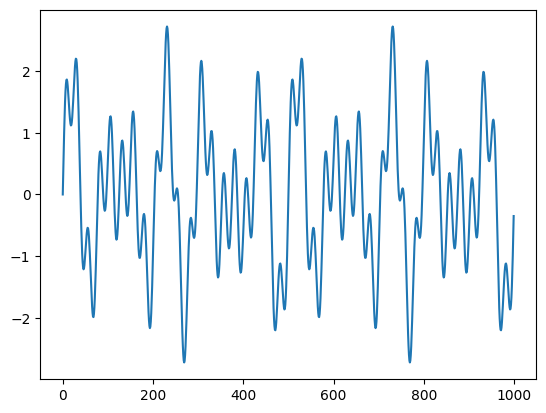

In [24]:
plt.plot(x)

In [25]:
import anywidget
import traitlets
import numpy as np


class SignalDraw(anywidget.AnyWidget):

    _esm = r"""

export function render({ model, el }) {

    // =====================================================
    // CONFIG
    // =====================================================

    const COLORS = [
        "#0066ff",
        "#ff0000",
        "#00aa00",
        "#ff9900",
        "#9900ff"
    ];

    // =====================================================
    // ROOT
    // =====================================================

    const root = document.createElement("div");

    root.style.width = "100%";

    root.style.maxWidth = "1500px";

    root.style.background = "#efefef";

    root.style.padding = "8px";

    root.style.fontFamily = "Arial";

    root.style.boxSizing = "border-box";

    el.appendChild(root);

    // =====================================================
    // TOPBAR
    // =====================================================

    const topbar = document.createElement("div");

    topbar.style.display = "flex";

    topbar.style.alignItems = "center";

    topbar.style.gap = "12px";

    topbar.style.background = "white";

    topbar.style.padding = "8px";

    topbar.style.borderRadius = "6px";

    topbar.style.marginBottom = "8px";

    root.appendChild(topbar);

    // TITLE

    const title = document.createElement("h2");

    title.innerText = "SignalDraw";

    title.style.margin = "0";

    title.style.color = "#0066ff";

    title.style.marginRight = "auto";

    topbar.appendChild(title);

    // SIGNAL COUNT

    const label =
        document.createElement("label");

    label.innerText = "#Signals";

    label.style.fontSize = "14px";

    topbar.appendChild(label);

    const select =
        document.createElement("select");

    select.style.padding = "4px";

    for(let i=1;i<=5;i++) {

        const op =
            document.createElement("option");

        op.value = i;

        op.text = i;

        if(i===3) op.selected = true;

        select.appendChild(op);
    }

    topbar.appendChild(select);

    // NOISE

    const noiseCheck =
        document.createElement("input");

    noiseCheck.type = "checkbox";

    const noiseLabel =
        document.createElement("label");

    noiseLabel.innerText = "Noise";

    noiseLabel.style.fontSize = "14px";

    topbar.appendChild(noiseCheck);

    topbar.appendChild(noiseLabel);

    // BUTTON

    const btn =
        document.createElement("button");

    btn.innerText = "GENERATE";

    btn.style.padding = "6px 12px";

    btn.style.background = "#0066ff";

    btn.style.color = "white";

    btn.style.border = "none";

    btn.style.borderRadius = "5px";

    btn.style.cursor = "pointer";

    topbar.appendChild(btn);

    // =====================================================
    // MAIN
    // =====================================================

    const main = document.createElement("div");

    main.style.display = "flex";

    main.style.gap = "8px";

    root.appendChild(main);

    // =====================================================
    // LEFT
    // =====================================================

    const left =
        document.createElement("div");

    left.style.width = "26%";

    left.style.display = "flex";

    left.style.flexDirection = "column";

    left.style.gap = "8px";

    left.style.maxHeight = "760px";

    left.style.overflowY = "auto";

    main.appendChild(left);

    // =====================================================
    // CENTER
    // =====================================================

    const center =
        document.createElement("div");

    center.style.width = "37%";

    center.style.display = "flex";

    center.style.flexDirection = "column";

    center.style.gap = "8px";

    main.appendChild(center);

    // =====================================================
    // RIGHT
    // =====================================================

    const right =
        document.createElement("div");

    right.style.width = "37%";

    right.style.display = "flex";

    right.style.flexDirection = "column";

    right.style.gap = "8px";

    main.appendChild(right);

    // =====================================================
    // SUM
    // =====================================================

    const sumCard =
        document.createElement("div");

    sumCard.style.background = "white";

    sumCard.style.borderRadius = "6px";

    sumCard.style.padding = "6px";

    right.appendChild(sumCard);

    const sumTitle =
        document.createElement("div");

    sumTitle.innerText = "Summed Signal";

    sumTitle.style.fontWeight = "bold";

    sumTitle.style.marginBottom = "4px";

    sumCard.appendChild(sumTitle);

    const sumSVG =
        document.createElementNS(
            "http://www.w3.org/2000/svg",
            "svg"
        );

    sumSVG.setAttribute("width","500");

    sumSVG.setAttribute("height","250");

    sumSVG.style.background = "white";

    sumSVG.style.border =
        "1px solid #dddddd";

    sumCard.appendChild(sumSVG);

    // =====================================================
    // FFT
    // =====================================================

    const fftCard =
        document.createElement("div");

    fftCard.style.background = "white";

    fftCard.style.borderRadius = "6px";

    fftCard.style.padding = "6px";

    right.appendChild(fftCard);

    const fftTitle =
        document.createElement("div");

    fftTitle.innerText = "FFT";

    fftTitle.style.fontWeight = "bold";

    fftTitle.style.marginBottom = "4px";

    fftCard.appendChild(fftTitle);

    const fftSVG =
        document.createElementNS(
            "http://www.w3.org/2000/svg",
            "svg"
        );

    fftSVG.setAttribute("width","500");

    fftSVG.setAttribute("height","250");

    fftSVG.style.background = "white";

    fftSVG.style.border =
        "1px solid #dddddd";

    fftCard.appendChild(fftSVG);

    // =====================================================
    // INPUT HELPER
    // =====================================================

    function createInput(label,value) {

        const c =
            document.createElement("div");

        c.style.display = "flex";

        c.style.flexDirection = "column";

        c.style.marginBottom = "6px";

        const l =
            document.createElement("label");

        l.innerText = label;

        l.style.fontSize = "12px";

        l.style.marginBottom = "2px";

        const i =
            document.createElement("input");

        i.type = "number";

        i.value = value;

        i.style.padding = "4px";

        i.style.fontSize = "12px";

        c.appendChild(l);

        c.appendChild(i);

        return {
            container:c,
            input:i
        };
    }

    // =====================================================
    // SLIDER WITH VALUE
    // =====================================================

    function createSlider(label,value) {

        const c =
            document.createElement("div");

        c.style.display = "flex";

        c.style.flexDirection = "column";

        c.style.marginBottom = "6px";

        // ROW

        const row =
            document.createElement("div");

        row.style.display = "flex";

        row.style.justifyContent =
            "space-between";

        row.style.alignItems = "center";

        // LABEL

        const l =
            document.createElement("label");

        l.innerText = label;

        l.style.fontSize = "12px";

        // VALUE

        const valueText =
            document.createElement("span");

        valueText.innerText =
            parseFloat(value).toFixed(1);

        valueText.style.fontSize = "12px";

        valueText.style.fontWeight = "bold";

        valueText.style.color = "#0066ff";

        row.appendChild(l);

        row.appendChild(valueText);

        // SLIDER

        const s =
            document.createElement("input");

        s.type = "range";

        s.min = 0;

        s.max = 5;

        s.step = 0.1;

        s.value = value;

        s.addEventListener("input",()=>{

            valueText.innerText =
                parseFloat(s.value).toFixed(1);
        });

        c.appendChild(row);

        c.appendChild(s);

        return {
            container:c,
            slider:s,
            valueText:valueText
        };
    }

    // =====================================================
    // GRID + AXES
    // =====================================================

    function drawGrid(svg,w,h) {

        svg.innerHTML = "";

        // GRID

        for(let x=40;x<w;x+=40) {

            const line =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "line"
                );

            line.setAttribute("x1",x);

            line.setAttribute("y1",0);

            line.setAttribute("x2",x);

            line.setAttribute("y2",h-30);

            line.setAttribute(
                "stroke",
                "#eeeeee"
            );

            svg.appendChild(line);
        }

        for(let y=20;y<h-30;y+=40) {

            const line =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "line"
                );

            line.setAttribute("x1",40);

            line.setAttribute("y1",y);

            line.setAttribute("x2",w);

            line.setAttribute("y2",y);

            line.setAttribute(
                "stroke",
                "#eeeeee"
            );

            svg.appendChild(line);
        }

        // X AXIS

        const xAxis =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "line"
            );

        xAxis.setAttribute("x1",40);

        xAxis.setAttribute("y1",h/2);

        xAxis.setAttribute("x2",w);

        xAxis.setAttribute("y2",h/2);

        xAxis.setAttribute("stroke","#666");

        xAxis.setAttribute("stroke-width","1.5");

        svg.appendChild(xAxis);

        // Y AXIS

        const yAxis =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "line"
            );

        yAxis.setAttribute("x1",40);

        yAxis.setAttribute("y1",10);

        yAxis.setAttribute("x2",40);

        yAxis.setAttribute("y2",h-30);

        yAxis.setAttribute("stroke","#666");

        yAxis.setAttribute("stroke-width","1.5");

        svg.appendChild(yAxis);

        // X TICKS

        for(let i=0;i<=10;i++) {

            const x =
                40 + i*((w-50)/10);

            const tick =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "line"
                );

            tick.setAttribute("x1",x);

            tick.setAttribute("y1",h/2-4);

            tick.setAttribute("x2",x);

            tick.setAttribute("y2",h/2+4);

            tick.setAttribute("stroke","#444");

            svg.appendChild(tick);

            const text =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "text"
                );

            text.setAttribute("x",x-8);

            text.setAttribute("y",h-8);

            text.setAttribute("font-size","10");

            text.setAttribute("fill","#333");

            text.textContent =
                (i*0.2).toFixed(1);

            svg.appendChild(text);
        }

        // Y TICKS

        for(let i=-2;i<=2;i++) {

            const y =
                h/2 - i*45;

            const tick =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "line"
                );

            tick.setAttribute("x1",35);

            tick.setAttribute("y1",y);

            tick.setAttribute("x2",45);

            tick.setAttribute("y2",y);

            tick.setAttribute("stroke","#444");

            svg.appendChild(tick);

            const text =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "text"
                );

            text.setAttribute("x","8");

            text.setAttribute("y",y+4);

            text.setAttribute("font-size","10");

            text.setAttribute("fill","#333");

            text.textContent = i;

            svg.appendChild(text);
        }

        // X LABEL

        const xlabel =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "text"
            );

        xlabel.setAttribute("x",w/2);

        xlabel.setAttribute("y",h-2);

        xlabel.setAttribute("font-size","11");

        xlabel.setAttribute("fill","#333");

        xlabel.textContent = "Time (s)";

        svg.appendChild(xlabel);

        // Y LABEL

        const ylabel =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "text"
            );

        ylabel.setAttribute(
            "transform",
            "rotate(-90)"
        );

        ylabel.setAttribute(
            "x",
            -h/2
        );

        ylabel.setAttribute(
            "y",
            "14"
        );

        ylabel.setAttribute(
            "font-size",
            "11"
        );

        ylabel.setAttribute(
            "fill",
            "#333"
        );

        ylabel.textContent =
            "Amplitude";

        svg.appendChild(ylabel);
    }

    // =====================================================
    // DRAW SIGNAL
    // =====================================================

    function drawSignal(svg,signal,color) {

        const w =
            parseInt(
                svg.getAttribute("width")
            );

        const h =
            parseInt(
                svg.getAttribute("height")
            );

        drawGrid(svg,w,h);

        let path = "";

        for(let i=0;i<signal.length;i++) {

            const x =
                40 +
                i*((w-50)/signal.length);

            const y =
                h/2 -
                signal[i]*45;

            if(i===0) {

                path += `M ${x} ${y}`;

            } else {

                path += ` L ${x} ${y}`;
            }
        }

        const curve =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "path"
            );

        curve.setAttribute("d",path);

        curve.setAttribute("stroke",color);

        curve.setAttribute("stroke-width","2");

        curve.setAttribute("fill","none");

        svg.appendChild(curve);
    }

    // =====================================================
    // FFT
    // =====================================================

    function computeFFT(signal) {

        const N = signal.length;

        let mags = [];

        for(let k=0;k<80;k++) {

            let re = 0;

            let im = 0;

            for(let n=0;n<N;n++) {

                const angle =
                    2*Math.PI*k*n/N;

                re +=
                    signal[n] *
                    Math.cos(angle);

                im -=
                    signal[n] *
                    Math.sin(angle);
            }

            mags.push(
                Math.sqrt(re*re+im*im)/N
            );
        }

        return mags;
    }

    // =====================================================
    // DRAW FFT
    // =====================================================

    function drawFFT(svg,mags) {

        const w =
            parseInt(
                svg.getAttribute("width")
            );

        const h =
            parseInt(
                svg.getAttribute("height")
            );

        drawGrid(svg,w,h);

        const maxVal =
            Math.max(...mags);

        for(let i=0;i<mags.length;i++) {

            const x =
                40 +
                i*((w-50)/mags.length);

            const bh =
                (mags[i]/maxVal) *
                (h-50);

            const rect =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "rect"
                );

            rect.setAttribute("x",x);

            rect.setAttribute("y",h-bh-30);

            rect.setAttribute(
                "width",
                (w/mags.length)-2
            );

            rect.setAttribute(
                "height",
                bh
            );

            rect.setAttribute(
                "fill",
                "#00aa00"
            );

            svg.appendChild(rect);
        }
    }

    // =====================================================
    // STATE
    // =====================================================

    let configs = [];

    // =====================================================
    // BUILD UI
    // =====================================================

    function buildUI() {

        left.innerHTML = "";

        center.innerHTML = "";

        configs = [];

        const n =
            parseInt(select.value);

        for(let i=0;i<n;i++) {

            // CARD

            const card =
                document.createElement("div");

            card.style.background = "white";

            card.style.padding = "8px";

            card.style.borderRadius = "6px";

            card.style.borderLeft =
                "4px solid " + COLORS[i];

            // TITLE

            const title =
                document.createElement("div");

            title.innerText =
                "Signal " + (i+1);

            title.style.fontWeight = "bold";

            title.style.fontSize = "14px";

            title.style.color = COLORS[i];

            title.style.marginBottom = "6px";

            card.appendChild(title);

            // INPUTS

            const fs =
                createInput("Fs",500);

            const amp =
                createSlider("Amplitude",1);

            const freq =
                createInput(
                    "Frequency",
                    5+i
                );

            const phase =
                createInput("Phase",0);

            card.appendChild(fs.container);

            card.appendChild(freq.container);

            card.appendChild(amp.container);

            card.appendChild(phase.container);

            left.appendChild(card);

            // SIGNAL CARD

            const signalCard =
                document.createElement("div");

            signalCard.style.background =
                "white";

            signalCard.style.padding =
                "6px";

            signalCard.style.borderRadius =
                "6px";

            const signalTitle =
                document.createElement("div");

            signalTitle.innerText =
                "Signal " + (i+1);

            signalTitle.style.fontSize =
                "13px";

            signalTitle.style.fontWeight =
                "bold";

            signalTitle.style.marginBottom =
                "4px";

            signalCard.appendChild(
                signalTitle
            );

            const svg =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "svg"
                );

            svg.setAttribute("width","500");

            svg.setAttribute("height","160");

            svg.style.border =
                "1px solid #dddddd";

            signalCard.appendChild(svg);

            center.appendChild(signalCard);

            configs.push({
                fs,
                amp,
                freq,
                phase,
                svg,
                color:COLORS[i]
            });
        }
    }

    // =====================================================
    // GENERATE
    // =====================================================

    function generate() {

        let total = [];

        let time = [];

        configs.forEach(cfg => {

            const fs =
                parseFloat(
                    cfg.fs.input.value
                );

            const amp =
                parseFloat(
                    cfg.amp.slider.value
                );

            const freq =
                parseFloat(
                    cfg.freq.input.value
                );

            const phase =
                parseFloat(
                    cfg.phase.input.value
                );

            const duration = 2;

            const N = fs * duration;

            let signal = [];

            let t = [];

            for(let i=0;i<N;i++) {

                const tt = i/fs;

                const y =
                    amp *
                    Math.sin(
                        2*Math.PI*
                        freq*
                        tt+
                        phase
                    );

                signal.push(y);

                t.push(tt);
            }

            time = t;

            if(total.length===0) {

                total = [...signal];

            } else {

                total =
                    total.map(
                        (v,i)=>v+signal[i]
                    );
            }

            drawSignal(
                cfg.svg,
                signal,
                cfg.color
            );
        });

        drawSignal(
            sumSVG,
            total,
            "#0066ff"
        );

        const mags =
            computeFFT(total);

        drawFFT(
            fftSVG,
            mags
        );

        model.set("signal",total);

        model.set("time",time);

        model.save_changes();
    }

    // =====================================================
    // EVENTS
    // =====================================================

    select.addEventListener(
        "change",
        ()=>{
            buildUI();
            generate();
        }
    );

    btn.addEventListener(
        "click",
        generate
    );

    // =====================================================
    // INIT
    // =====================================================

    buildUI();

    generate();
}
"""

    signal = traitlets.List([]).tag(sync=True)

    time = traitlets.List([]).tag(sync=True)

    @property
    def signal_numpy(self):
        return np.array(self.signal)

    @property
    def time_numpy(self):
        return np.array(self.time)


ui = SignalDraw()

ui

In [26]:
import anywidget
import traitlets
import numpy as np


class SignalDraw(anywidget.AnyWidget):

    _esm = r"""

export function render({ model, el }) {

    // =====================================================
    // CONFIG
    // =====================================================

    const COLORS = [
        "#0066ff",
        "#ff0000",
        "#00aa00",
        "#ff9900",
        "#9900ff"
    ];

    // =====================================================
    // ROOT
    // =====================================================

    const root = document.createElement("div");

    root.style.width = "100%";

    root.style.maxWidth = "1500px";

    root.style.background = "#efefef";

    root.style.padding = "8px";

    root.style.fontFamily = "Arial";

    root.style.boxSizing = "border-box";

    el.appendChild(root);

    // =====================================================
    // TOPBAR
    // =====================================================

    const topbar = document.createElement("div");

    topbar.style.display = "flex";

    topbar.style.alignItems = "center";

    topbar.style.gap = "12px";

    topbar.style.background = "white";

    topbar.style.padding = "8px";

    topbar.style.borderRadius = "6px";

    topbar.style.marginBottom = "8px";

    root.appendChild(topbar);

    // TITLE

    const title = document.createElement("h2");

    title.innerText = "SignalDraw";

    title.style.margin = "0";

    title.style.color = "#0066ff";

    title.style.marginRight = "auto";

    topbar.appendChild(title);

    // SIGNAL COUNT

    const label =
        document.createElement("label");

    label.innerText = "#Signals";

    label.style.fontSize = "14px";

    topbar.appendChild(label);

    const select =
        document.createElement("select");

    select.style.padding = "4px";

    for(let i=1;i<=5;i++) {

        const op =
            document.createElement("option");

        op.value = i;

        op.text = i;

        if(i===3) op.selected = true;

        select.appendChild(op);
    }

    topbar.appendChild(select);

    // NOISE

    const noiseCheck =
        document.createElement("input");

    noiseCheck.type = "checkbox";

    const noiseLabel =
        document.createElement("label");

    noiseLabel.innerText = "Noise";

    noiseLabel.style.fontSize = "14px";

    topbar.appendChild(noiseCheck);

    topbar.appendChild(noiseLabel);

    // BUTTON

    const btn =
        document.createElement("button");

    btn.innerText = "GENERATE";

    btn.style.padding = "6px 12px";

    btn.style.background = "#0066ff";

    btn.style.color = "white";

    btn.style.border = "none";

    btn.style.borderRadius = "5px";

    btn.style.cursor = "pointer";

    topbar.appendChild(btn);

    // =====================================================
    // MAIN
    // =====================================================

    const main = document.createElement("div");

    main.style.display = "flex";

    main.style.gap = "8px";

    root.appendChild(main);

    // =====================================================
    // LEFT
    // =====================================================

    const left =
        document.createElement("div");

    left.style.width = "26%";

    left.style.display = "flex";

    left.style.flexDirection = "column";

    left.style.gap = "8px";

    left.style.maxHeight = "760px";

    left.style.overflowY = "auto";

    main.appendChild(left);

    // =====================================================
    // CENTER
    // =====================================================

    const center =
        document.createElement("div");

    center.style.width = "37%";

    center.style.display = "flex";

    center.style.flexDirection = "column";

    center.style.gap = "8px";

    main.appendChild(center);

    // =====================================================
    // RIGHT
    // =====================================================

    const right =
        document.createElement("div");

    right.style.width = "37%";

    right.style.display = "flex";

    right.style.flexDirection = "column";

    right.style.gap = "8px";

    main.appendChild(right);

    // =====================================================
    // RESULT SIGNAL
    // =====================================================

    const sumCard =
        document.createElement("div");

    sumCard.style.background = "white";

    sumCard.style.borderRadius = "6px";

    sumCard.style.padding = "6px";

    right.appendChild(sumCard);

    const sumTitle =
        document.createElement("div");

    sumTitle.innerText = "Señal resultante";

    sumTitle.style.fontWeight = "bold";

    sumTitle.style.marginBottom = "4px";

    sumCard.appendChild(sumTitle);

    const sumSVG =
        document.createElementNS(
            "http://www.w3.org/2000/svg",
            "svg"
        );

    sumSVG.setAttribute("width","500");

    sumSVG.setAttribute("height","250");

    sumSVG.style.background = "white";

    sumSVG.style.border =
        "1px solid #dddddd";

    sumCard.appendChild(sumSVG);

    // =====================================================
    // FFT
    // =====================================================

    const fftCard =
        document.createElement("div");

    fftCard.style.background = "white";

    fftCard.style.borderRadius = "6px";

    fftCard.style.padding = "6px";

    right.appendChild(fftCard);

    const fftTitle =
        document.createElement("div");

    fftTitle.innerText = "FFT";

    fftTitle.style.fontWeight = "bold";

    fftTitle.style.marginBottom = "4px";

    fftCard.appendChild(fftTitle);

    const fftSVG =
        document.createElementNS(
            "http://www.w3.org/2000/svg",
            "svg"
        );

    fftSVG.setAttribute("width","500");

    fftSVG.setAttribute("height","250");

    fftSVG.style.background = "white";

    fftSVG.style.border =
        "1px solid #dddddd";

    fftCard.appendChild(fftSVG);

    // =====================================================
    // INPUT HELPER
    // =====================================================

    function createInput(label,value) {

        const c =
            document.createElement("div");

        c.style.display = "flex";

        c.style.flexDirection = "column";

        c.style.marginBottom = "6px";

        const l =
            document.createElement("label");

        l.innerText = label;

        l.style.fontSize = "12px";

        l.style.marginBottom = "2px";

        const i =
            document.createElement("input");

        i.type = "number";

        i.value = value;

        i.style.padding = "4px";

        i.style.fontSize = "12px";

        c.appendChild(l);

        c.appendChild(i);

        return {
            container:c,
            input:i
        };
    }

    // =====================================================
    // SLIDER WITH VALUE
    // =====================================================

    function createSlider(label,value) {

        const c =
            document.createElement("div");

        c.style.display = "flex";

        c.style.flexDirection = "column";

        c.style.marginBottom = "6px";

        // ROW

        const row =
            document.createElement("div");

        row.style.display = "flex";

        row.style.justifyContent =
            "space-between";

        row.style.alignItems = "center";

        // LABEL

        const l =
            document.createElement("label");

        l.innerText = label;

        l.style.fontSize = "12px";

        // VALUE

        const valueText =
            document.createElement("span");

        valueText.innerText =
            parseFloat(value).toFixed(1);

        valueText.style.fontSize = "12px";

        valueText.style.fontWeight = "bold";

        valueText.style.color = "#0066ff";

        row.appendChild(l);

        row.appendChild(valueText);

        // SLIDER

        const s =
            document.createElement("input");

        s.type = "range";

        s.min = 0;

        s.max = 5;

        s.step = 0.1;

        s.value = value;

        s.addEventListener("input",()=>{

            valueText.innerText =
                parseFloat(s.value).toFixed(1);
        });

        c.appendChild(row);

        c.appendChild(s);

        return {
            container:c,
            slider:s,
            valueText:valueText
        };
    }

    // =====================================================
    // GRID + AXES
    // =====================================================

    function drawGrid(
        svg,
        w,
        h,
        xlabel="Time (s)",
        ylabel="Amplitude"
    ) {

        svg.innerHTML = "";

        // GRID

        for(let x=40;x<w;x+=40) {

            const line =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "line"
                );

            line.setAttribute("x1",x);

            line.setAttribute("y1",10);

            line.setAttribute("x2",x);

            line.setAttribute("y2",h-30);

            line.setAttribute(
                "stroke",
                "#ededed"
            );

            svg.appendChild(line);
        }

        for(let y=20;y<h-30;y+=40) {

            const line =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "line"
                );

            line.setAttribute("x1",40);

            line.setAttribute("y1",y);

            line.setAttribute("x2",w);

            line.setAttribute("y2",y);

            line.setAttribute(
                "stroke",
                "#ededed"
            );

            svg.appendChild(line);
        }

        // X AXIS

        const xAxis =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "line"
            );

        xAxis.setAttribute("x1",40);

        xAxis.setAttribute("y1",h/2);

        xAxis.setAttribute("x2",w);

        xAxis.setAttribute("y2",h/2);

        xAxis.setAttribute("stroke","#666");

        xAxis.setAttribute("stroke-width","1.5");

        svg.appendChild(xAxis);

        // Y AXIS

        const yAxis =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "line"
            );

        yAxis.setAttribute("x1",40);

        yAxis.setAttribute("y1",10);

        yAxis.setAttribute("x2",40);

        yAxis.setAttribute("y2",h-30);

        yAxis.setAttribute("stroke","#666");

        yAxis.setAttribute("stroke-width","1.5");

        svg.appendChild(yAxis);

        // X LABEL

        const xlabelText =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "text"
            );

        xlabelText.setAttribute("x",w/2);

        xlabelText.setAttribute("y",h-5);

        xlabelText.setAttribute(
            "font-size",
            "11"
        );

        xlabelText.setAttribute(
            "fill",
            "#333"
        );

        xlabelText.textContent =
            xlabel;

        svg.appendChild(xlabelText);

        // Y LABEL

        const ylabelText =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "text"
            );

        ylabelText.setAttribute(
            "transform",
            "rotate(-90)"
        );

        ylabelText.setAttribute(
            "x",
            -h/2
        );

        ylabelText.setAttribute(
            "y",
            "14"
        );

        ylabelText.setAttribute(
            "font-size",
            "11"
        );

        ylabelText.setAttribute(
            "fill",
            "#333"
        );

        ylabelText.textContent =
            ylabel;

        svg.appendChild(ylabelText);
    }

    // =====================================================
    // DRAW SIGNAL
    // =====================================================

    function drawSignal(
        svg,
        signal,
        color,
        autoscale=false
    ) {

        const w =
            parseInt(
                svg.getAttribute("width")
            );

        const h =
            parseInt(
                svg.getAttribute("height")
            );

        drawGrid(
            svg,
            w,
            h,
            "Time (s)",
            "Amplitude"
        );

        // AUTOSCALE

        let scale = 45;

        let maxVal = 2;

        if(autoscale) {

            maxVal =
                Math.max(
                    ...signal.map(
                        v => Math.abs(v)
                    )
                );

            if(maxVal > 0.01) {

                scale =
                    (h*0.35)/maxVal;
            }
        }

        // PATH

        let path = "";

        for(let i=0;i<signal.length;i++) {

            const x =
                40 +
                i*((w-50)/signal.length);

            const y =
                h/2 -
                signal[i]*scale;

            if(i===0) {

                path += `M ${x} ${y}`;

            } else {

                path += ` L ${x} ${y}`;
            }
        }

        const curve =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "path"
            );

        curve.setAttribute("d",path);

        curve.setAttribute("stroke",color);

        curve.setAttribute("stroke-width","2");

        curve.setAttribute("fill","none");

        svg.appendChild(curve);

        // SCALE INFO

        const txt =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "text"
            );

        txt.setAttribute("x",w-130);

        txt.setAttribute("y","18");

        txt.setAttribute(
            "font-size",
            "11"
        );

        txt.setAttribute(
            "fill",
            "#444"
        );

        txt.textContent =
            "Peak: ±" +
            maxVal.toFixed(2);

        svg.appendChild(txt);
    }

    // =====================================================
    // FFT
    // =====================================================

    function computeFFT(signal) {

        const N = signal.length;

        let mags = [];

        for(let k=0;k<120;k++) {

            let re = 0;

            let im = 0;

            for(let n=0;n<N;n++) {

                const angle =
                    2*Math.PI*k*n/N;

                re +=
                    signal[n] *
                    Math.cos(angle);

                im -=
                    signal[n] *
                    Math.sin(angle);
            }

            mags.push(
                Math.sqrt(re*re+im*im)/N
            );
        }

        return mags;
    }

    // =====================================================
    // DRAW FFT
    // =====================================================

    function drawFFT(svg,mags) {

        const w =
            parseInt(
                svg.getAttribute("width")
            );

        const h =
            parseInt(
                svg.getAttribute("height")
            );

        drawGrid(
            svg,
            w,
            h,
            "Frequency Bin",
            "Normalized Magnitude"
        );

        // NORMALIZATION

        const maxVal =
            Math.max(...mags);

        const norm =
            mags.map(v => v/maxVal);

        // PATH

        let path = "";

        for(let i=0;i<norm.length;i++) {

            const x =
                40 +
                i*((w-50)/norm.length);

            const y =
                h-30 -
                norm[i]*(h*0.7);

            if(i===0) {

                path += `M ${x} ${y}`;

            } else {

                path += ` L ${x} ${y}`;
            }
        }

        // AREA

        const areaPath =
            path +
            ` L ${w-10} ${h-30}` +
            ` L 40 ${h-30} Z`;

        const area =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "path"
            );

        area.setAttribute("d",areaPath);

        area.setAttribute(
            "fill",
            "rgba(0,170,0,0.15)"
        );

        svg.appendChild(area);

        // CURVE

        const curve =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "path"
            );

        curve.setAttribute("d",path);

        curve.setAttribute(
            "stroke",
            "#00aa00"
        );

        curve.setAttribute(
            "stroke-width",
            "2.5"
        );

        curve.setAttribute(
            "fill",
            "none"
        );

        svg.appendChild(curve);

        // PEAKS

        for(let i=0;i<norm.length;i++) {

            if(norm[i] > 0.2) {

                const x =
                    40 +
                    i*((w-50)/norm.length);

                const y =
                    h-30 -
                    norm[i]*(h*0.7);

                const circle =
                    document.createElementNS(
                        "http://www.w3.org/2000/svg",
                        "circle"
                    );

                circle.setAttribute("cx",x);

                circle.setAttribute("cy",y);

                circle.setAttribute("r","3");

                circle.setAttribute(
                    "fill",
                    "#00aa00"
                );

                svg.appendChild(circle);
            }
        }

        // INFO

        const txt =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "text"
            );

        txt.setAttribute("x",w-140);

        txt.setAttribute("y","18");

        txt.setAttribute(
            "font-size",
            "11"
        );

        txt.setAttribute(
            "fill",
            "#444"
        );

        txt.textContent =
            "Auto FFT Scale";

        svg.appendChild(txt);
    }

    // =====================================================
    // STATE
    // =====================================================

    let configs = [];

    // =====================================================
    // BUILD UI
    // =====================================================

    function buildUI() {

        left.innerHTML = "";

        center.innerHTML = "";

        configs = [];

        const n =
            parseInt(select.value);

        for(let i=0;i<n;i++) {

            // CONTROL CARD

            const card =
                document.createElement("div");

            card.style.background = "white";

            card.style.padding = "8px";

            card.style.borderRadius = "6px";

            card.style.borderLeft =
                "4px solid " + COLORS[i];

            // TITLE

            const title =
                document.createElement("div");

            title.innerText =
                "Signal " + (i+1);

            title.style.fontWeight = "bold";

            title.style.fontSize = "14px";

            title.style.color = COLORS[i];

            title.style.marginBottom = "6px";

            card.appendChild(title);

            // INPUTS

            const fs =
                createInput("Fs",1000);

            const amp =
                createSlider("Amplitude",1);

            const freq =
                createInput(
                    "Frequency",
                    5+i
                );

            const phase =
                createInput("Phase",0);

            card.appendChild(fs.container);

            card.appendChild(freq.container);

            card.appendChild(amp.container);

            card.appendChild(phase.container);

            left.appendChild(card);

            // SIGNAL CARD

            const signalCard =
                document.createElement("div");

            signalCard.style.background =
                "white";

            signalCard.style.padding =
                "6px";

            signalCard.style.borderRadius =
                "6px";

            const signalTitle =
                document.createElement("div");

            signalTitle.innerText =
                "Signal " + (i+1);

            signalTitle.style.fontSize =
                "13px";

            signalTitle.style.fontWeight =
                "bold";

            signalTitle.style.marginBottom =
                "4px";

            signalCard.appendChild(
                signalTitle
            );

            const svg =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "svg"
                );

            svg.setAttribute("width","500");

            svg.setAttribute("height","160");

            svg.style.border =
                "1px solid #dddddd";

            signalCard.appendChild(svg);

            center.appendChild(signalCard);

            configs.push({
                fs,
                amp,
                freq,
                phase,
                svg,
                color:COLORS[i]
            });
        }
    }

    // =====================================================
    // GENERATE
    // =====================================================

    function generate() {

        let total = [];

        let time = [];

        configs.forEach(cfg => {

            const fs =
                parseFloat(
                    cfg.fs.input.value
                );

            const amp =
                parseFloat(
                    cfg.amp.slider.value
                );

            const freq =
                parseFloat(
                    cfg.freq.input.value
                );

            const phase =
                parseFloat(
                    cfg.phase.input.value
                );

            const duration = 2;

            const N = fs * duration;

            let signal = [];

            let t = [];

            for(let i=0;i<N;i++) {

                const tt = i/fs;

                const y =
                    amp *
                    Math.sin(
                        2*Math.PI*
                        freq*
                        tt+
                        phase
                    );

                signal.push(y);

                t.push(tt);
            }

            time = t;

            if(total.length===0) {

                total = [...signal];

            } else {

                total =
                    total.map(
                        (v,i)=>v+signal[i]
                    );
            }

            drawSignal(
                cfg.svg,
                signal,
                cfg.color
            );
        });

        // RESULT SIGNAL

        drawSignal(
            sumSVG,
            total,
            "#0066ff",
            true
        );

        // FFT

        const mags =
            computeFFT(total);

        drawFFT(
            fftSVG,
            mags
        );

        // SEND TO PYTHON

        model.set("signal",total);

        model.set("time",time);

        model.save_changes();
    }

    // =====================================================
    // EVENTS
    // =====================================================

    select.addEventListener(
        "change",
        ()=>{
            buildUI();
            generate();
        }
    );

    btn.addEventListener(
        "click",
        generate
    );

    // =====================================================
    // INIT
    // =====================================================

    buildUI();

    generate();
}
"""

    signal = traitlets.List([]).tag(sync=True)

    time = traitlets.List([]).tag(sync=True)

    @property
    def signal_numpy(self):
        return np.array(self.signal)

    @property
    def time_numpy(self):
        return np.array(self.time)


ui = SignalDraw()

ui

In [27]:
import anywidget
import traitlets
import numpy as np


class SignalDraw(anywidget.AnyWidget):

    _esm = r"""

export function render({ model, el }) {

    // =====================================================
    // COLORS
    // =====================================================

    const COLORS = [
        "#0066ff",
        "#ff0000",
        "#00aa00",
        "#ff9900",
        "#9900ff"
    ];

    // =====================================================
    // ROOT
    // =====================================================

    const root = document.createElement("div");

    root.style.width = "100%";

    root.style.maxWidth = "1500px";

    root.style.background = "#efefef";

    root.style.padding = "8px";

    root.style.fontFamily = "Arial";

    root.style.boxSizing = "border-box";

    el.appendChild(root);

    // =====================================================
    // TOPBAR
    // =====================================================

    const topbar = document.createElement("div");

    topbar.style.display = "flex";

    topbar.style.alignItems = "center";

    topbar.style.gap = "12px";

    topbar.style.background = "white";

    topbar.style.padding = "8px";

    topbar.style.borderRadius = "6px";

    topbar.style.marginBottom = "8px";

    root.appendChild(topbar);

    // TITLE

    const title = document.createElement("h2");

    title.innerText = "SignalDraw";

    title.style.margin = "0";

    title.style.color = "#0066ff";

    title.style.marginRight = "auto";

    topbar.appendChild(title);

    // NUMBER OF SIGNALS

    const label =
        document.createElement("label");

    label.innerText = "#Signals";

    topbar.appendChild(label);

    const select =
        document.createElement("select");

    for(let i=1;i<=5;i++) {

        const op =
            document.createElement("option");

        op.value = i;

        op.text = i;

        if(i===3) op.selected = true;

        select.appendChild(op);
    }

    topbar.appendChild(select);

    // BUTTON

    const btn =
        document.createElement("button");

    btn.innerText = "GENERATE";

    btn.style.padding = "6px 12px";

    btn.style.background = "#0066ff";

    btn.style.color = "white";

    btn.style.border = "none";

    btn.style.borderRadius = "5px";

    btn.style.cursor = "pointer";

    topbar.appendChild(btn);

    // =====================================================
    // MAIN LAYOUT
    // =====================================================

    const main = document.createElement("div");

    main.style.display = "flex";

    main.style.gap = "8px";

    root.appendChild(main);

    // =====================================================
    // LEFT PANEL
    // =====================================================

    const left =
        document.createElement("div");

    left.style.width = "26%";

    left.style.display = "flex";

    left.style.flexDirection = "column";

    left.style.gap = "8px";

    left.style.maxHeight = "760px";

    left.style.overflowY = "auto";

    main.appendChild(left);

    // =====================================================
    // CENTER PANEL
    // =====================================================

    const center =
        document.createElement("div");

    center.style.width = "37%";

    center.style.display = "flex";

    center.style.flexDirection = "column";

    center.style.gap = "8px";

    main.appendChild(center);

    // =====================================================
    // RIGHT PANEL
    // =====================================================

    const right =
        document.createElement("div");

    right.style.width = "37%";

    right.style.display = "flex";

    right.style.flexDirection = "column";

    right.style.gap = "8px";

    main.appendChild(right);

    // =====================================================
    // RESULT SIGNAL CARD
    // =====================================================

    const sumCard =
        document.createElement("div");

    sumCard.style.background = "white";

    sumCard.style.padding = "6px";

    sumCard.style.borderRadius = "6px";

    right.appendChild(sumCard);

    const sumTitle =
        document.createElement("div");

    sumTitle.innerText = "Señal resultante";

    sumTitle.style.fontWeight = "bold";

    sumTitle.style.marginBottom = "4px";

    sumCard.appendChild(sumTitle);

    const sumSVG =
        document.createElementNS(
            "http://www.w3.org/2000/svg",
            "svg"
        );

    sumSVG.setAttribute("width","500");

    sumSVG.setAttribute("height","250");

    sumSVG.style.border =
        "1px solid #dddddd";

    sumCard.appendChild(sumSVG);

    // =====================================================
    // FFT CARD
    // =====================================================

    const fftCard =
        document.createElement("div");

    fftCard.style.background = "white";

    fftCard.style.padding = "6px";

    fftCard.style.borderRadius = "6px";

    right.appendChild(fftCard);

    const fftTitle =
        document.createElement("div");

    fftTitle.innerText = "FFT";

    fftTitle.style.fontWeight = "bold";

    fftTitle.style.marginBottom = "4px";

    fftCard.appendChild(fftTitle);

    const fftSVG =
        document.createElementNS(
            "http://www.w3.org/2000/svg",
            "svg"
        );

    fftSVG.setAttribute("width","500");

    fftSVG.setAttribute("height","250");

    fftSVG.style.border =
        "1px solid #dddddd";

    fftCard.appendChild(fftSVG);

    // =====================================================
    // INPUT
    // =====================================================

    function createInput(label,value) {

        const c =
            document.createElement("div");

        c.style.display = "flex";

        c.style.flexDirection = "column";

        c.style.marginBottom = "6px";

        const l =
            document.createElement("label");

        l.innerText = label;

        l.style.fontSize = "12px";

        const i =
            document.createElement("input");

        i.type = "number";

        i.value = value;

        i.style.padding = "4px";

        c.appendChild(l);

        c.appendChild(i);

        return {
            container:c,
            input:i
        };
    }

    // =====================================================
    // SLIDER
    // =====================================================

    function createSlider(label,value) {

        const c =
            document.createElement("div");

        c.style.display = "flex";

        c.style.flexDirection = "column";

        c.style.marginBottom = "6px";

        const row =
            document.createElement("div");

        row.style.display = "flex";

        row.style.justifyContent =
            "space-between";

        const l =
            document.createElement("label");

        l.innerText = label;

        l.style.fontSize = "12px";

        const valueText =
            document.createElement("span");

        valueText.innerText =
            parseFloat(value).toFixed(1);

        valueText.style.fontSize = "12px";

        valueText.style.fontWeight = "bold";

        valueText.style.color = "#0066ff";

        row.appendChild(l);

        row.appendChild(valueText);

        const s =
            document.createElement("input");

        s.type = "range";

        s.min = 0;

        s.max = 5;

        s.step = 0.1;

        s.value = value;

        s.addEventListener("input",()=>{

            valueText.innerText =
                parseFloat(s.value).toFixed(1);
        });

        c.appendChild(row);

        c.appendChild(s);

        return {
            container:c,
            slider:s
        };
    }

    // =====================================================
    // GRID
    // =====================================================

    function drawGrid(
        svg,
        w,
        h,
        xlabel,
        ylabel
    ) {

        svg.innerHTML = "";

        // GRID

        for(let x=40;x<w;x+=40) {

            const line =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "line"
                );

            line.setAttribute("x1",x);

            line.setAttribute("y1",10);

            line.setAttribute("x2",x);

            line.setAttribute("y2",h-30);

            line.setAttribute(
                "stroke",
                "#ededed"
            );

            svg.appendChild(line);
        }

        for(let y=20;y<h-30;y+=40) {

            const line =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "line"
                );

            line.setAttribute("x1",40);

            line.setAttribute("y1",y);

            line.setAttribute("x2",w);

            line.setAttribute("y2",y);

            line.setAttribute(
                "stroke",
                "#ededed"
            );

            svg.appendChild(line);
        }

        // AXES

        const xAxis =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "line"
            );

        xAxis.setAttribute("x1",40);

        xAxis.setAttribute("y1",h/2);

        xAxis.setAttribute("x2",w);

        xAxis.setAttribute("y2",h/2);

        xAxis.setAttribute("stroke","#666");

        xAxis.setAttribute("stroke-width","1.5");

        svg.appendChild(xAxis);

        const yAxis =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "line"
            );

        yAxis.setAttribute("x1",40);

        yAxis.setAttribute("y1",10);

        yAxis.setAttribute("x2",40);

        yAxis.setAttribute("y2",h-30);

        yAxis.setAttribute("stroke","#666");

        yAxis.setAttribute("stroke-width","1.5");

        svg.appendChild(yAxis);

        // X LABEL

        const xlabelText =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "text"
            );

        xlabelText.setAttribute("x",w/2);

        xlabelText.setAttribute("y",h-5);

        xlabelText.setAttribute(
            "font-size",
            "11"
        );

        xlabelText.setAttribute(
            "fill",
            "#333"
        );

        xlabelText.textContent =
            xlabel;

        svg.appendChild(xlabelText);

        // Y LABEL

        const ylabelText =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "text"
            );

        ylabelText.setAttribute(
            "transform",
            "rotate(-90)"
        );

        ylabelText.setAttribute(
            "x",
            -h/2
        );

        ylabelText.setAttribute(
            "y",
            "14"
        );

        ylabelText.setAttribute(
            "font-size",
            "11"
        );

        ylabelText.setAttribute(
            "fill",
            "#333"
        );

        ylabelText.textContent =
            ylabel;

        svg.appendChild(ylabelText);
    }

    // =====================================================
    // DRAW SIGNAL
    // =====================================================

    function drawSignal(
        svg,
        signal,
        color
    ) {

        const w =
            parseInt(
                svg.getAttribute("width")
            );

        const h =
            parseInt(
                svg.getAttribute("height")
            );

        drawGrid(
            svg,
            w,
            h,
            "Time (s)",
            "Amplitude"
        );

        // =========================================
        // AUTOSCALE
        // =========================================

        let maxVal =
            Math.max(
                ...signal.map(
                    v => Math.abs(v)
                )
            );

        if(maxVal < 0.001) {

            maxVal = 1;
        }

        const scale =
            (h*0.35)/maxVal;

        // =========================================
        // SIGNAL PATH
        // =========================================

        let path = "";

        for(let i=0;i<signal.length;i++) {

            const x =
                40 +
                i*((w-50)/signal.length);

            const y =
                h/2 -
                signal[i]*scale;

            if(i===0) {

                path += `M ${x} ${y}`;

            } else {

                path += ` L ${x} ${y}`;
            }
        }

        const curve =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "path"
            );

        curve.setAttribute("d",path);

        curve.setAttribute("stroke",color);

        curve.setAttribute("stroke-width","2");

        curve.setAttribute("fill","none");

        svg.appendChild(curve);

        // =========================================
        // PEAK TEXT
        // =========================================

        const txt =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "text"
            );

        txt.setAttribute("x",w-130);

        txt.setAttribute("y","18");

        txt.setAttribute(
            "font-size",
            "11"
        );

        txt.setAttribute(
            "fill",
            "#444"
        );

        txt.textContent =
            "Peak: ±" +
            maxVal.toFixed(2);

        svg.appendChild(txt);
    }

    // =====================================================
    // FFT
    // =====================================================

    function computeFFT(signal) {

        const N = signal.length;

        let mags = [];

        for(let k=0;k<120;k++) {

            let re = 0;

            let im = 0;

            for(let n=0;n<N;n++) {

                const angle =
                    2*Math.PI*k*n/N;

                re +=
                    signal[n] *
                    Math.cos(angle);

                im -=
                    signal[n] *
                    Math.sin(angle);
            }

            mags.push(
                Math.sqrt(re*re+im*im)/N
            );
        }

        return mags;
    }

    // =====================================================
    // DRAW FFT
    // =====================================================

    function drawFFT(svg,mags) {

        const w =
            parseInt(
                svg.getAttribute("width")
            );

        const h =
            parseInt(
                svg.getAttribute("height")
            );

        drawGrid(
            svg,
            w,
            h,
            "Frequency Bin",
            "Normalized Magnitude"
        );

        // =========================================
        // NORMALIZE
        // =========================================

        let maxVal =
            Math.max(...mags);

        if(maxVal < 0.0001) {

            maxVal = 1;
        }

        const norm =
            mags.map(v => v/maxVal);

        // =========================================
        // PATH
        // =========================================

        let path = "";

        for(let i=0;i<norm.length;i++) {

            const x =
                40 +
                i*((w-50)/norm.length);

            const y =
                h-30 -
                norm[i]*(h*0.7);

            if(i===0) {

                path += `M ${x} ${y}`;

            } else {

                path += ` L ${x} ${y}`;
            }
        }

        // AREA

        const areaPath =
            path +
            ` L ${w-10} ${h-30}` +
            ` L 40 ${h-30} Z`;

        const area =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "path"
            );

        area.setAttribute("d",areaPath);

        area.setAttribute(
            "fill",
            "rgba(0,170,0,0.15)"
        );

        svg.appendChild(area);

        // CURVE

        const curve =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "path"
            );

        curve.setAttribute("d",path);

        curve.setAttribute(
            "stroke",
            "#00aa00"
        );

        curve.setAttribute(
            "stroke-width",
            "2.5"
        );

        curve.setAttribute(
            "fill",
            "none"
        );

        svg.appendChild(curve);

        // PEAKS

        for(let i=0;i<norm.length;i++) {

            if(norm[i] > 0.2) {

                const x =
                    40 +
                    i*((w-50)/norm.length);

                const y =
                    h-30 -
                    norm[i]*(h*0.7);

                const circle =
                    document.createElementNS(
                        "http://www.w3.org/2000/svg",
                        "circle"
                    );

                circle.setAttribute("cx",x);

                circle.setAttribute("cy",y);

                circle.setAttribute("r","3");

                circle.setAttribute(
                    "fill",
                    "#00aa00"
                );

                svg.appendChild(circle);
            }
        }

        // TEXT

        const txt =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "text"
            );

        txt.setAttribute("x",w-145);

        txt.setAttribute("y","18");

        txt.setAttribute(
            "font-size",
            "11"
        );

        txt.setAttribute(
            "fill",
            "#444"
        );

        txt.textContent =
            "FFT AutoScale";

        svg.appendChild(txt);
    }

    // =====================================================
    // STATE
    // =====================================================

    let configs = [];

    // =====================================================
    // BUILD UI
    // =====================================================

    function buildUI() {

        left.innerHTML = "";

        center.innerHTML = "";

        configs = [];

        const n =
            parseInt(select.value);

        for(let i=0;i<n;i++) {

            // =====================================
            // CONTROL CARD
            // =====================================

            const card =
                document.createElement("div");

            card.style.background = "white";

            card.style.padding = "8px";

            card.style.borderRadius = "6px";

            card.style.borderLeft =
                "4px solid " + COLORS[i];

            // TITLE

            const title =
                document.createElement("div");

            title.innerText =
                "Signal " + (i+1);

            title.style.fontWeight = "bold";

            title.style.color = COLORS[i];

            title.style.marginBottom = "6px";

            card.appendChild(title);

            // INPUTS

            const fs =
                createInput("Fs",1000);

            const amp =
                createSlider("Amplitude",1);

            const freq =
                createInput(
                    "Frequency",
                    5+i
                );

            const phase =
                createInput("Phase",0);

            card.appendChild(fs.container);

            card.appendChild(freq.container);

            card.appendChild(amp.container);

            card.appendChild(phase.container);

            left.appendChild(card);

            // =====================================
            // SIGNAL GRAPH
            // =====================================

            const signalCard =
                document.createElement("div");

            signalCard.style.background =
                "white";

            signalCard.style.padding =
                "6px";

            signalCard.style.borderRadius =
                "6px";

            const signalTitle =
                document.createElement("div");

            signalTitle.innerText =
                "Signal " + (i+1);

            signalTitle.style.fontWeight =
                "bold";

            signalTitle.style.marginBottom =
                "4px";

            signalCard.appendChild(
                signalTitle
            );

            const svg =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "svg"
                );

            svg.setAttribute("width","500");

            svg.setAttribute("height","160");

            svg.style.border =
                "1px solid #dddddd";

            signalCard.appendChild(svg);

            center.appendChild(signalCard);

            configs.push({
                fs,
                amp,
                freq,
                phase,
                svg,
                color:COLORS[i]
            });
        }
    }

    // =====================================================
    // GENERATE
    // =====================================================

    function generate() {

        let total = [];

        let time = [];

        configs.forEach(cfg => {

            const fs =
                parseFloat(
                    cfg.fs.input.value
                );

            const amp =
                parseFloat(
                    cfg.amp.slider.value
                );

            const freq =
                parseFloat(
                    cfg.freq.input.value
                );

            const phase =
                parseFloat(
                    cfg.phase.input.value
                );

            const duration = 2;

            const N = fs * duration;

            let signal = [];

            let t = [];

            for(let i=0;i<N;i++) {

                const tt = i/fs;

                const y =
                    amp *
                    Math.sin(
                        2*Math.PI*
                        freq*
                        tt+
                        phase
                    );

                signal.push(y);

                t.push(tt);
            }

            time = t;

            if(total.length===0) {

                total = [...signal];

            } else {

                total =
                    total.map(
                        (v,i)=>v+signal[i]
                    );
            }

            drawSignal(
                cfg.svg,
                signal,
                cfg.color
            );
        });

        // RESULT SIGNAL

        drawSignal(
            sumSVG,
            total,
            "#0066ff"
        );

        // FFT

        const mags =
            computeFFT(total);

        drawFFT(
            fftSVG,
            mags
        );

        // SEND TO PYTHON

        model.set("signal",total);

        model.set("time",time);

        model.save_changes();
    }

    // =====================================================
    // EVENTS
    // =====================================================

    select.addEventListener(
        "change",
        ()=>{
            buildUI();
            generate();
        }
    );

    btn.addEventListener(
        "click",
        generate
    );

    // =====================================================
    // INIT
    // =====================================================

    buildUI();

    generate();
}
"""

    signal = traitlets.List([]).tag(sync=True)

    time = traitlets.List([]).tag(sync=True)

    @property
    def signal_numpy(self):
        return np.array(self.signal)

    @property
    def time_numpy(self):
        return np.array(self.time)


ui = SignalDraw()

ui

In [28]:
import anywidget
import traitlets
import numpy as np


class SignalDraw(anywidget.AnyWidget):

    _esm = r"""

export function render({ model, el }) {

    // =====================================================
    // COLORS
    // =====================================================

    const COLORS = [
        "#0066ff",
        "#ff0000",
        "#00aa00",
        "#ff9900",
        "#9900ff"
    ];

    // =====================================================
    // ROOT
    // =====================================================

    const root = document.createElement("div");

    root.style.width = "100%";
    root.style.maxWidth = "1500px";
    root.style.background = "#efefef";
    root.style.padding = "8px";
    root.style.fontFamily = "Arial";
    root.style.boxSizing = "border-box";

    el.appendChild(root);

    // =====================================================
    // TOPBAR
    // =====================================================

    const topbar = document.createElement("div");

    topbar.style.display = "flex";
    topbar.style.alignItems = "center";
    topbar.style.gap = "12px";
    topbar.style.background = "white";
    topbar.style.padding = "8px";
    topbar.style.borderRadius = "6px";
    topbar.style.marginBottom = "8px";

    root.appendChild(topbar);

    // TITLE

    const title = document.createElement("h2");

    title.innerText = "SignalDraw";
    title.style.margin = "0";
    title.style.color = "#0066ff";
    title.style.marginRight = "auto";

    topbar.appendChild(title);

    // NUMBER OF SIGNALS

    const label =
        document.createElement("label");

    label.innerText = "#Signals";

    topbar.appendChild(label);

    const select =
        document.createElement("select");

    for(let i=1;i<=5;i++) {

        const op =
            document.createElement("option");

        op.value = i;
        op.text = i;

        if(i===3) op.selected = true;

        select.appendChild(op);
    }

    topbar.appendChild(select);

    // BUTTON

    const btn =
        document.createElement("button");

    btn.innerText = "GENERATE";

    btn.style.padding = "6px 12px";
    btn.style.background = "#0066ff";
    btn.style.color = "white";
    btn.style.border = "none";
    btn.style.borderRadius = "5px";
    btn.style.cursor = "pointer";

    topbar.appendChild(btn);

    // =====================================================
    // MAIN
    // =====================================================

    const main = document.createElement("div");

    main.style.display = "flex";
    main.style.gap = "8px";

    root.appendChild(main);

    // =====================================================
    // LEFT PANEL
    // =====================================================

    const left =
        document.createElement("div");

    left.style.width = "26%";
    left.style.display = "flex";
    left.style.flexDirection = "column";
    left.style.gap = "8px";
    left.style.maxHeight = "760px";
    left.style.overflowY = "auto";

    main.appendChild(left);

    // =====================================================
    // CENTER PANEL
    // =====================================================

    const center =
        document.createElement("div");

    center.style.width = "37%";
    center.style.display = "flex";
    center.style.flexDirection = "column";
    center.style.gap = "8px";

    main.appendChild(center);

    // =====================================================
    // RIGHT PANEL
    // =====================================================

    const right =
        document.createElement("div");

    right.style.width = "37%";
    right.style.display = "flex";
    right.style.flexDirection = "column";
    right.style.gap = "8px";

    main.appendChild(right);

    // =====================================================
    // RESULT SIGNAL
    // =====================================================

    const sumCard =
        document.createElement("div");

    sumCard.style.background = "white";
    sumCard.style.padding = "6px";
    sumCard.style.borderRadius = "6px";

    right.appendChild(sumCard);

    const sumTitle =
        document.createElement("div");

    sumTitle.innerText = "Señal resultante";
    sumTitle.style.fontWeight = "bold";
    sumTitle.style.marginBottom = "4px";

    sumCard.appendChild(sumTitle);

    const sumSVG =
        document.createElementNS(
            "http://www.w3.org/2000/svg",
            "svg"
        );

    sumSVG.setAttribute("width","500");
    sumSVG.setAttribute("height","250");

    sumSVG.style.border =
        "1px solid #dddddd";

    sumCard.appendChild(sumSVG);

    // =====================================================
    // FFT
    // =====================================================

    const fftCard =
        document.createElement("div");

    fftCard.style.background = "white";
    fftCard.style.padding = "6px";
    fftCard.style.borderRadius = "6px";

    right.appendChild(fftCard);

    const fftTitle =
        document.createElement("div");

    fftTitle.innerText = "FFT";
    fftTitle.style.fontWeight = "bold";
    fftTitle.style.marginBottom = "4px";

    fftCard.appendChild(fftTitle);

    const fftSVG =
        document.createElementNS(
            "http://www.w3.org/2000/svg",
            "svg"
        );

    fftSVG.setAttribute("width","500");
    fftSVG.setAttribute("height","250");

    fftSVG.style.border =
        "1px solid #dddddd";

    fftCard.appendChild(fftSVG);

    // =====================================================
    // INPUT
    // =====================================================

    function createInput(label,value) {

        const c =
            document.createElement("div");

        c.style.display = "flex";
        c.style.flexDirection = "column";
        c.style.marginBottom = "6px";

        const l =
            document.createElement("label");

        l.innerText = label;
        l.style.fontSize = "12px";

        const i =
            document.createElement("input");

        i.type = "number";
        i.value = value;

        i.style.padding = "4px";

        c.appendChild(l);
        c.appendChild(i);

        return {
            container:c,
            input:i
        };
    }

    // =====================================================
    // SLIDER
    // =====================================================

    function createSlider(label,value) {

        const c =
            document.createElement("div");

        c.style.display = "flex";
        c.style.flexDirection = "column";
        c.style.marginBottom = "6px";

        const row =
            document.createElement("div");

        row.style.display = "flex";
        row.style.justifyContent =
            "space-between";

        const l =
            document.createElement("label");

        l.innerText = label;
        l.style.fontSize = "12px";

        const valueText =
            document.createElement("span");

        valueText.innerText =
            parseFloat(value).toFixed(1);

        valueText.style.fontSize = "12px";
        valueText.style.fontWeight = "bold";
        valueText.style.color = "#0066ff";

        row.appendChild(l);
        row.appendChild(valueText);

        const s =
            document.createElement("input");

        s.type = "range";

        s.min = 0;
        s.max = 5;
        s.step = 0.1;
        s.value = value;

        s.addEventListener("input",()=>{

            valueText.innerText =
                parseFloat(s.value).toFixed(1);
        });

        c.appendChild(row);
        c.appendChild(s);

        return {
            container:c,
            slider:s
        };
    }

    // =====================================================
    // GRID
    // =====================================================

    function drawGrid(
        svg,
        w,
        h,
        xlabel,
        ylabel
    ) {

        svg.innerHTML = "";

        // GRID

        for(let x=40;x<w;x+=40) {

            const line =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "line"
                );

            line.setAttribute("x1",x);
            line.setAttribute("y1",10);
            line.setAttribute("x2",x);
            line.setAttribute("y2",h-30);

            line.setAttribute(
                "stroke",
                "#ededed"
            );

            svg.appendChild(line);
        }

        for(let y=20;y<h-30;y+=40) {

            const line =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "line"
                );

            line.setAttribute("x1",40);
            line.setAttribute("y1",y);
            line.setAttribute("x2",w);
            line.setAttribute("y2",y);

            line.setAttribute(
                "stroke",
                "#ededed"
            );

            svg.appendChild(line);
        }

        // AXES

        const xAxis =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "line"
            );

        xAxis.setAttribute("x1",40);
        xAxis.setAttribute("y1",h/2);
        xAxis.setAttribute("x2",w);
        xAxis.setAttribute("y2",h/2);

        xAxis.setAttribute("stroke","#666");
        xAxis.setAttribute("stroke-width","1.5");

        svg.appendChild(xAxis);

        const yAxis =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "line"
            );

        yAxis.setAttribute("x1",40);
        yAxis.setAttribute("y1",10);
        yAxis.setAttribute("x2",40);
        yAxis.setAttribute("y2",h-30);

        yAxis.setAttribute("stroke","#666");
        yAxis.setAttribute("stroke-width","1.5");

        svg.appendChild(yAxis);

        // LABELS

        const xlabelText =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "text"
            );

        xlabelText.setAttribute("x",w/2);
        xlabelText.setAttribute("y",h-5);

        xlabelText.setAttribute(
            "font-size",
            "11"
        );

        xlabelText.textContent =
            xlabel;

        svg.appendChild(xlabelText);

        const ylabelText =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "text"
            );

        ylabelText.setAttribute(
            "transform",
            "rotate(-90)"
        );

        ylabelText.setAttribute(
            "x",
            -h/2
        );

        ylabelText.setAttribute(
            "y",
            "14"
        );

        ylabelText.setAttribute(
            "font-size",
            "11"
        );

        ylabelText.textContent =
            ylabel;

        svg.appendChild(ylabelText);
    }

    // =====================================================
    // DRAW SIGNAL
    // =====================================================

    function drawSignal(
        svg,
        signal,
        color,
        theoreticalPeak=null
    ) {

        const w =
            parseInt(
                svg.getAttribute("width")
            );

        const h =
            parseInt(
                svg.getAttribute("height")
            );

        drawGrid(
            svg,
            w,
            h,
            "Time (s)",
            "Amplitude"
        );

        // REAL PEAK

        let realPeak =
            Math.max(
                ...signal.map(
                    v => Math.abs(v)
                )
            );

        if(realPeak < 0.001) {

            realPeak = 1;
        }

        // AUTOSCALE

        const scale =
            (h*0.35)/realPeak;

        // PATH

        let path = "";

        for(let i=0;i<signal.length;i++) {

            const x =
                40 +
                i*((w-50)/signal.length);

            const y =
                h/2 -
                signal[i]*scale;

            if(i===0) {

                path += `M ${x} ${y}`;

            } else {

                path += ` L ${x} ${y}`;
            }
        }

        const curve =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "path"
            );

        curve.setAttribute("d",path);

        curve.setAttribute("stroke",color);
        curve.setAttribute("stroke-width","2");
        curve.setAttribute("fill","none");

        svg.appendChild(curve);

        // REAL PEAK

        const txt1 =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "text"
            );

        txt1.setAttribute("x",w-170);
        txt1.setAttribute("y","18");

        txt1.setAttribute(
            "font-size",
            "11"
        );

        txt1.textContent =
            "Real Peak: ±" +
            realPeak.toFixed(2);

        svg.appendChild(txt1);

        // THEORETICAL PEAK

        if(theoreticalPeak !== null) {

            const txt2 =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "text"
                );

            txt2.setAttribute("x",w-170);
            txt2.setAttribute("y","34");

            txt2.setAttribute(
                "font-size",
                "11"
            );

            txt2.setAttribute(
                "fill",
                "#aa0000"
            );

            txt2.textContent =
                "Theoretical: ±" +
                theoreticalPeak.toFixed(2);

            svg.appendChild(txt2);
        }
    }

    // =====================================================
    // FFT
    // =====================================================

    function computeFFT(signal, fs) {

        const N = signal.length;

        const halfN =
            Math.floor(N/2);

        let freqs = [];
        let mags = [];

        for(let k=0;k<halfN;k++) {

            let re = 0;
            let im = 0;

            for(let n=0;n<N;n++) {

                const angle =
                    2*Math.PI*k*n/N;

                re +=
                    signal[n] *
                    Math.cos(angle);

                im -=
                    signal[n] *
                    Math.sin(angle);
            }

            const mag =
                Math.sqrt(re*re+im*im)/N;

            const freq =
                k * fs / N;

            freqs.push(freq);
            mags.push(mag);
        }

        return {
            freqs:freqs,
            mags:mags
        };
    }

    // =====================================================
    // DRAW FFT
    // =====================================================

    function drawFFT(
        svg,
        freqs,
        mags,
        fs
    ) {

        const w =
            parseInt(
                svg.getAttribute("width")
            );

        const h =
            parseInt(
                svg.getAttribute("height")
            );

        drawGrid(
            svg,
            w,
            h,
            "Frequency (Hz)",
            "Normalized Magnitude"
        );

        // NORMALIZE

        let maxVal =
            Math.max(...mags);

        if(maxVal < 0.0001) {

            maxVal = 1;
        }

        const norm =
            mags.map(v => v/maxVal);

        // NYQUIST

        const maxFreq = fs/2;

        // PATH

        let path = "";

        for(let i=0;i<freqs.length;i++) {

            const x =
                40 +
                (freqs[i]/maxFreq) *
                (w-60);

            const y =
                h-30 -
                norm[i]*(h*0.7);

            if(i===0) {

                path += `M ${x} ${y}`;

            } else {

                path += ` L ${x} ${y}`;
            }
        }

        // AREA

        const areaPath =
            path +
            ` L ${w-20} ${h-30}` +
            ` L 40 ${h-30} Z`;

        const area =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "path"
            );

        area.setAttribute("d",areaPath);

        area.setAttribute(
            "fill",
            "rgba(0,170,0,0.15)"
        );

        svg.appendChild(area);

        // CURVE

        const curve =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "path"
            );

        curve.setAttribute("d",path);

        curve.setAttribute(
            "stroke",
            "#00aa00"
        );

        curve.setAttribute(
            "stroke-width",
            "2"
        );

        curve.setAttribute(
            "fill",
            "none"
        );

        svg.appendChild(curve);

        // PEAKS

        for(let i=0;i<freqs.length;i++) {

            if(norm[i] > 0.15) {

                const x =
                    40 +
                    (freqs[i]/maxFreq) *
                    (w-60);

                const y =
                    h-30 -
                    norm[i]*(h*0.7);

                const circle =
                    document.createElementNS(
                        "http://www.w3.org/2000/svg",
                        "circle"
                    );

                circle.setAttribute("cx",x);
                circle.setAttribute("cy",y);
                circle.setAttribute("r","3");

                circle.setAttribute(
                    "fill",
                    "#00aa00"
                );

                svg.appendChild(circle);

                // LABEL

                const txt =
                    document.createElementNS(
                        "http://www.w3.org/2000/svg",
                        "text"
                    );

                txt.setAttribute("x",x+4);
                txt.setAttribute("y",y-4);

                txt.setAttribute(
                    "font-size",
                    "10"
                );

                txt.textContent =
                    freqs[i].toFixed(1)+"Hz";

                svg.appendChild(txt);
            }
        }

        // X AXIS LABELS

        for(let i=0;i<=10;i++) {

            const freq =
                i * maxFreq / 10;

            const x =
                40 +
                (freq/maxFreq) *
                (w-60);

            const txt =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "text"
                );

            txt.setAttribute("x",x-10);
            txt.setAttribute("y",h-10);

            txt.setAttribute(
                "font-size",
                "10"
            );

            txt.textContent =
                freq.toFixed(0);

            svg.appendChild(txt);
        }

        // INFO

        const info =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "text"
            );

        info.setAttribute("x",w-170);
        info.setAttribute("y","18");

        info.setAttribute(
            "font-size",
            "11"
        );

        info.textContent =
            "Nyquist: " +
            maxFreq.toFixed(0) +
            " Hz";

        svg.appendChild(info);
    }

    // =====================================================
    // STATE
    // =====================================================

    let configs = [];

    // =====================================================
    // BUILD UI
    // =====================================================

    function buildUI() {

        left.innerHTML = "";
        center.innerHTML = "";

        configs = [];

        const n =
            parseInt(select.value);

        for(let i=0;i<n;i++) {

            // CARD

            const card =
                document.createElement("div");

            card.style.background = "white";
            card.style.padding = "8px";
            card.style.borderRadius = "6px";

            card.style.borderLeft =
                "4px solid " + COLORS[i];

            // TITLE

            const title =
                document.createElement("div");

            title.innerText =
                "Signal " + (i+1);

            title.style.fontWeight = "bold";
            title.style.color = COLORS[i];
            title.style.marginBottom = "6px";

            card.appendChild(title);

            // INPUTS

            const fs =
                createInput("Fs",1000);

            const amp =
                createSlider("Amplitude",1);

            const freq =
                createInput(
                    "Frequency",
                    5+i
                );

            const phase =
                createInput("Phase",0);

            card.appendChild(fs.container);
            card.appendChild(freq.container);
            card.appendChild(amp.container);
            card.appendChild(phase.container);

            left.appendChild(card);

            // SIGNAL CARD

            const signalCard =
                document.createElement("div");

            signalCard.style.background =
                "white";

            signalCard.style.padding =
                "6px";

            signalCard.style.borderRadius =
                "6px";

            const signalTitle =
                document.createElement("div");

            signalTitle.innerText =
                "Signal " + (i+1);

            signalTitle.style.fontWeight =
                "bold";

            signalTitle.style.marginBottom =
                "4px";

            signalCard.appendChild(
                signalTitle
            );

            const svg =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "svg"
                );

            svg.setAttribute("width","500");
            svg.setAttribute("height","160");

            svg.style.border =
                "1px solid #dddddd";

            signalCard.appendChild(svg);

            center.appendChild(signalCard);

            configs.push({
                fs,
                amp,
                freq,
                phase,
                svg,
                color:COLORS[i]
            });
        }
    }

    // =====================================================
    // GENERATE
    // =====================================================

    function generate() {

        let total = [];
        let time = [];

        let theoreticalPeak = 0;

        configs.forEach(cfg => {

            const fs =
                parseFloat(
                    cfg.fs.input.value
                );

            const amp =
                parseFloat(
                    cfg.amp.slider.value
                );

            theoreticalPeak += amp;

            const freq =
                parseFloat(
                    cfg.freq.input.value
                );

            const phase =
                parseFloat(
                    cfg.phase.input.value
                );

            const duration = 2;

            const N = fs * duration;

            let signal = [];
            let t = [];

            for(let i=0;i<N;i++) {

                const tt = i/fs;

                const y =
                    amp *
                    Math.sin(
                        2*Math.PI*
                        freq*
                        tt+
                        phase
                    );

                signal.push(y);
                t.push(tt);
            }

            time = t;

            if(total.length===0) {

                total = [...signal];

            } else {

                total =
                    total.map(
                        (v,i)=>v+signal[i]
                    );
            }

            drawSignal(
                cfg.svg,
                signal,
                cfg.color
            );
        });

        // RESULT SIGNAL

        drawSignal(
            sumSVG,
            total,
            "#0066ff",
            theoreticalPeak
        );

        // FFT

        const fft =
            computeFFT(total,1000);

        drawFFT(
            fftSVG,
            fft.freqs,
            fft.mags,
            1000
        );

        // SEND TO PYTHON

        model.set("signal",total);
        model.set("time",time);

        model.save_changes();
    }

    // =====================================================
    // EVENTS
    // =====================================================

    select.addEventListener(
        "change",
        ()=>{
            buildUI();
            generate();
        }
    );

    btn.addEventListener(
        "click",
        generate
    );

    // =====================================================
    // INIT
    // =====================================================

    buildUI();

    generate();
}
"""

    signal = traitlets.List([]).tag(sync=True)

    time = traitlets.List([]).tag(sync=True)

    @property
    def signal_numpy(self):
        return np.array(self.signal)

    @property
    def time_numpy(self):
        return np.array(self.time)


ui = SignalDraw()

ui

In [31]:
help(ui)

Help on SignalDraw in module __main__ object:

class SignalDraw(SignalDraw)
 |  SignalDraw(*args: 'object', **kwargs: 'object') -> 'None'
 |
 |  Method resolution order:
 |      SignalDraw
 |      SignalDraw
 |      anywidget.widget.AnyWidget
 |      ipywidgets.widgets.domwidget.DOMWidget
 |      ipywidgets.widgets.widget.Widget
 |      ipywidgets.widgets.widget.LoggingHasTraits
 |      traitlets.traitlets.HasTraits
 |      traitlets.traitlets.HasDescriptors
 |      builtins.object
 |
 |  Data and other attributes defined here:
 |
 |  __annotations__ = {}
 |
 |  ----------------------------------------------------------------------
 |  Readonly properties inherited from SignalDraw:
 |
 |  signal_numpy
 |
 |  time_numpy
 |
 |  ----------------------------------------------------------------------
 |  Data descriptors inherited from SignalDraw:
 |
 |  signal
 |
 |  time
 |
 |  ----------------------------------------------------------------------
 |  Methods inherited from anywidget.widg

In [32]:
ui.signal_numpy

array([ 0.        ,  0.73778623,  1.34584412, ..., -1.71912802,
       -1.34584412, -0.73778623], shape=(2000,))

In [33]:
ui.time_numpy

array([0.000e+00, 1.000e-03, 2.000e-03, ..., 1.997e+00, 1.998e+00,
       1.999e+00], shape=(2000,))

In [34]:
import anywidget
import traitlets
import numpy as np


class SignalDraw(anywidget.AnyWidget):

    _esm = r"""

export function render({ model, el }) {

    // =====================================================
    // COLORS
    // =====================================================

    const COLORS = [
        "#0066ff",
        "#ff0000",
        "#00aa00",
        "#ff9900",
        "#9900ff"
    ];

    // =====================================================
    // ROOT
    // =====================================================

    const root = document.createElement("div");

    root.style.width = "100%";
    root.style.maxWidth = "1600px";
    root.style.background = "#efefef";
    root.style.padding = "8px";
    root.style.fontFamily = "Arial";
    root.style.boxSizing = "border-box";

    el.appendChild(root);

    // =====================================================
    // TOPBAR
    // =====================================================

    const topbar = document.createElement("div");

    topbar.style.display = "flex";
    topbar.style.alignItems = "center";
    topbar.style.gap = "12px";
    topbar.style.background = "white";
    topbar.style.padding = "8px";
    topbar.style.borderRadius = "6px";
    topbar.style.marginBottom = "8px";

    root.appendChild(topbar);

    // TITLE

    const title = document.createElement("h2");

    title.innerText = "SignalDraw";

    title.style.margin = "0";
    title.style.color = "#0066ff";
    title.style.marginRight = "auto";

    topbar.appendChild(title);

    // NUMBER OF SIGNALS

    const label =
        document.createElement("label");

    label.innerText = "#Signals";

    topbar.appendChild(label);

    const select =
        document.createElement("select");

    for(let i=1;i<=5;i++) {

        const op =
            document.createElement("option");

        op.value = i;
        op.text = i;

        if(i===3) op.selected = true;

        select.appendChild(op);
    }

    topbar.appendChild(select);

    // BUTTON

    const btn =
        document.createElement("button");

    btn.innerText = "GENERATE";

    btn.style.padding = "6px 12px";
    btn.style.background = "#0066ff";
    btn.style.color = "white";
    btn.style.border = "none";
    btn.style.borderRadius = "5px";
    btn.style.cursor = "pointer";

    topbar.appendChild(btn);

    // =====================================================
    // MAIN
    // =====================================================

    const main = document.createElement("div");

    main.style.display = "flex";
    main.style.gap = "8px";

    root.appendChild(main);

    // =====================================================
    // LEFT PANEL
    // =====================================================

    const left =
        document.createElement("div");

    left.style.width = "28%";
    left.style.display = "flex";
    left.style.flexDirection = "column";
    left.style.gap = "8px";
    left.style.maxHeight = "900px";
    left.style.overflowY = "auto";

    main.appendChild(left);

    // =====================================================
    // CENTER PANEL
    // =====================================================

    const center =
        document.createElement("div");

    center.style.width = "36%";
    center.style.display = "flex";
    center.style.flexDirection = "column";
    center.style.gap = "8px";

    main.appendChild(center);

    // =====================================================
    // RIGHT PANEL
    // =====================================================

    const right =
        document.createElement("div");

    right.style.width = "36%";
    right.style.display = "flex";
    right.style.flexDirection = "column";
    right.style.gap = "8px";

    main.appendChild(right);

    // =====================================================
    // RESULT SIGNAL
    // =====================================================

    const sumCard =
        document.createElement("div");

    sumCard.style.background = "white";
    sumCard.style.padding = "6px";
    sumCard.style.borderRadius = "6px";

    right.appendChild(sumCard);

    const sumTitle =
        document.createElement("div");

    sumTitle.innerText = "Señal resultante";

    sumTitle.style.fontWeight = "bold";
    sumTitle.style.marginBottom = "4px";

    sumCard.appendChild(sumTitle);

    const sumSVG =
        document.createElementNS(
            "http://www.w3.org/2000/svg",
            "svg"
        );

    sumSVG.setAttribute("width","520");
    sumSVG.setAttribute("height","260");

    sumSVG.style.border =
        "1px solid #dddddd";

    sumCard.appendChild(sumSVG);

    // =====================================================
    // FFT
    // =====================================================

    const fftCard =
        document.createElement("div");

    fftCard.style.background = "white";
    fftCard.style.padding = "6px";
    fftCard.style.borderRadius = "6px";

    right.appendChild(fftCard);

    const fftTitle =
        document.createElement("div");

    fftTitle.innerText = "FFT";

    fftTitle.style.fontWeight = "bold";
    fftTitle.style.marginBottom = "4px";

    fftCard.appendChild(fftTitle);

    const fftSVG =
        document.createElementNS(
            "http://www.w3.org/2000/svg",
            "svg"
        );

    fftSVG.setAttribute("width","520");
    fftSVG.setAttribute("height","260");

    fftSVG.style.border =
        "1px solid #dddddd";

    fftCard.appendChild(fftSVG);

    // =====================================================
    // INPUT
    // =====================================================

    function createInput(label,value) {

        const c =
            document.createElement("div");

        c.style.display = "flex";
        c.style.flexDirection = "column";
        c.style.marginBottom = "6px";

        const l =
            document.createElement("label");

        l.innerText = label;
        l.style.fontSize = "12px";

        const i =
            document.createElement("input");

        i.type = "number";
        i.value = value;

        i.style.padding = "4px";

        c.appendChild(l);
        c.appendChild(i);

        return {
            container:c,
            input:i
        };
    }

    // =====================================================
    // SLIDER
    // =====================================================

    function createSlider(
        label,
        value,
        minVal=-5,
        maxVal=5
    ) {

        const c =
            document.createElement("div");

        c.style.display = "flex";
        c.style.flexDirection = "column";
        c.style.marginBottom = "6px";

        const row =
            document.createElement("div");

        row.style.display = "flex";
        row.style.justifyContent =
            "space-between";

        const l =
            document.createElement("label");

        l.innerText = label;

        const valueText =
            document.createElement("span");

        valueText.innerText =
            parseFloat(value).toFixed(1);

        valueText.style.fontWeight = "bold";
        valueText.style.color = "#0066ff";

        row.appendChild(l);
        row.appendChild(valueText);

        const s =
            document.createElement("input");

        s.type = "range";

        s.min = minVal;
        s.max = maxVal;
        s.step = 0.1;
        s.value = value;

        s.addEventListener("input",()=>{

            valueText.innerText =
                parseFloat(s.value).toFixed(1);
        });

        c.appendChild(row);
        c.appendChild(s);

        return {
            container:c,
            slider:s
        };
    }

    // =====================================================
    // GRID
    // =====================================================

    function drawGrid(
        svg,
        w,
        h,
        xlabel,
        ylabel
    ) {

        svg.innerHTML = "";

        // GRID

        for(let x=50;x<w;x+=40) {

            const line =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "line"
                );

            line.setAttribute("x1",x);
            line.setAttribute("y1",10);
            line.setAttribute("x2",x);
            line.setAttribute("y2",h-30);

            line.setAttribute(
                "stroke",
                "#ededed"
            );

            svg.appendChild(line);
        }

        for(let y=20;y<h-30;y+=40) {

            const line =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "line"
                );

            line.setAttribute("x1",50);
            line.setAttribute("y1",y);
            line.setAttribute("x2",w);
            line.setAttribute("y2",y);

            line.setAttribute(
                "stroke",
                "#ededed"
            );

            svg.appendChild(line);
        }

        // AXES

        const xAxis =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "line"
            );

        xAxis.setAttribute("x1",50);
        xAxis.setAttribute("y1",h/2);
        xAxis.setAttribute("x2",w);
        xAxis.setAttribute("y2",h/2);

        xAxis.setAttribute("stroke","#666");

        svg.appendChild(xAxis);

        const yAxis =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "line"
            );

        yAxis.setAttribute("x1",50);
        yAxis.setAttribute("y1",10);
        yAxis.setAttribute("x2",50);
        yAxis.setAttribute("y2",h-30);

        yAxis.setAttribute("stroke","#666");

        svg.appendChild(yAxis);

        // LABELS

        const xlabelText =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "text"
            );

        xlabelText.setAttribute("x",w/2);
        xlabelText.setAttribute("y",h-5);

        xlabelText.setAttribute(
            "font-size",
            "11"
        );

        xlabelText.textContent =
            xlabel;

        svg.appendChild(xlabelText);

        const ylabelText =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "text"
            );

        ylabelText.setAttribute(
            "transform",
            "rotate(-90)"
        );

        ylabelText.setAttribute(
            "x",
            -h/2
        );

        ylabelText.setAttribute(
            "y",
            "15"
        );

        ylabelText.setAttribute(
            "font-size",
            "11"
        );

        ylabelText.textContent =
            ylabel;

        svg.appendChild(ylabelText);
    }

    // =====================================================
    // DRAW SIGNAL
    // =====================================================

    function drawSignal(
        svg,
        signal,
        color,
        totalTime,
        theoreticalPeak=null
    ) {

        const w =
            parseInt(
                svg.getAttribute("width")
            );

        const h =
            parseInt(
                svg.getAttribute("height")
            );

        drawGrid(
            svg,
            w,
            h,
            "Time (s)",
            "Amplitude"
        );

        // REAL PEAK

        let realPeak =
            Math.max(
                ...signal.map(
                    v => Math.abs(v)
                )
            );

        if(realPeak < 0.001) {

            realPeak = 1;
        }

        // SCALE

        const scale =
            (h*0.35)/realPeak;

        // PATH

        let path = "";

        for(let i=0;i<signal.length;i++) {

            const x =
                50 +
                i*((w-70)/signal.length);

            const y =
                h/2 -
                signal[i]*scale;

            if(i===0) {

                path += `M ${x} ${y}`;

            } else {

                path += ` L ${x} ${y}`;
            }
        }

        const curve =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "path"
            );

        curve.setAttribute("d",path);

        curve.setAttribute("stroke",color);
        curve.setAttribute("stroke-width","2");
        curve.setAttribute("fill","none");

        svg.appendChild(curve);

        // X AXIS LABELS

        for(let i=0;i<=10;i++) {

            const t =
                i * totalTime / 10;

            const x =
                50 +
                i*((w-70)/10);

            const txt =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "text"
                );

            txt.setAttribute("x",x-8);
            txt.setAttribute("y",h-12);

            txt.setAttribute(
                "font-size",
                "10"
            );

            txt.textContent =
                t.toFixed(1);

            svg.appendChild(txt);
        }

        // REAL PEAK

        const txt1 =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "text"
            );

        txt1.setAttribute("x",w-180);
        txt1.setAttribute("y","18");

        txt1.setAttribute(
            "font-size",
            "11"
        );

        txt1.textContent =
            "Real Peak: ±" +
            realPeak.toFixed(2);

        svg.appendChild(txt1);

        // THEORETICAL

        if(theoreticalPeak !== null) {

            const txt2 =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "text"
                );

            txt2.setAttribute("x",w-180);
            txt2.setAttribute("y","34");

            txt2.setAttribute(
                "font-size",
                "11"
            );

            txt2.setAttribute(
                "fill",
                "#aa0000"
            );

            txt2.textContent =
                "Theoretical: ±" +
                theoreticalPeak.toFixed(2);

            svg.appendChild(txt2);
        }
    }

    // =====================================================
    // FFT
    // =====================================================

    function computeFFT(signal, fs) {

        const N = signal.length;

        const halfN =
            Math.floor(N/2);

        let freqs = [];
        let mags = [];

        for(let k=0;k<halfN;k++) {

            let re = 0;
            let im = 0;

            for(let n=0;n<N;n++) {

                const angle =
                    2*Math.PI*k*n/N;

                re +=
                    signal[n] *
                    Math.cos(angle);

                im -=
                    signal[n] *
                    Math.sin(angle);
            }

            const mag =
                Math.sqrt(re*re+im*im)/N;

            const freq =
                k * fs / N;

            freqs.push(freq);
            mags.push(mag);
        }

        return {
            freqs:freqs,
            mags:mags
        };
    }

    // =====================================================
    // DRAW FFT
    // =====================================================

    function drawFFT(
        svg,
        freqs,
        mags,
        fs
    ) {

        const w =
            parseInt(
                svg.getAttribute("width")
            );

        const h =
            parseInt(
                svg.getAttribute("height")
            );

        drawGrid(
            svg,
            w,
            h,
            "Frequency (Hz)",
            "Normalized Magnitude"
        );

        let maxVal =
            Math.max(...mags);

        if(maxVal < 0.0001) {

            maxVal = 1;
        }

        const norm =
            mags.map(v => v/maxVal);

        const maxFreq = fs/2;

        let path = "";

        for(let i=0;i<freqs.length;i++) {

            const x =
                50 +
                (freqs[i]/maxFreq) *
                (w-70);

            const y =
                h-30 -
                norm[i]*(h*0.7);

            if(i===0) {

                path += `M ${x} ${y}`;

            } else {

                path += ` L ${x} ${y}`;
            }
        }

        // CURVE

        const curve =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "path"
            );

        curve.setAttribute("d",path);

        curve.setAttribute(
            "stroke",
            "#00aa00"
        );

        curve.setAttribute(
            "stroke-width",
            "2"
        );

        curve.setAttribute(
            "fill",
            "none"
        );

        svg.appendChild(curve);

        // PEAKS

        for(let i=0;i<freqs.length;i++) {

            if(norm[i] > 0.15) {

                const x =
                    50 +
                    (freqs[i]/maxFreq) *
                    (w-70);

                const y =
                    h-30 -
                    norm[i]*(h*0.7);

                const circle =
                    document.createElementNS(
                        "http://www.w3.org/2000/svg",
                        "circle"
                    );

                circle.setAttribute("cx",x);
                circle.setAttribute("cy",y);
                circle.setAttribute("r","3");

                circle.setAttribute(
                    "fill",
                    "#00aa00"
                );

                svg.appendChild(circle);

                const txt =
                    document.createElementNS(
                        "http://www.w3.org/2000/svg",
                        "text"
                    );

                txt.setAttribute("x",x+4);
                txt.setAttribute("y",y-4);

                txt.setAttribute(
                    "font-size",
                    "10"
                );

                txt.textContent =
                    freqs[i].toFixed(1)+"Hz";

                svg.appendChild(txt);
            }
        }
    }

    // =====================================================
    // STATE
    // =====================================================

    let configs = [];

    // =====================================================
    // BUILD UI
    // =====================================================

    function buildUI() {

        left.innerHTML = "";
        center.innerHTML = "";

        configs = [];

        const n =
            parseInt(select.value);

        for(let i=0;i<n;i++) {

            // =================================================
            // CARD
            // =================================================

            const card =
                document.createElement("div");

            card.style.background = "white";
            card.style.padding = "8px";
            card.style.borderRadius = "6px";

            card.style.borderLeft =
                "4px solid " + COLORS[i];

            // TITLE

            const title =
                document.createElement("div");

            title.innerText =
                "Signal " + (i+1);

            title.style.fontWeight = "bold";
            title.style.color = COLORS[i];
            title.style.marginBottom = "6px";

            card.appendChild(title);

            // INPUTS

            const fs =
                createInput("Fs",1000);

            const amp =
                createSlider(
                    "Amplitude",
                    1,
                    0,
                    5
                );

            const freq =
                createInput(
                    "Frequency",
                    5+i
                );

            const phase =
                createInput("Phase",0);

            const offset =
                createSlider(
                    "Offset DC",
                    0,
                    -5,
                    5
                );

            const startTime =
                createInput(
                    "Start Time (s)",
                    0
                );

            const endTime =
                createInput(
                    "End Time (s)",
                    6
                );

            card.appendChild(fs.container);
            card.appendChild(freq.container);
            card.appendChild(amp.container);
            card.appendChild(phase.container);
            card.appendChild(offset.container);
            card.appendChild(startTime.container);
            card.appendChild(endTime.container);

            left.appendChild(card);

            // =================================================
            // SIGNAL GRAPH
            // =================================================

            const signalCard =
                document.createElement("div");

            signalCard.style.background =
                "white";

            signalCard.style.padding =
                "6px";

            signalCard.style.borderRadius =
                "6px";

            const signalTitle =
                document.createElement("div");

            signalTitle.innerText =
                "Signal " + (i+1);

            signalTitle.style.fontWeight =
                "bold";

            signalTitle.style.marginBottom =
                "4px";

            signalCard.appendChild(
                signalTitle
            );

            const svg =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "svg"
                );

            svg.setAttribute("width","520");
            svg.setAttribute("height","180");

            svg.style.border =
                "1px solid #dddddd";

            signalCard.appendChild(svg);

            center.appendChild(signalCard);

            configs.push({
                fs,
                amp,
                freq,
                phase,
                offset,
                startTime,
                endTime,
                svg,
                color:COLORS[i]
            });
        }
    }

    // =====================================================
    // GENERATE
    // =====================================================

    function generate() {

        let total = [];

        let totalTime = 0;

        let theoreticalPeak = 0;

        // MAX TIME

        configs.forEach(cfg => {

            const endT =
                parseFloat(
                    cfg.endTime.input.value
                );

            if(endT > totalTime) {

                totalTime = endT;
            }
        });

        const fs = 1000;

        const totalSamples =
            Math.floor(totalTime * fs);

        total =
            new Array(totalSamples).fill(0);

        // =================================================
        // BUILD SIGNALS
        // =================================================

        configs.forEach(cfg => {

            const amp =
                parseFloat(
                    cfg.amp.slider.value
                );

            const freq =
                parseFloat(
                    cfg.freq.input.value
                );

            const phase =
                parseFloat(
                    cfg.phase.input.value
                );

            const offset =
                parseFloat(
                    cfg.offset.slider.value
                );

            const startT =
                parseFloat(
                    cfg.startTime.input.value
                );

            const endT =
                parseFloat(
                    cfg.endTime.input.value
                );

            theoreticalPeak +=
                Math.abs(amp) +
                Math.abs(offset);

            const signal =
                new Array(totalSamples).fill(0);

            for(let i=0;i<totalSamples;i++) {

                const t = i/fs;

                if(
                    t >= startT &&
                    t <= endT
                ) {

                    signal[i] =
                        offset +
                        amp *
                        Math.sin(
                            2*Math.PI*
                            freq*
                            (t-startT)+
                            phase
                        );
                }
            }

            // SUM

            total =
                total.map(
                    (v,i)=>v+signal[i]
                );

            drawSignal(
                cfg.svg,
                signal,
                cfg.color,
                totalTime
            );
        });

        // =================================================
        // RESULT SIGNAL
        // =================================================

        drawSignal(
            sumSVG,
            total,
            "#0066ff",
            totalTime,
            theoreticalPeak
        );

        // =================================================
        // FFT
        // =================================================

        const fft =
            computeFFT(total,fs);

        drawFFT(
            fftSVG,
            fft.freqs,
            fft.mags,
            fs
        );

        // =================================================
        // SEND TO PYTHON
        // =================================================

        model.set("signal",total);

        model.save_changes();
    }

    // =====================================================
    // EVENTS
    // =====================================================

    select.addEventListener(
        "change",
        ()=>{
            buildUI();
            generate();
        }
    );

    btn.addEventListener(
        "click",
        generate
    );

    // =====================================================
    // INIT
    // =====================================================

    buildUI();

    generate();
}
"""

    signal = traitlets.List([]).tag(sync=True)

    @property
    def signal_numpy(self):
        return np.array(self.signal)


ui = SignalDraw()

ui

In [35]:
import anywidget
import traitlets
import numpy as np


class SignalDraw(anywidget.AnyWidget):

    _esm = r"""

export function render({ model, el }) {

    // =====================================================
    // COLORS
    // =====================================================

    const COLORS = [
        "#0066ff",
        "#ff0000",
        "#00aa00",
        "#ff9900",
        "#9900ff"
    ];

    // =====================================================
    // ROOT
    // =====================================================

    const root = document.createElement("div");

    root.style.width = "100%";
    root.style.maxWidth = "1600px";
    root.style.background = "#efefef";
    root.style.padding = "8px";
    root.style.fontFamily = "Arial";
    root.style.boxSizing = "border-box";

    el.appendChild(root);

    // =====================================================
    // TOPBAR
    // =====================================================

    const topbar = document.createElement("div");

    topbar.style.display = "flex";
    topbar.style.alignItems = "center";
    topbar.style.gap = "12px";
    topbar.style.background = "white";
    topbar.style.padding = "8px";
    topbar.style.borderRadius = "6px";
    topbar.style.marginBottom = "8px";

    root.appendChild(topbar);

    // TITLE

    const title = document.createElement("h2");

    title.innerText = "SignalDraw";

    title.style.margin = "0";
    title.style.color = "#0066ff";
    title.style.marginRight = "auto";

    topbar.appendChild(title);

    // =====================================================
    // #SIGNALS
    // =====================================================

    const label =
        document.createElement("label");

    label.innerText = "#Signals";

    topbar.appendChild(label);

    const select =
        document.createElement("select");

    for(let i=1;i<=5;i++) {

        const op =
            document.createElement("option");

        op.value = i;
        op.text = i;

        if(i===3) op.selected = true;

        select.appendChild(op);
    }

    topbar.appendChild(select);

    // =====================================================
    // GENERATE BUTTON
    // =====================================================

    const btn =
        document.createElement("button");

    btn.innerText = "GENERATE";

    btn.style.padding = "6px 12px";
    btn.style.background = "#0066ff";
    btn.style.color = "white";
    btn.style.border = "none";
    btn.style.borderRadius = "5px";
    btn.style.cursor = "pointer";

    topbar.appendChild(btn);

    // =====================================================
    // RESET BUTTON
    // =====================================================

    const resetBtn =
        document.createElement("button");

    resetBtn.innerText = "RESET";

    resetBtn.style.padding = "6px 12px";
    resetBtn.style.background = "#ff4444";
    resetBtn.style.color = "white";
    resetBtn.style.border = "none";
    resetBtn.style.borderRadius = "5px";
    resetBtn.style.cursor = "pointer";

    topbar.appendChild(resetBtn);

    // =====================================================
    // MAIN
    // =====================================================

    const main = document.createElement("div");

    main.style.display = "flex";
    main.style.gap = "8px";

    root.appendChild(main);

    // =====================================================
    // LEFT PANEL
    // =====================================================

    const left =
        document.createElement("div");

    left.style.width = "28%";
    left.style.display = "flex";
    left.style.flexDirection = "column";
    left.style.gap = "8px";
    left.style.maxHeight = "900px";
    left.style.overflowY = "auto";

    main.appendChild(left);

    // =====================================================
    // CENTER PANEL
    // =====================================================

    const center =
        document.createElement("div");

    center.style.width = "36%";
    center.style.display = "flex";
    center.style.flexDirection = "column";
    center.style.gap = "8px";

    main.appendChild(center);

    // =====================================================
    // RIGHT PANEL
    // =====================================================

    const right =
        document.createElement("div");

    right.style.width = "36%";
    right.style.display = "flex";
    right.style.flexDirection = "column";
    right.style.gap = "8px";

    main.appendChild(right);

    // =====================================================
    // RESULT SIGNAL
    // =====================================================

    const sumCard =
        document.createElement("div");

    sumCard.style.background = "white";
    sumCard.style.padding = "6px";
    sumCard.style.borderRadius = "6px";

    right.appendChild(sumCard);

    const sumTitle =
        document.createElement("div");

    sumTitle.innerText = "Señal resultante";

    sumTitle.style.fontWeight = "bold";
    sumTitle.style.marginBottom = "4px";

    sumCard.appendChild(sumTitle);

    const sumSVG =
        document.createElementNS(
            "http://www.w3.org/2000/svg",
            "svg"
        );

    sumSVG.setAttribute("width","520");
    sumSVG.setAttribute("height","260");

    sumSVG.style.border =
        "1px solid #dddddd";

    sumCard.appendChild(sumSVG);

    // =====================================================
    // FFT
    // =====================================================

    const fftCard =
        document.createElement("div");

    fftCard.style.background = "white";
    fftCard.style.padding = "6px";
    fftCard.style.borderRadius = "6px";

    right.appendChild(fftCard);

    const fftTitle =
        document.createElement("div");

    fftTitle.innerText = "FFT";

    fftTitle.style.fontWeight = "bold";
    fftTitle.style.marginBottom = "4px";

    fftCard.appendChild(fftTitle);

    const fftSVG =
        document.createElementNS(
            "http://www.w3.org/2000/svg",
            "svg"
        );

    fftSVG.setAttribute("width","520");
    fftSVG.setAttribute("height","260");

    fftSVG.style.border =
        "1px solid #dddddd";

    fftCard.appendChild(fftSVG);

    // =====================================================
    // INPUT
    // =====================================================

    function createInput(label,value) {

        const c =
            document.createElement("div");

        c.style.display = "flex";
        c.style.flexDirection = "column";
        c.style.marginBottom = "6px";

        const l =
            document.createElement("label");

        l.innerText = label;
        l.style.fontSize = "12px";

        const i =
            document.createElement("input");

        i.type = "number";
        i.value = value;

        i.style.padding = "4px";

        c.appendChild(l);
        c.appendChild(i);

        return {
            container:c,
            input:i
        };
    }

    // =====================================================
    // SLIDER
    // =====================================================

    function createSlider(
        label,
        value,
        minVal=-5,
        maxVal=5
    ) {

        const c =
            document.createElement("div");

        c.style.display = "flex";
        c.style.flexDirection = "column";
        c.style.marginBottom = "6px";

        const row =
            document.createElement("div");

        row.style.display = "flex";
        row.style.justifyContent =
            "space-between";

        const l =
            document.createElement("label");

        l.innerText = label;

        const valueText =
            document.createElement("span");

        valueText.innerText =
            parseFloat(value).toFixed(1);

        valueText.style.fontWeight = "bold";
        valueText.style.color = "#0066ff";

        row.appendChild(l);
        row.appendChild(valueText);

        const s =
            document.createElement("input");

        s.type = "range";

        s.min = minVal;
        s.max = maxVal;
        s.step = 0.1;
        s.value = value;

        s.addEventListener("input",()=>{

            valueText.innerText =
                parseFloat(s.value).toFixed(1);
        });

        c.appendChild(row);
        c.appendChild(s);

        return {
            container:c,
            slider:s
        };
    }

    // =====================================================
    // GRID
    // =====================================================

    function drawGrid(
        svg,
        w,
        h,
        xlabel,
        ylabel
    ) {

        svg.innerHTML = "";

        for(let x=50;x<w;x+=40) {

            const line =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "line"
                );

            line.setAttribute("x1",x);
            line.setAttribute("y1",10);
            line.setAttribute("x2",x);
            line.setAttribute("y2",h-30);

            line.setAttribute(
                "stroke",
                "#ededed"
            );

            svg.appendChild(line);
        }

        for(let y=20;y<h-30;y+=40) {

            const line =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "line"
                );

            line.setAttribute("x1",50);
            line.setAttribute("y1",y);
            line.setAttribute("x2",w);
            line.setAttribute("y2",y);

            line.setAttribute(
                "stroke",
                "#ededed"
            );

            svg.appendChild(line);
        }

        // AXES

        const xAxis =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "line"
            );

        xAxis.setAttribute("x1",50);
        xAxis.setAttribute("y1",h/2);
        xAxis.setAttribute("x2",w);
        xAxis.setAttribute("y2",h/2);

        xAxis.setAttribute("stroke","#666");

        svg.appendChild(xAxis);

        const yAxis =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "line"
            );

        yAxis.setAttribute("x1",50);
        yAxis.setAttribute("y1",10);
        yAxis.setAttribute("x2",50);
        yAxis.setAttribute("y2",h-30);

        yAxis.setAttribute("stroke","#666");

        svg.appendChild(yAxis);

        // LABELS

        const xlabelText =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "text"
            );

        xlabelText.setAttribute("x",w/2);
        xlabelText.setAttribute("y",h-5);

        xlabelText.setAttribute(
            "font-size",
            "11"
        );

        xlabelText.textContent =
            xlabel;

        svg.appendChild(xlabelText);

        const ylabelText =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "text"
            );

        ylabelText.setAttribute(
            "transform",
            "rotate(-90)"
        );

        ylabelText.setAttribute(
            "x",
            -h/2
        );

        ylabelText.setAttribute(
            "y",
            "15"
        );

        ylabelText.setAttribute(
            "font-size",
            "11"
        );

        ylabelText.textContent =
            ylabel;

        svg.appendChild(ylabelText);
    }

    // =====================================================
    // DRAW SIGNAL
    // =====================================================

    function drawSignal(
        svg,
        signal,
        color,
        totalTime,
        theoreticalPeak=null
    ) {

        const w =
            parseInt(
                svg.getAttribute("width")
            );

        const h =
            parseInt(
                svg.getAttribute("height")
            );

        drawGrid(
            svg,
            w,
            h,
            "Time (s)",
            "Amplitude"
        );

        let realPeak =
            Math.max(
                ...signal.map(
                    v => Math.abs(v)
                )
            );

        if(realPeak < 0.001) {

            realPeak = 1;
        }

        const scale =
            (h*0.35)/realPeak;

        let path = "";

        for(let i=0;i<signal.length;i++) {

            const x =
                50 +
                i*((w-70)/signal.length);

            const y =
                h/2 -
                signal[i]*scale;

            if(i===0) {

                path += `M ${x} ${y}`;

            } else {

                path += ` L ${x} ${y}`;
            }
        }

        const curve =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "path"
            );

        curve.setAttribute("d",path);

        curve.setAttribute("stroke",color);
        curve.setAttribute("stroke-width","2");
        curve.setAttribute("fill","none");

        svg.appendChild(curve);

        // X AXIS LABELS

        for(let i=0;i<=10;i++) {

            const t =
                i * totalTime / 10;

            const x =
                50 +
                i*((w-70)/10);

            const txt =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "text"
                );

            txt.setAttribute("x",x-8);
            txt.setAttribute("y",h-12);

            txt.setAttribute(
                "font-size",
                "10"
            );

            txt.textContent =
                t.toFixed(1);

            svg.appendChild(txt);
        }

        // PEAKS

        const txt1 =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "text"
            );

        txt1.setAttribute("x",w-180);
        txt1.setAttribute("y","18");

        txt1.setAttribute(
            "font-size",
            "11"
        );

        txt1.textContent =
            "Real Peak: ±" +
            realPeak.toFixed(2);

        svg.appendChild(txt1);

        if(theoreticalPeak !== null) {

            const txt2 =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "text"
                );

            txt2.setAttribute("x",w-180);
            txt2.setAttribute("y","34");

            txt2.setAttribute(
                "font-size",
                "11"
            );

            txt2.setAttribute(
                "fill",
                "#aa0000"
            );

            txt2.textContent =
                "Theoretical: ±" +
                theoreticalPeak.toFixed(2);

            svg.appendChild(txt2);
        }
    }

    // =====================================================
    // FFT
    // =====================================================

    function computeFFT(signal, fs) {

        const N = signal.length;

        const halfN =
            Math.floor(N/2);

        let freqs = [];
        let mags = [];

        for(let k=0;k<halfN;k++) {

            let re = 0;
            let im = 0;

            for(let n=0;n<N;n++) {

                const angle =
                    2*Math.PI*k*n/N;

                re +=
                    signal[n] *
                    Math.cos(angle);

                im -=
                    signal[n] *
                    Math.sin(angle);
            }

            const mag =
                Math.sqrt(re*re+im*im)/N;

            const freq =
                k * fs / N;

            freqs.push(freq);
            mags.push(mag);
        }

        return {
            freqs:freqs,
            mags:mags
        };
    }

    // =====================================================
    // DRAW FFT
    // =====================================================

    function drawFFT(
        svg,
        freqs,
        mags,
        fs
    ) {

        const w =
            parseInt(
                svg.getAttribute("width")
            );

        const h =
            parseInt(
                svg.getAttribute("height")
            );

        drawGrid(
            svg,
            w,
            h,
            "Frequency (Hz)",
            "Normalized Magnitude"
        );

        let maxVal =
            Math.max(...mags);

        if(maxVal < 0.0001) {

            maxVal = 1;
        }

        const norm =
            mags.map(v => v/maxVal);

        // =================================================
        // AUTOZOOM FFT
        // =================================================

        const significantFreqs =
            freqs.filter(
                (f,i)=>norm[i] > 0.1
            );

        let maxFreq;

        if(significantFreqs.length > 0) {

            maxFreq =
                Math.max(...significantFreqs)*1.4;

        } else {

            maxFreq = fs/2;
        }

        maxFreq =
            Math.min(
                maxFreq,
                fs/2
            );

        if(maxFreq < 20) {

            maxFreq = 20;
        }

        // =================================================
        // PATH
        // =================================================

        let path = "";

        for(let i=0;i<freqs.length;i++) {

            if(freqs[i] > maxFreq) continue;

            const x =
                50 +
                (freqs[i]/maxFreq) *
                (w-70);

            const y =
                h-30 -
                norm[i]*(h*0.7);

            if(path === "") {

                path += `M ${x} ${y}`;

            } else {

                path += ` L ${x} ${y}`;
            }
        }

        const curve =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "path"
            );

        curve.setAttribute("d",path);

        curve.setAttribute(
            "stroke",
            "#00aa00"
        );

        curve.setAttribute(
            "stroke-width",
            "2"
        );

        curve.setAttribute(
            "fill",
            "none"
        );

        svg.appendChild(curve);

        // =================================================
        // PEAKS
        // =================================================

        for(let i=0;i<freqs.length;i++) {

            if(freqs[i] > maxFreq) continue;

            if(norm[i] > 0.15) {

                const x =
                    50 +
                    (freqs[i]/maxFreq) *
                    (w-70);

                const y =
                    h-30 -
                    norm[i]*(h*0.7);

                const circle =
                    document.createElementNS(
                        "http://www.w3.org/2000/svg",
                        "circle"
                    );

                circle.setAttribute("cx",x);
                circle.setAttribute("cy",y);
                circle.setAttribute("r","3");

                circle.setAttribute(
                    "fill",
                    "#00aa00"
                );

                svg.appendChild(circle);

                const txt =
                    document.createElementNS(
                        "http://www.w3.org/2000/svg",
                        "text"
                    );

                txt.setAttribute("x",x+4);
                txt.setAttribute("y",y-4);

                txt.setAttribute(
                    "font-size",
                    "10"
                );

                txt.textContent =
                    freqs[i].toFixed(1)+"Hz";

                svg.appendChild(txt);
            }
        }

        // =================================================
        // X AXIS LABELS
        // =================================================

        for(let i=0;i<=10;i++) {

            const freq =
                i * maxFreq / 10;

            const x =
                50 +
                i*((w-70)/10);

            const txt =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "text"
                );

            txt.setAttribute("x",x-10);
            txt.setAttribute("y",h-12);

            txt.setAttribute(
                "font-size",
                "10"
            );

            txt.textContent =
                freq.toFixed(1);

            svg.appendChild(txt);
        }
    }

    // =====================================================
    // STATE
    // =====================================================

    let configs = [];

    // =====================================================
    // SAVE CURRENT STATE
    // =====================================================

    function saveCurrentState() {

        return configs.map(cfg => ({

            fs:
                cfg.fs.input.value,

            freq:
                cfg.freq.input.value,

            amp:
                cfg.amp.slider.value,

            phase:
                cfg.phase.input.value,

            offset:
                cfg.offset.slider.value,

            startTime:
                cfg.startTime.input.value,

            endTime:
                cfg.endTime.input.value
        }));
    }

    // =====================================================
    // BUILD UI
    // =====================================================

    function buildUI(previousState=[]) {

        left.innerHTML = "";
        center.innerHTML = "";

        configs = [];

        const n =
            parseInt(select.value);

        for(let i=0;i<n;i++) {

            const prev =
                previousState[i] || {};

            // CARD

            const card =
                document.createElement("div");

            card.style.background = "white";
            card.style.padding = "8px";
            card.style.borderRadius = "6px";

            card.style.borderLeft =
                "4px solid " + COLORS[i];

            // TITLE

            const title =
                document.createElement("div");

            title.innerText =
                "Signal " + (i+1);

            title.style.fontWeight = "bold";
            title.style.color = COLORS[i];
            title.style.marginBottom = "6px";

            card.appendChild(title);

            // INPUTS

            const fs =
                createInput(
                    "Fs",
                    prev.fs || 1000
                );

            const amp =
                createSlider(
                    "Amplitude",
                    prev.amp || 1,
                    0,
                    5
                );

            const freq =
                createInput(
                    "Frequency",
                    prev.freq || (5+i)
                );

            const phase =
                createInput(
                    "Phase",
                    prev.phase || 0
                );

            const offset =
                createSlider(
                    "Offset DC",
                    prev.offset || 0,
                    -5,
                    5
                );

            const startTime =
                createInput(
                    "Start Time (s)",
                    prev.startTime || 0
                );

            const endTime =
                createInput(
                    "End Time (s)",
                    prev.endTime || 6
                );

            card.appendChild(fs.container);
            card.appendChild(freq.container);
            card.appendChild(amp.container);
            card.appendChild(phase.container);
            card.appendChild(offset.container);
            card.appendChild(startTime.container);
            card.appendChild(endTime.container);

            left.appendChild(card);

            // SIGNAL CARD

            const signalCard =
                document.createElement("div");

            signalCard.style.background =
                "white";

            signalCard.style.padding =
                "6px";

            signalCard.style.borderRadius =
                "6px";

            const signalTitle =
                document.createElement("div");

            signalTitle.innerText =
                "Signal " + (i+1);

            signalTitle.style.fontWeight =
                "bold";

            signalTitle.style.marginBottom =
                "4px";

            signalCard.appendChild(
                signalTitle
            );

            const svg =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "svg"
                );

            svg.setAttribute("width","520");
            svg.setAttribute("height","180");

            svg.style.border =
                "1px solid #dddddd";

            signalCard.appendChild(svg);

            center.appendChild(signalCard);

            configs.push({
                fs,
                amp,
                freq,
                phase,
                offset,
                startTime,
                endTime,
                svg,
                color:COLORS[i]
            });
        }
    }

    // =====================================================
    // GENERATE
    // =====================================================

    function generate() {

        let total = [];

        let totalTime = 0;

        let theoreticalPeak = 0;

        // MAX TIME

        configs.forEach(cfg => {

            const endT =
                parseFloat(
                    cfg.endTime.input.value
                );

            if(endT > totalTime) {

                totalTime = endT;
            }
        });

        const fs = 1000;

        const totalSamples =
            Math.floor(totalTime * fs);

        total =
            new Array(totalSamples).fill(0);

        // =================================================
        // SIGNALS
        // =================================================

        configs.forEach(cfg => {

            const amp =
                parseFloat(
                    cfg.amp.slider.value
                );

            const freq =
                parseFloat(
                    cfg.freq.input.value
                );

            const phase =
                parseFloat(
                    cfg.phase.input.value
                );

            const offset =
                parseFloat(
                    cfg.offset.slider.value
                );

            const startT =
                parseFloat(
                    cfg.startTime.input.value
                );

            const endT =
                parseFloat(
                    cfg.endTime.input.value
                );

            theoreticalPeak +=
                Math.abs(amp) +
                Math.abs(offset);

            const signal =
                new Array(totalSamples).fill(0);

            for(let i=0;i<totalSamples;i++) {

                const t = i/fs;

                if(
                    t >= startT &&
                    t <= endT
                ) {

                    signal[i] =
                        offset +
                        amp *
                        Math.sin(
                            2*Math.PI*
                            freq*
                            (t-startT)+
                            phase
                        );
                }
            }

            // SUM

            total =
                total.map(
                    (v,i)=>v+signal[i]
                );

            drawSignal(
                cfg.svg,
                signal,
                cfg.color,
                totalTime
            );
        });

        // RESULT SIGNAL

        drawSignal(
            sumSVG,
            total,
            "#0066ff",
            totalTime,
            theoreticalPeak
        );

        // FFT

        const fft =
            computeFFT(total,fs);

        drawFFT(
            fftSVG,
            fft.freqs,
            fft.mags,
            fs
        );

        // SEND TO PYTHON

        model.set("signal",total);

        model.save_changes();
    }

    // =====================================================
    // EVENTS
    // =====================================================

    select.addEventListener(
        "change",
        ()=>{

            const prev =
                saveCurrentState();

            buildUI(prev);

            generate();
        }
    );

    btn.addEventListener(
        "click",
        generate
    );

    resetBtn.addEventListener(
        "click",
        ()=>{

            buildUI();

            generate();
        }
    );

    // =====================================================
    // INIT
    // =====================================================

    buildUI();

    generate();
}
"""

    signal = traitlets.List([]).tag(sync=True)

    @property
    def signal_numpy(self):
        return np.array(self.signal)


ui = SignalDraw()

ui

In [36]:
import anywidget
import traitlets
import numpy as np


class SignalDraw(anywidget.AnyWidget):

    _esm = r"""

export function render({ model, el }) {

    // =====================================================
    // COLORS
    // =====================================================

    const COLORS = [
        "#0066ff",
        "#ff0000",
        "#00aa00",
        "#ff9900",
        "#9900ff"
    ];

    // =====================================================
    // ROOT
    // =====================================================

    const root = document.createElement("div");

    root.style.width = "100%";
    root.style.maxWidth = "1800px";
    root.style.background = "#efefef";
    root.style.padding = "8px";
    root.style.fontFamily = "Arial";
    root.style.boxSizing = "border-box";

    el.appendChild(root);

    // =====================================================
    // TOPBAR
    // =====================================================

    const topbar = document.createElement("div");

    topbar.style.display = "flex";
    topbar.style.alignItems = "center";
    topbar.style.gap = "12px";
    topbar.style.background = "white";
    topbar.style.padding = "8px";
    topbar.style.borderRadius = "6px";
    topbar.style.marginBottom = "8px";

    root.appendChild(topbar);

    // TITLE

    const title = document.createElement("h2");

    title.innerText = "SignalDraw";

    title.style.margin = "0";
    title.style.color = "#0066ff";
    title.style.marginRight = "auto";

    topbar.appendChild(title);

    // #SIGNALS

    const label =
        document.createElement("label");

    label.innerText = "#Signals";

    topbar.appendChild(label);

    const select =
        document.createElement("select");

    for(let i=1;i<=5;i++) {

        const op =
            document.createElement("option");

        op.value = i;
        op.text = i;

        if(i===3) op.selected = true;

        select.appendChild(op);
    }

    topbar.appendChild(select);

    // GENERATE BUTTON

    const btn =
        document.createElement("button");

    btn.innerText = "GENERATE";

    btn.style.padding = "6px 12px";
    btn.style.background = "#0066ff";
    btn.style.color = "white";
    btn.style.border = "none";
    btn.style.borderRadius = "5px";
    btn.style.cursor = "pointer";

    topbar.appendChild(btn);

    // RESET BUTTON

    const resetBtn =
        document.createElement("button");

    resetBtn.innerText = "RESET";

    resetBtn.style.padding = "6px 12px";
    resetBtn.style.background = "#ff4444";
    resetBtn.style.color = "white";
    resetBtn.style.border = "none";
    resetBtn.style.borderRadius = "5px";
    resetBtn.style.cursor = "pointer";

    topbar.appendChild(resetBtn);

    // =====================================================
    // MAIN
    // =====================================================

    const main = document.createElement("div");

    main.style.display = "flex";
    main.style.gap = "8px";

    root.appendChild(main);

    // =====================================================
    // LEFT PANEL
    // =====================================================

    const left =
        document.createElement("div");

    left.style.width = "25%";
    left.style.display = "flex";
    left.style.flexDirection = "column";
    left.style.gap = "8px";
    left.style.maxHeight = "1200px";
    left.style.overflowY = "auto";

    main.appendChild(left);

    // =====================================================
    // CENTER PANEL
    // =====================================================

    const center =
        document.createElement("div");

    center.style.width = "35%";
    center.style.display = "flex";
    center.style.flexDirection = "column";
    center.style.gap = "8px";

    main.appendChild(center);

    // =====================================================
    // RIGHT PANEL
    // =====================================================

    const right =
        document.createElement("div");

    right.style.width = "40%";
    right.style.display = "flex";
    right.style.flexDirection = "column";
    right.style.gap = "8px";

    main.appendChild(right);

    // =====================================================
    // RESULT SIGNAL
    // =====================================================

    function createCard(titleText,height=260) {

        const card =
            document.createElement("div");

        card.style.background = "white";
        card.style.padding = "6px";
        card.style.borderRadius = "6px";

        const title =
            document.createElement("div");

        title.innerText = titleText;

        title.style.fontWeight = "bold";
        title.style.marginBottom = "4px";

        card.appendChild(title);

        const svg =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "svg"
            );

        svg.setAttribute("width","620");
        svg.setAttribute("height",height);

        svg.style.border =
            "1px solid #dddddd";

        card.appendChild(svg);

        return {
            card,
            svg
        };
    }

    const resultPlot =
        createCard(
            "Señal resultante",
            260
        );

    right.appendChild(
        resultPlot.card
    );

    const fftPlot =
        createCard(
            "FFT",
            260
        );

    right.appendChild(
        fftPlot.card
    );

    const stftPlot =
        createCard(
            "STFT Spectrogram",
            320
        );

    right.appendChild(
        stftPlot.card
    );

    // =====================================================
    // INPUT
    // =====================================================

    function createInput(label,value) {

        const c =
            document.createElement("div");

        c.style.display = "flex";
        c.style.flexDirection = "column";
        c.style.marginBottom = "6px";

        const l =
            document.createElement("label");

        l.innerText = label;
        l.style.fontSize = "12px";

        const i =
            document.createElement("input");

        i.type = "number";
        i.value = value;

        i.style.padding = "4px";

        c.appendChild(l);
        c.appendChild(i);

        return {
            container:c,
            input:i
        };
    }

    // =====================================================
    // SLIDER
    // =====================================================

    function createSlider(
        label,
        value,
        minVal=-5,
        maxVal=5
    ) {

        const c =
            document.createElement("div");

        c.style.display = "flex";
        c.style.flexDirection = "column";
        c.style.marginBottom = "6px";

        const row =
            document.createElement("div");

        row.style.display = "flex";
        row.style.justifyContent =
            "space-between";

        const l =
            document.createElement("label");

        l.innerText = label;

        const valueText =
            document.createElement("span");

        valueText.innerText =
            parseFloat(value).toFixed(1);

        valueText.style.fontWeight = "bold";
        valueText.style.color = "#0066ff";

        row.appendChild(l);
        row.appendChild(valueText);

        const s =
            document.createElement("input");

        s.type = "range";

        s.min = minVal;
        s.max = maxVal;
        s.step = 0.1;
        s.value = value;

        s.addEventListener("input",()=>{

            valueText.innerText =
                parseFloat(s.value).toFixed(1);
        });

        c.appendChild(row);
        c.appendChild(s);

        return {
            container:c,
            slider:s
        };
    }

    // =====================================================
    // GRID
    // =====================================================

    function drawGrid(
        svg,
        w,
        h,
        xlabel,
        ylabel
    ) {

        svg.innerHTML = "";

        for(let x=50;x<w;x+=40) {

            const line =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "line"
                );

            line.setAttribute("x1",x);
            line.setAttribute("y1",10);
            line.setAttribute("x2",x);
            line.setAttribute("y2",h-30);

            line.setAttribute(
                "stroke",
                "#ededed"
            );

            svg.appendChild(line);
        }

        for(let y=20;y<h-30;y+=40) {

            const line =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "line"
                );

            line.setAttribute("x1",50);
            line.setAttribute("y1",y);
            line.setAttribute("x2",w);
            line.setAttribute("y2",y);

            line.setAttribute(
                "stroke",
                "#ededed"
            );

            svg.appendChild(line);
        }

        // AXES

        const xAxis =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "line"
            );

        xAxis.setAttribute("x1",50);
        xAxis.setAttribute("y1",h/2);
        xAxis.setAttribute("x2",w);
        xAxis.setAttribute("y2",h/2);

        xAxis.setAttribute("stroke","#666");

        svg.appendChild(xAxis);

        const yAxis =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "line"
            );

        yAxis.setAttribute("x1",50);
        yAxis.setAttribute("y1",10);
        yAxis.setAttribute("x2",50);
        yAxis.setAttribute("y2",h-30);

        yAxis.setAttribute("stroke","#666");

        svg.appendChild(yAxis);
    }

    // =====================================================
    // DRAW SIGNAL
    // =====================================================

    function drawSignal(
        svg,
        signal,
        color,
        totalTime
    ) {

        const w =
            parseInt(
                svg.getAttribute("width")
            );

        const h =
            parseInt(
                svg.getAttribute("height")
            );

        drawGrid(
            svg,
            w,
            h,
            "Time (s)",
            "Amplitude"
        );

        let peak =
            Math.max(
                ...signal.map(
                    v=>Math.abs(v)
                )
            );

        if(peak < 0.001) {

            peak = 1;
        }

        const scale =
            (h*0.35)/peak;

        let path = "";

        for(let i=0;i<signal.length;i++) {

            const x =
                50 +
                i*((w-70)/signal.length);

            const y =
                h/2 -
                signal[i]*scale;

            if(i===0) {

                path += `M ${x} ${y}`;

            } else {

                path += ` L ${x} ${y}`;
            }
        }

        const curve =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "path"
            );

        curve.setAttribute("d",path);

        curve.setAttribute("stroke",color);
        curve.setAttribute("stroke-width","2");
        curve.setAttribute("fill","none");

        svg.appendChild(curve);

        // LABELS

        for(let i=0;i<=10;i++) {

            const t =
                i * totalTime / 10;

            const x =
                50 +
                i*((w-70)/10);

            const txt =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "text"
                );

            txt.setAttribute("x",x-8);
            txt.setAttribute("y",h-12);

            txt.setAttribute(
                "font-size",
                "10"
            );

            txt.textContent =
                t.toFixed(1);

            svg.appendChild(txt);
        }
    }

    // =====================================================
    // FFT
    // =====================================================

    function computeFFT(signal, fs) {

        const N = signal.length;

        const halfN =
            Math.floor(N/2);

        let freqs = [];
        let mags = [];

        for(let k=0;k<halfN;k++) {

            let re = 0;
            let im = 0;

            for(let n=0;n<N;n++) {

                const angle =
                    2*Math.PI*k*n/N;

                re +=
                    signal[n] *
                    Math.cos(angle);

                im -=
                    signal[n] *
                    Math.sin(angle);
            }

            const mag =
                Math.sqrt(re*re+im*im)/N;

            freqs.push(k*fs/N);

            mags.push(mag);
        }

        return {
            freqs,
            mags
        };
    }

    // =====================================================
    // DRAW FFT
    // =====================================================

    function drawFFT(
        svg,
        freqs,
        mags,
        fs
    ) {

        const w =
            parseInt(
                svg.getAttribute("width")
            );

        const h =
            parseInt(
                svg.getAttribute("height")
            );

        drawGrid(
            svg,
            w,
            h,
            "Frequency (Hz)",
            "Magnitude"
        );

        let maxVal =
            Math.max(...mags);

        const norm =
            mags.map(v=>v/maxVal);

        const significant =
            freqs.filter(
                (f,i)=>norm[i] > 0.1
            );

        let maxFreq;

        if(significant.length>0) {

            maxFreq =
                Math.max(...significant)*1.4;

        } else {

            maxFreq = fs/2;
        }

        if(maxFreq < 20) {

            maxFreq = 20;
        }

        let path = "";

        for(let i=0;i<freqs.length;i++) {

            if(freqs[i]>maxFreq)
                continue;

            const x =
                50 +
                (freqs[i]/maxFreq) *
                (w-70);

            const y =
                h-30 -
                norm[i]*(h*0.7);

            if(path==="") {

                path += `M ${x} ${y}`;

            } else {

                path += ` L ${x} ${y}`;
            }
        }

        const curve =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "path"
            );

        curve.setAttribute("d",path);

        curve.setAttribute(
            "stroke",
            "#00aa00"
        );

        curve.setAttribute(
            "stroke-width",
            "2"
        );

        curve.setAttribute(
            "fill",
            "none"
        );

        svg.appendChild(curve);
    }

    // =====================================================
    // STFT
    // =====================================================

    function computeSTFT(
        signal,
        fs,
        windowSize=256,
        hopSize=64
    ) {

        let spectrogram = [];

        for(
            let start=0;
            start<signal.length-windowSize;
            start+=hopSize
        ) {

            const segment =
                signal.slice(
                    start,
                    start+windowSize
                );

            let mags = [];

            for(
                let k=0;
                k<windowSize/2;
                k++
            ) {

                let re = 0;
                let im = 0;

                for(
                    let n=0;
                    n<windowSize;
                    n++
                ) {

                    const angle =
                        2*Math.PI*k*n/windowSize;

                    re +=
                        segment[n] *
                        Math.cos(angle);

                    im -=
                        segment[n] *
                        Math.sin(angle);
                }

                const mag =
                    Math.sqrt(re*re+im*im);

                mags.push(mag);
            }

            spectrogram.push(mags);
        }

        return spectrogram;
    }

    // =====================================================
    // DRAW STFT
    // =====================================================

    function drawSTFT(
        svg,
        spectrogram,
        fs
    ) {

        svg.innerHTML = "";

        const w =
            parseInt(
                svg.getAttribute("width")
            );

        const h =
            parseInt(
                svg.getAttribute("height")
            );

        const cols =
            spectrogram.length;

        const rows =
            spectrogram[0].length;

        let maxVal = 0;

        for(let x=0;x<cols;x++) {

            for(let y=0;y<rows;y++) {

                if(
                    spectrogram[x][y]
                    > maxVal
                ) {

                    maxVal =
                        spectrogram[x][y];
                }
            }
        }

        // HEATMAP

        for(let x=0;x<cols;x++) {

            for(let y=0;y<rows;y++) {

                const val =
                    spectrogram[x][y]/maxVal;

                const rect =
                    document.createElementNS(
                        "http://www.w3.org/2000/svg",
                        "rect"
                    );

                const px =
                    x*(w/cols);

                const py =
                    h - y*(h/rows);

                rect.setAttribute("x",px);

                rect.setAttribute("y",py);

                rect.setAttribute(
                    "width",
                    w/cols + 1
                );

                rect.setAttribute(
                    "height",
                    h/rows + 1
                );

                // COLORMAP

                const r =
                    Math.floor(255*val);

                const g =
                    Math.floor(120*val);

                const b =
                    Math.floor(
                        255*(1-val)
                    );

                rect.setAttribute(
                    "fill",
                    `rgb(${r},${g},${b})`
                );

                svg.appendChild(rect);
            }
        }

        // BORDER

        const border =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "rect"
            );

        border.setAttribute("x",0);
        border.setAttribute("y",0);

        border.setAttribute("width",w);
        border.setAttribute("height",h);

        border.setAttribute(
            "fill",
            "none"
        );

        border.setAttribute(
            "stroke",
            "#333"
        );

        svg.appendChild(border);

        // LABELS

        const txt =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "text"
            );

        txt.setAttribute("x",10);

        txt.setAttribute("y",20);

        txt.setAttribute(
            "fill",
            "white"
        );

        txt.setAttribute(
            "font-size",
            "14"
        );

        txt.textContent =
            "Time-Frequency";

        svg.appendChild(txt);
    }

    // =====================================================
    // STATE
    // =====================================================

    let configs = [];

    // =====================================================
    // SAVE STATE
    // =====================================================

    function saveCurrentState() {

        return configs.map(cfg => ({

            fs:
                cfg.fs.input.value,

            freq:
                cfg.freq.input.value,

            amp:
                cfg.amp.slider.value,

            phase:
                cfg.phase.input.value,

            offset:
                cfg.offset.slider.value,

            startTime:
                cfg.startTime.input.value,

            endTime:
                cfg.endTime.input.value
        }));
    }

    // =====================================================
    // BUILD UI
    // =====================================================

    function buildUI(previousState=[]) {

        left.innerHTML = "";
        center.innerHTML = "";

        configs = [];

        const n =
            parseInt(select.value);

        for(let i=0;i<n;i++) {

            const prev =
                previousState[i] || {};

            // CARD

            const card =
                document.createElement("div");

            card.style.background = "white";
            card.style.padding = "8px";
            card.style.borderRadius = "6px";

            card.style.borderLeft =
                "4px solid " + COLORS[i];

            // TITLE

            const title =
                document.createElement("div");

            title.innerText =
                "Signal " + (i+1);

            title.style.fontWeight = "bold";
            title.style.color = COLORS[i];
            title.style.marginBottom = "6px";

            card.appendChild(title);

            // INPUTS

            const fs =
                createInput(
                    "Fs",
                    prev.fs || 1000
                );

            const freq =
                createInput(
                    "Frequency",
                    prev.freq || (5+i)
                );

            const amp =
                createSlider(
                    "Amplitude",
                    prev.amp || 1,
                    0,
                    5
                );

            const phase =
                createInput(
                    "Phase",
                    prev.phase || 0
                );

            const offset =
                createSlider(
                    "Offset DC",
                    prev.offset || 0,
                    -5,
                    5
                );

            const startTime =
                createInput(
                    "Start Time (s)",
                    prev.startTime || 0
                );

            const endTime =
                createInput(
                    "End Time (s)",
                    prev.endTime || 6
                );

            card.appendChild(fs.container);
            card.appendChild(freq.container);
            card.appendChild(amp.container);
            card.appendChild(phase.container);
            card.appendChild(offset.container);
            card.appendChild(startTime.container);
            card.appendChild(endTime.container);

            left.appendChild(card);

            // SIGNAL GRAPH

            const graph =
                createCard(
                    "Signal " + (i+1),
                    180
                );

            center.appendChild(
                graph.card
            );

            configs.push({
                fs,
                freq,
                amp,
                phase,
                offset,
                startTime,
                endTime,
                svg:graph.svg,
                color:COLORS[i]
            });
        }
    }

    // =====================================================
    // GENERATE
    // =====================================================

    function generate() {

        let totalTime = 0;

        configs.forEach(cfg => {

            const endT =
                parseFloat(
                    cfg.endTime.input.value
                );

            if(endT > totalTime) {

                totalTime = endT;
            }
        });

        const fs = 1000;

        const totalSamples =
            Math.floor(totalTime * fs);

        let total =
            new Array(totalSamples).fill(0);

        // SIGNALS

        configs.forEach(cfg => {

            const amp =
                parseFloat(
                    cfg.amp.slider.value
                );

            const freq =
                parseFloat(
                    cfg.freq.input.value
                );

            const phase =
                parseFloat(
                    cfg.phase.input.value
                );

            const offset =
                parseFloat(
                    cfg.offset.slider.value
                );

            const startT =
                parseFloat(
                    cfg.startTime.input.value
                );

            const endT =
                parseFloat(
                    cfg.endTime.input.value
                );

            let signal =
                new Array(totalSamples).fill(0);

            for(let i=0;i<totalSamples;i++) {

                const t = i/fs;

                if(
                    t >= startT &&
                    t <= endT
                ) {

                    signal[i] =
                        offset +
                        amp *
                        Math.sin(
                            2*Math.PI*
                            freq*
                            (t-startT)+
                            phase
                        );
                }
            }

            total =
                total.map(
                    (v,i)=>v+signal[i]
                );

            drawSignal(
                cfg.svg,
                signal,
                cfg.color,
                totalTime
            );
        });

        // RESULT SIGNAL

        drawSignal(
            resultPlot.svg,
            total,
            "#0066ff",
            totalTime
        );

        // FFT

        const fft =
            computeFFT(
                total,
                fs
            );

        drawFFT(
            fftPlot.svg,
            fft.freqs,
            fft.mags,
            fs
        );

        // STFT

        const spectrogram =
            computeSTFT(
                total,
                fs
            );

        drawSTFT(
            stftPlot.svg,
            spectrogram,
            fs
        );

        // SEND TO PYTHON

        model.set("signal",total);

        model.save_changes();
    }

    // =====================================================
    // EVENTS
    // =====================================================

    select.addEventListener(
        "change",
        ()=>{

            const prev =
                saveCurrentState();

            buildUI(prev);

            generate();
        }
    );

    btn.addEventListener(
        "click",
        generate
    );

    resetBtn.addEventListener(
        "click",
        ()=>{

            buildUI();

            generate();
        }
    );

    // =====================================================
    // INIT
    // =====================================================

    buildUI();

    generate();
}
"""

    signal = traitlets.List([]).tag(sync=True)

    @property
    def signal_numpy(self):
        return np.array(self.signal)


ui = SignalDraw()

ui


In [ ]:
import anywidget
import traitlets
import numpy as np


class SignalDraw(anywidget.AnyWidget):

    _esm = r"""

export function render({ model, el }) {

    // =====================================================
    // COLORS
    // =====================================================

    const COLORS = [
        "#0066ff",
        "#ff0000",
        "#00aa00",
        "#ff9900",
        "#9900ff"
    ];

    // =====================================================
    // ROOT
    // =====================================================

    const root = document.createElement("div");

    root.style.width = "100%";
    root.style.maxWidth = "1800px";
    root.style.background = "#efefef";
    root.style.padding = "8px";
    root.style.fontFamily = "Arial";
    root.style.boxSizing = "border-box";

    el.appendChild(root);

    // =====================================================
    // TOPBAR
    // =====================================================

    const topbar = document.createElement("div");

    topbar.style.display = "flex";
    topbar.style.alignItems = "center";
    topbar.style.gap = "12px";
    topbar.style.background = "white";
    topbar.style.padding = "8px";
    topbar.style.borderRadius = "6px";
    topbar.style.marginBottom = "8px";

    root.appendChild(topbar);

    // TITLE

    const title = document.createElement("h2");

    title.innerText = "SignalDraw";

    title.style.margin = "0";
    title.style.color = "#0066ff";
    title.style.marginRight = "auto";

    topbar.appendChild(title);

    // #SIGNALS

    const label =
        document.createElement("label");

    label.innerText = "#Signals";

    topbar.appendChild(label);

    const select =
        document.createElement("select");

    for(let i=1;i<=5;i++) {

        const op =
            document.createElement("option");

        op.value = i;
        op.text = i;

        if(i===2) op.selected = true;

        select.appendChild(op);
    }

    topbar.appendChild(select);

    // GENERATE BUTTON

    const btn =
        document.createElement("button");

    btn.innerText = "GENERATE";

    btn.style.padding = "6px 12px";
    btn.style.background = "#0066ff";
    btn.style.color = "white";
    btn.style.border = "none";
    btn.style.borderRadius = "5px";
    btn.style.cursor = "pointer";

    topbar.appendChild(btn);

    // RESET BUTTON

    const resetBtn =
        document.createElement("button");

    resetBtn.innerText = "RESET";

    resetBtn.style.padding = "6px 12px";
    resetBtn.style.background = "#ff4444";
    resetBtn.style.color = "white";
    resetBtn.style.border = "none";
    resetBtn.style.borderRadius = "5px";
    resetBtn.style.cursor = "pointer";

    topbar.appendChild(resetBtn);

    // =====================================================
    // MAIN
    // =====================================================

    const main = document.createElement("div");

    main.style.display = "flex";
    main.style.gap = "8px";

    root.appendChild(main);

    // =====================================================
    // LEFT PANEL
    // =====================================================

    const left =
        document.createElement("div");

    left.style.width = "25%";
    left.style.display = "flex";
    left.style.flexDirection = "column";
    left.style.gap = "8px";
    left.style.maxHeight = "1300px";
    left.style.overflowY = "auto";

    main.appendChild(left);

    // =====================================================
    // CENTER PANEL
    // =====================================================

    const center =
        document.createElement("div");

    center.style.width = "35%";
    center.style.display = "flex";
    center.style.flexDirection = "column";
    center.style.gap = "8px";

    main.appendChild(center);

    // =====================================================
    // RIGHT PANEL
    // =====================================================

    const right =
        document.createElement("div");

    right.style.width = "40%";
    right.style.display = "flex";
    right.style.flexDirection = "column";
    right.style.gap = "8px";

    main.appendChild(right);

    // =====================================================
    // CREATE CARD
    // =====================================================

    function createCard(titleText,height=260) {

        const card =
            document.createElement("div");

        card.style.background = "white";
        card.style.padding = "6px";
        card.style.borderRadius = "6px";

        const title =
            document.createElement("div");

        title.innerText = titleText;

        title.style.fontWeight = "bold";
        title.style.marginBottom = "4px";

        card.appendChild(title);

        const svg =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "svg"
            );

        svg.setAttribute("width","620");
        svg.setAttribute("height",height);

        svg.style.border =
            "1px solid #dddddd";

        card.appendChild(svg);

        return {
            card,
            svg
        };
    }

    // =====================================================
    // RESULT PLOTS
    // =====================================================

    const resultPlot =
        createCard(
            "Señal resultante",
            260
        );

    right.appendChild(
        resultPlot.card
    );

    const fftPlot =
        createCard(
            "FFT",
            260
        );

    right.appendChild(
        fftPlot.card
    );

    const stftPlot =
        createCard(
            "STFT Spectrogram",
            320
        );

    right.appendChild(
        stftPlot.card
    );

    // =====================================================
    // INPUT
    // =====================================================

    function createInput(label,value) {

        const c =
            document.createElement("div");

        c.style.display = "flex";
        c.style.flexDirection = "column";
        c.style.marginBottom = "6px";

        const l =
            document.createElement("label");

        l.innerText = label;

        l.style.fontSize = "12px";

        const i =
            document.createElement("input");

        i.type = "number";
        i.value = value;

        i.style.padding = "4px";

        c.appendChild(l);
        c.appendChild(i);

        return {
            container:c,
            input:i
        };
    }

    // =====================================================
    // SLIDER
    // =====================================================

    function createSlider(
        label,
        value,
        minVal=-5,
        maxVal=5
    ) {

        const c =
            document.createElement("div");

        c.style.display = "flex";
        c.style.flexDirection = "column";
        c.style.marginBottom = "6px";

        const row =
            document.createElement("div");

        row.style.display = "flex";

        row.style.justifyContent =
            "space-between";

        const l =
            document.createElement("label");

        l.innerText = label;

        const valueText =
            document.createElement("span");

        valueText.innerText =
            parseFloat(value).toFixed(1);

        valueText.style.fontWeight = "bold";
        valueText.style.color = "#0066ff";

        row.appendChild(l);
        row.appendChild(valueText);

        const s =
            document.createElement("input");

        s.type = "range";

        s.min = minVal;
        s.max = maxVal;
        s.step = 0.1;
        s.value = value;

        s.addEventListener("input",()=>{

            valueText.innerText =
                parseFloat(s.value).toFixed(1);
        });

        c.appendChild(row);
        c.appendChild(s);

        return {
            container:c,
            slider:s
        };
    }

    // =====================================================
    // GRID
    // =====================================================

    function drawGrid(
        svg,
        w,
        h
    ) {

        svg.innerHTML = "";

        for(let x=50;x<w;x+=40) {

            const line =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "line"
                );

            line.setAttribute("x1",x);
            line.setAttribute("y1",10);

            line.setAttribute("x2",x);
            line.setAttribute("y2",h-30);

            line.setAttribute(
                "stroke",
                "#ededed"
            );

            svg.appendChild(line);
        }

        for(let y=20;y<h-30;y+=40) {

            const line =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "line"
                );

            line.setAttribute("x1",50);
            line.setAttribute("y1",y);

            line.setAttribute("x2",w);
            line.setAttribute("y2",y);

            line.setAttribute(
                "stroke",
                "#ededed"
            );

            svg.appendChild(line);
        }

        // AXES

        const xAxis =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "line"
            );

        xAxis.setAttribute("x1",50);
        xAxis.setAttribute("y1",h/2);

        xAxis.setAttribute("x2",w);
        xAxis.setAttribute("y2",h/2);

        xAxis.setAttribute(
            "stroke",
            "#666"
        );

        svg.appendChild(xAxis);

        const yAxis =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "line"
            );

        yAxis.setAttribute("x1",50);
        yAxis.setAttribute("y1",10);

        yAxis.setAttribute("x2",50);
        yAxis.setAttribute("y2",h-30);

        yAxis.setAttribute(
            "stroke",
            "#666"
        );

        svg.appendChild(yAxis);
    }

    // =====================================================
    // DRAW SIGNAL
    // =====================================================

    function drawSignal(
        svg,
        signal,
        color,
        totalTime
    ) {

        const w =
            parseInt(
                svg.getAttribute("width")
            );

        const h =
            parseInt(
                svg.getAttribute("height")
            );

        drawGrid(svg,w,h);

        let peak =
            Math.max(
                ...signal.map(
                    v=>Math.abs(v)
                )
            );

        if(peak < 0.001)
            peak = 1;

        const scale =
            (h*0.35)/peak;

        let path = "";

        for(let i=0;i<signal.length;i++) {

            const x =
                50 +
                i*((w-70)/signal.length);

            const y =
                h/2 -
                signal[i]*scale;

            if(i===0) {

                path += `M ${x} ${y}`;

            } else {

                path += ` L ${x} ${y}`;
            }
        }

        const curve =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "path"
            );

        curve.setAttribute("d",path);

        curve.setAttribute(
            "stroke",
            color
        );

        curve.setAttribute(
            "stroke-width",
            "2"
        );

        curve.setAttribute(
            "fill",
            "none"
        );

        svg.appendChild(curve);

        // PEAK LABEL

        const txt =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "text"
            );

        txt.setAttribute("x",w-140);

        txt.setAttribute("y","18");

        txt.setAttribute(
            "font-size",
            "11"
        );

        txt.textContent =
            "Peak: ±" +
            peak.toFixed(2);

        svg.appendChild(txt);

        // TIME LABELS

        for(let i=0;i<=10;i++) {

            const t =
                i * totalTime / 10;

            const x =
                50 +
                i*((w-70)/10);

            const txt =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "text"
                );

            txt.setAttribute("x",x-8);

            txt.setAttribute("y",h-12);

            txt.setAttribute(
                "font-size",
                "10"
            );

            txt.textContent =
                t.toFixed(1);

            svg.appendChild(txt);
        }

        // AXIS LABELS

        const xlabel =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "text"
            );

        xlabel.setAttribute(
            "x",
            w/2
        );

        xlabel.setAttribute(
            "y",
            h-2
        );

        xlabel.setAttribute(
            "font-size",
            "11"
        );

        xlabel.textContent =
            "Time (s)";

        svg.appendChild(xlabel);

        const ylabel =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "text"
            );

        ylabel.setAttribute(
            "transform",
            "rotate(-90)"
        );

        ylabel.setAttribute(
            "x",
            -h/2
        );

        ylabel.setAttribute(
            "y",
            "15"
        );

        ylabel.setAttribute(
            "font-size",
            "11"
        );

        ylabel.textContent =
            "Amplitude";

        svg.appendChild(ylabel);
    }

    // =====================================================
    // FFT
    // =====================================================

    function computeFFT(signal, fs) {

        const N = signal.length;

        const halfN =
            Math.floor(N/2);

        let freqs = [];
        let mags = [];

        for(let k=0;k<halfN;k++) {

            let re = 0;
            let im = 0;

            for(let n=0;n<N;n++) {

                const angle =
                    2*Math.PI*k*n/N;

                re +=
                    signal[n] *
                    Math.cos(angle);

                im -=
                    signal[n] *
                    Math.sin(angle);
            }

            const mag =
                Math.sqrt(re*re+im*im)/N;

            freqs.push(k*fs/N);

            mags.push(mag);
        }

        return {
            freqs,
            mags
        };
    }

    // =====================================================
    // DRAW FFT
    // =====================================================

    function drawFFT(
        svg,
        freqs,
        mags,
        fs
    ) {

        const w =
            parseInt(
                svg.getAttribute("width")
            );

        const h =
            parseInt(
                svg.getAttribute("height")
            );

        drawGrid(svg,w,h);

        let maxVal =
            Math.max(...mags);

        if(maxVal < 1e-9)
            maxVal = 1;

        const norm =
            mags.map(v=>v/maxVal);

        const significant =
            freqs.filter(
                (f,i)=>norm[i] > 0.1
            );

        let maxFreq;

        if(significant.length>0) {

            maxFreq =
                Math.max(...significant)*1.4;

        } else {

            maxFreq = fs/2;
        }

        maxFreq =
            Math.min(maxFreq,fs/2);

        if(maxFreq < 20)
            maxFreq = 20;

        // STEM FFT

        for(let i=0;i<freqs.length;i++) {

            if(freqs[i]>maxFreq)
                continue;

            const x =
                50 +
                (freqs[i]/maxFreq) *
                (w-70);

            const y =
                h-30 -
                norm[i]*(h*0.7);

            const line =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "line"
                );

            line.setAttribute("x1",x);
            line.setAttribute("y1",h-30);

            line.setAttribute("x2",x);
            line.setAttribute("y2",y);

            line.setAttribute(
                "stroke",
                "#00aa00"
            );

            line.setAttribute(
                "stroke-width",
                "2"
            );

            svg.appendChild(line);

            if(norm[i] > 0.15) {

                const circle =
                    document.createElementNS(
                        "http://www.w3.org/2000/svg",
                        "circle"
                    );

                circle.setAttribute("cx",x);
                circle.setAttribute("cy",y);

                circle.setAttribute("r","3");

                circle.setAttribute(
                    "fill",
                    "#00aa00"
                );

                svg.appendChild(circle);

                const txt =
                    document.createElementNS(
                        "http://www.w3.org/2000/svg",
                        "text"
                    );

                txt.setAttribute("x",x+4);
                txt.setAttribute("y",y-4);

                txt.setAttribute(
                    "font-size",
                    "10"
                );

                txt.textContent =
                    freqs[i].toFixed(1)+"Hz";

                svg.appendChild(txt);
            }
        }

        // X LABELS

        for(let i=0;i<=10;i++) {

            const freq =
                i * maxFreq / 10;

            const x =
                50 +
                i*((w-70)/10);

            const txt =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "text"
                );

            txt.setAttribute("x",x-8);

            txt.setAttribute("y",h-12);

            txt.setAttribute(
                "font-size",
                "10"
            );

            txt.textContent =
                freq.toFixed(1);

            svg.appendChild(txt);
        }
    }

    // =====================================================
    // STFT
    // =====================================================

    function computeSTFT(
        signal,
        fs,
        windowSize=256,
        hopSize=64
    ) {

        let spectrogram = [];

        for(
            let start=0;
            start<signal.length-windowSize;
            start+=hopSize
        ) {

            const segment =
                signal.slice(
                    start,
                    start+windowSize
                );

            let mags = [];

            for(
                let k=0;
                k<windowSize/2;
                k++
            ) {

                let re = 0;
                let im = 0;

                for(
                    let n=0;
                    n<windowSize;
                    n++
                ) {

                    const angle =
                        2*Math.PI*k*n/windowSize;

                    re +=
                        segment[n] *
                        Math.cos(angle);

                    im -=
                        segment[n] *
                        Math.sin(angle);
                }

                const mag =
                    Math.sqrt(re*re+im*im);

                mags.push(mag);
            }

            spectrogram.push(mags);
        }

        return spectrogram;
    }

    // =====================================================
    // DRAW STFT
    // =====================================================

    function drawSTFT(
        svg,
        spectrogram,
        fs,
        totalTime
    ) {

        svg.innerHTML = "";

        const w =
            parseInt(
                svg.getAttribute("width")
            );

        const h =
            parseInt(
                svg.getAttribute("height")
            );

        const cols =
            spectrogram.length;

        const rows =
            spectrogram[0].length;

        let maxVal = 0;

        for(let x=0;x<cols;x++) {

            for(let y=0;y<rows;y++) {

                if(
                    spectrogram[x][y]
                    > maxVal
                ) {

                    maxVal =
                        spectrogram[x][y];
                }
            }
        }

        let maxRow = rows;

        for(let y=rows-1;y>=0;y--) {

            let found = false;

            for(let x=0;x<cols;x++) {

                const val =
                    spectrogram[x][y]/maxVal;

                if(val > 0.05) {

                    found = true;
                    break;
                }
            }

            if(found) {

                maxRow = y + 10;
                break;
            }
        }

        maxRow =
            Math.min(maxRow,rows);

        // GRID

        for(let x=50;x<w;x+=40) {

            const line =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "line"
                );

            line.setAttribute("x1",x);
            line.setAttribute("y1",10);

            line.setAttribute("x2",x);
            line.setAttribute("y2",h-30);

            line.setAttribute(
                "stroke",
                "#333"
            );

            line.setAttribute(
                "stroke-width",
                "0.5"
            );

            svg.appendChild(line);
        }

        for(let y=20;y<h-30;y+=40) {

            const line =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "line"
                );

            line.setAttribute("x1",50);
            line.setAttribute("y1",y);

            line.setAttribute("x2",w);
            line.setAttribute("y2",y);

            line.setAttribute(
                "stroke",
                "#333"
            );

            line.setAttribute(
                "stroke-width",
                "0.5"
            );

            svg.appendChild(line);
        }

        // HEATMAP

        for(let x=0;x<cols;x++) {

            for(let y=0;y<maxRow;y++) {

                const val =
                    spectrogram[x][y]/maxVal;

                const logVal =
                    Math.log10(
                        1 + 9*val
                    );

                const rect =
                    document.createElementNS(
                        "http://www.w3.org/2000/svg",
                        "rect"
                    );

                const px =
                    50 +
                    x*((w-70)/cols);

                const py =
                    h-30 -
                    ((y/maxRow)*(h-40));

                rect.setAttribute("x",px);

                rect.setAttribute("y",py);

                rect.setAttribute(
                    "width",
                    (w-70)/cols + 1
                );

                rect.setAttribute(
                    "height",
                    (h-40)/maxRow + 1
                );

                const r =
                    Math.floor(
                        255*logVal
                    );

                const g =
                    Math.floor(
                        180*logVal
                    );

                const b =
                    Math.floor(
                        255*(1-logVal)
                    );

                rect.setAttribute(
                    "fill",
                    `rgb(${r},${g},${b})`
                );

                svg.appendChild(rect);
            }
        }

        // AXES

        const xAxis =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "line"
            );

        xAxis.setAttribute("x1",50);
        xAxis.setAttribute("y1",h-30);

        xAxis.setAttribute("x2",w);
        xAxis.setAttribute("y2",h-30);

        xAxis.setAttribute(
            "stroke",
            "#666"
        );

        svg.appendChild(xAxis);

        const yAxis =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "line"
            );

        yAxis.setAttribute("x1",50);
        yAxis.setAttribute("y1",10);

        yAxis.setAttribute("x2",50);
        yAxis.setAttribute("y2",h-30);

        yAxis.setAttribute(
            "stroke",
            "#666"
        );

        svg.appendChild(yAxis);

        // TIME LABELS

        for(let i=0;i<=10;i++) {

            const t =
                i * totalTime / 10;

            const x =
                50 +
                i*((w-70)/10);

            const txt =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "text"
                );

            txt.setAttribute("x",x-8);

            txt.setAttribute("y",h-10);

            txt.setAttribute(
                "font-size",
                "10"
            );

            txt.textContent =
                t.toFixed(1);

            svg.appendChild(txt);
        }

        // FREQ LABELS

        const maxFreq =
            (maxRow/rows) *
            (fs/2);

        for(let i=0;i<=5;i++) {

            const f =
                i * maxFreq / 5;

            const y =
                h-30 -
                i*((h-40)/5);

            const txt =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "text"
                );

            txt.setAttribute("x","5");

            txt.setAttribute("y",y+4);

            txt.setAttribute(
                "font-size",
                "10"
            );

            txt.textContent =
                f.toFixed(0);

            svg.appendChild(txt);
        }
    }

    // =====================================================
    // CONFIGS
    // =====================================================

    let configs = [];

    // =====================================================
    // SAVE STATE
    // =====================================================

    function saveCurrentState() {

        return configs.map(cfg => ({

            fs:
                cfg.fs.input.value,

            freq:
                cfg.freq.input.value,

            amp:
                cfg.amp.slider.value,

            phase:
                cfg.phase.input.value,

            offset:
                cfg.offset.slider.value,

            startTime:
                cfg.startTime.input.value,

            endTime:
                cfg.endTime.input.value
        }));
    }

    // =====================================================
    // BUILD UI
    // =====================================================

    function buildUI(previousState=[]) {

        left.innerHTML = "";
        center.innerHTML = "";

        configs = [];

        const n =
            parseInt(select.value);

        for(let i=0;i<n;i++) {

            const prev =
                previousState[i] || {};

            const card =
                document.createElement("div");

            card.style.background = "white";
            card.style.padding = "8px";
            card.style.borderRadius = "6px";

            card.style.borderLeft =
                "4px solid " + COLORS[i];

            const title =
                document.createElement("div");

            title.innerText =
                "Signal " + (i+1);

            title.style.fontWeight = "bold";
            title.style.color = COLORS[i];
            title.style.marginBottom = "6px";

            card.appendChild(title);

            const fs =
                createInput(
                    "Fs",
                    prev.fs || 1000
                );

            const freq =
                createInput(
                    "Frequency",
                    prev.freq || (5+i)
                );

            const amp =
                createSlider(
                    "Amplitude",
                    prev.amp || 1,
                    0,
                    5
                );

            const phase =
                createInput(
                    "Phase",
                    prev.phase || 0
                );

            const offset =
                createSlider(
                    "Offset DC",
                    prev.offset || 0,
                    -5,
                    5
                );

            const startTime =
                createInput(
                    "Start Time (s)",
                    prev.startTime || 0
                );

            const endTime =
                createInput(
                    "End Time (s)",
                    prev.endTime || 6
                );

            card.appendChild(fs.container);
            card.appendChild(freq.container);
            card.appendChild(amp.container);
            card.appendChild(phase.container);
            card.appendChild(offset.container);
            card.appendChild(startTime.container);
            card.appendChild(endTime.container);

            left.appendChild(card);

            const graph =
                createCard(
                    "Signal " + (i+1),
                    180
                );

            center.appendChild(
                graph.card
            );

            configs.push({

                fs,
                freq,
                amp,
                phase,
                offset,
                startTime,
                endTime,
                svg:graph.svg,
                color:COLORS[i]
            });
        }
    }

    // =====================================================
    // GENERATE
    // =====================================================

    function generate() {

        let totalTime = 0;

        configs.forEach(cfg => {

            const endT =
                parseFloat(
                    cfg.endTime.input.value
                );

            if(endT > totalTime)
                totalTime = endT;
        });

        const fs = 1000;

        const totalSamples =
            Math.floor(totalTime * fs);

        let total =
            new Array(totalSamples).fill(0);

        configs.forEach(cfg => {

            const amp =
                parseFloat(
                    cfg.amp.slider.value
                );

            const freq =
                parseFloat(
                    cfg.freq.input.value
                );

            const phase =
                parseFloat(
                    cfg.phase.input.value
                );

            const offset =
                parseFloat(
                    cfg.offset.slider.value
                );

            const startT =
                parseFloat(
                    cfg.startTime.input.value
                );

            const endT =
                parseFloat(
                    cfg.endTime.input.value
                );

            let signal =
                new Array(totalSamples).fill(0);

            for(let i=0;i<totalSamples;i++) {

                const t = i/fs;

                if(
                    t >= startT &&
                    t <= endT
                ) {

                    signal[i] =
                        offset +
                        amp *
                        Math.sin(
                            2*Math.PI*
                            freq*
                            (t-startT)+
                            phase
                        );
                }
            }

            total =
                total.map(
                    (v,i)=>v+signal[i]
                );

            drawSignal(
                cfg.svg,
                signal,
                cfg.color,
                totalTime
            );
        });

        drawSignal(
            resultPlot.svg,
            total,
            "#0066ff",
            totalTime
        );

        const fft =
            computeFFT(
                total,
                fs
            );

        drawFFT(
            fftPlot.svg,
            fft.freqs,
            fft.mags,
            fs
        );

        const spectrogram =
            computeSTFT(
                total,
                fs
            );

        drawSTFT(
            stftPlot.svg,
            spectrogram,
            fs,
            totalTime
        );

        model.set(
            "signal",
            total
        );

        model.save_changes();
    }

    // =====================================================
    // EVENTS
    // =====================================================

    select.addEventListener(
        "change",
        ()=>{

            const prev =
                saveCurrentState();

            buildUI(prev);

            generate();
        }
    );

    btn.addEventListener(
        "click",
        generate
    );

    resetBtn.addEventListener(
        "click",
        ()=>{

            buildUI();

            generate();
        }
    );

    // =====================================================
    // INIT
    // =====================================================

    buildUI();

    generate();
}
"""

    #signal = traitlets.List([]).tag(sync=True)
    signals = traitlets.List([]).tag(sync=True)
    fs = traitlets.List([]).tag(sync=True)

    @property
    def signal_numpy(self):
        return np.array(self.signal)


ui = SignalDraw()

ui

In [38]:
ui.signal

[0,
 0.12551907239664262,
 0.25017183411503796,
 0.3730994193577436,
 0.4934577862489822,
 0.6104249647797776,
 0.7232081095647213,
 0.8310502950495189,
 0.9332369930935434,
 1.0291021756696888,
 1.118033988749895,
 1.1994799472492348,
 1.2729516051506975,
 1.338028659589006,
 1.3943624526937037,
 1.4416788403346845,
 1.479780402529987,
 1.508547976116103,
 1.5279414962934745,
 1.538000139790878,
 1.5388417685876268,
 1.5306616793369576,
 1.5137306697925532,
 1.488392439598214,
 1.455060348704478,
 1.414213562373095,
 1.3663926171701013,
 1.3121944474825904,
 1.252266916877505,
 1.1873029030104711,
 1.1180339887498953,
 1.0452238156711047,
 0.9696611590663196,
 0.8921527860820724,
 0.8135161605145503,
 0.7345720591481371,
 0.6561371653011653,
 0.5790167054386903,
 0.5039971943231791,
 0.4318393532038546,
 0.3632712640026805,
 0.29898182035329135,
 0.23961453370721975,
 0.18576174956305747,
 0.13795932522667376,
 0.09668181640677043,
 0.06233821542622675,
 0.03526827892613704,
 0.015739

In [39]:
import anywidget
import traitlets
import numpy as np


class SignalDraw(anywidget.AnyWidget):

    signals = traitlets.List([]).tag(sync=True)

    fs = traitlets.List([]).tag(sync=True)

    _esm = r"""

export function render({ model, el }) {

    // =====================================================
    // COLORS
    // =====================================================

    const COLORS = [
        "#0066ff",
        "#ff0000",
        "#00aa00",
        "#ff9900",
        "#9900ff"
    ];

    // =====================================================
    // ROOT
    // =====================================================

    const root = document.createElement("div");

    root.style.width = "100%";
    root.style.maxWidth = "1800px";
    root.style.background = "#efefef";
    root.style.padding = "8px";
    root.style.fontFamily = "Arial";
    root.style.boxSizing = "border-box";

    el.appendChild(root);

    // =====================================================
    // TOPBAR
    // =====================================================

    const topbar = document.createElement("div");

    topbar.style.display = "flex";
    topbar.style.alignItems = "center";
    topbar.style.gap = "12px";
    topbar.style.background = "white";
    topbar.style.padding = "8px";
    topbar.style.borderRadius = "6px";
    topbar.style.marginBottom = "8px";

    root.appendChild(topbar);

    // TITLE

    const title = document.createElement("h2");

    title.innerText = "SignalDraw";

    title.style.margin = "0";
    title.style.color = "#0066ff";
    title.style.marginRight = "auto";

    topbar.appendChild(title);

    // =====================================================
    // #SIGNALS
    // =====================================================

    const label =
        document.createElement("label");

    label.innerText = "#Signals";

    topbar.appendChild(label);

    const select =
        document.createElement("select");

    for(let i=1;i<=5;i++) {

        const op =
            document.createElement("option");

        op.value = i;
        op.text = i;

        if(i===2) op.selected = true;

        select.appendChild(op);
    }

    topbar.appendChild(select);

    // =====================================================
    // GENERATE BUTTON
    // =====================================================

    const btn =
        document.createElement("button");

    btn.innerText = "GENERATE";

    btn.style.padding = "6px 12px";
    btn.style.background = "#0066ff";
    btn.style.color = "white";
    btn.style.border = "none";
    btn.style.borderRadius = "5px";
    btn.style.cursor = "pointer";

    topbar.appendChild(btn);

    // =====================================================
    // RESET BUTTON
    // =====================================================

    const resetBtn =
        document.createElement("button");

    resetBtn.innerText = "RESET";

    resetBtn.style.padding = "6px 12px";
    resetBtn.style.background = "#ff4444";
    resetBtn.style.color = "white";
    resetBtn.style.border = "none";
    resetBtn.style.borderRadius = "5px";
    resetBtn.style.cursor = "pointer";

    topbar.appendChild(resetBtn);

    // =====================================================
    // MAIN
    // =====================================================

    const main = document.createElement("div");

    main.style.display = "flex";
    main.style.gap = "8px";

    root.appendChild(main);

    // =====================================================
    // LEFT PANEL
    // =====================================================

    const left =
        document.createElement("div");

    left.style.width = "25%";
    left.style.display = "flex";
    left.style.flexDirection = "column";
    left.style.gap = "8px";
    left.style.maxHeight = "1300px";
    left.style.overflowY = "auto";

    main.appendChild(left);

    // =====================================================
    // CENTER PANEL
    // =====================================================

    const center =
        document.createElement("div");

    center.style.width = "35%";
    center.style.display = "flex";
    center.style.flexDirection = "column";
    center.style.gap = "8px";

    main.appendChild(center);

    // =====================================================
    // RIGHT PANEL
    // =====================================================

    const right =
        document.createElement("div");

    right.style.width = "40%";
    right.style.display = "flex";
    right.style.flexDirection = "column";
    right.style.gap = "8px";

    main.appendChild(right);

    // =====================================================
    // CREATE CARD
    // =====================================================

    function createCard(titleText,height=260) {

        const card =
            document.createElement("div");

        card.style.background = "white";
        card.style.padding = "6px";
        card.style.borderRadius = "6px";

        const title =
            document.createElement("div");

        title.innerText = titleText;

        title.style.fontWeight = "bold";
        title.style.marginBottom = "4px";

        card.appendChild(title);

        const svg =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "svg"
            );

        svg.setAttribute("width","620");
        svg.setAttribute("height",height);

        svg.style.border =
            "1px solid #dddddd";

        card.appendChild(svg);

        return {
            card,
            svg
        };
    }

    // =====================================================
    // RESULT PLOTS
    // =====================================================

    const resultPlot =
        createCard(
            "Señal resultante",
            260
        );

    right.appendChild(
        resultPlot.card
    );

    const fftPlot =
        createCard(
            "FFT",
            260
        );

    right.appendChild(
        fftPlot.card
    );

    const stftPlot =
        createCard(
            "STFT Spectrogram",
            320
        );

    right.appendChild(
        stftPlot.card
    );

    // =====================================================
    // INPUT
    // =====================================================

    function createInput(label,value) {

        const c =
            document.createElement("div");

        c.style.display = "flex";
        c.style.flexDirection = "column";
        c.style.marginBottom = "6px";

        const l =
            document.createElement("label");

        l.innerText = label;

        l.style.fontSize = "12px";

        const i =
            document.createElement("input");

        i.type = "number";
        i.value = value;

        i.style.padding = "4px";

        c.appendChild(l);
        c.appendChild(i);

        return {
            container:c,
            input:i
        };
    }

    // =====================================================
    // SLIDER
    // =====================================================

    function createSlider(
        label,
        value,
        minVal=-5,
        maxVal=5
    ) {

        const c =
            document.createElement("div");

        c.style.display = "flex";
        c.style.flexDirection = "column";
        c.style.marginBottom = "6px";

        const row =
            document.createElement("div");

        row.style.display = "flex";

        row.style.justifyContent =
            "space-between";

        const l =
            document.createElement("label");

        l.innerText = label;

        const valueText =
            document.createElement("span");

        valueText.innerText =
            parseFloat(value).toFixed(1);

        valueText.style.fontWeight = "bold";
        valueText.style.color = "#0066ff";

        row.appendChild(l);
        row.appendChild(valueText);

        const s =
            document.createElement("input");

        s.type = "range";

        s.min = minVal;
        s.max = maxVal;
        s.step = 0.1;
        s.value = value;

        s.addEventListener("input",()=>{

            valueText.innerText =
                parseFloat(s.value).toFixed(1);
        });

        c.appendChild(row);
        c.appendChild(s);

        return {
            container:c,
            slider:s
        };
    }

    // =====================================================
    // GRID
    // =====================================================

    function drawGrid(
        svg,
        w,
        h
    ) {

        svg.innerHTML = "";

        for(let x=50;x<w;x+=40) {

            const line =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "line"
                );

            line.setAttribute("x1",x);
            line.setAttribute("y1",10);

            line.setAttribute("x2",x);
            line.setAttribute("y2",h-30);

            line.setAttribute(
                "stroke",
                "#ededed"
            );

            svg.appendChild(line);
        }

        for(let y=20;y<h-30;y+=40) {

            const line =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "line"
                );

            line.setAttribute("x1",50);
            line.setAttribute("y1",y);

            line.setAttribute("x2",w);
            line.setAttribute("y2",y);

            line.setAttribute(
                "stroke",
                "#ededed"
            );

            svg.appendChild(line);
        }

        const xAxis =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "line"
            );

        xAxis.setAttribute("x1",50);
        xAxis.setAttribute("y1",h/2);

        xAxis.setAttribute("x2",w);
        xAxis.setAttribute("y2",h/2);

        xAxis.setAttribute(
            "stroke",
            "#666"
        );

        svg.appendChild(xAxis);

        const yAxis =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "line"
            );

        yAxis.setAttribute("x1",50);
        yAxis.setAttribute("y1",10);

        yAxis.setAttribute("x2",50);
        yAxis.setAttribute("y2",h-30);

        yAxis.setAttribute(
            "stroke",
            "#666"
        );

        svg.appendChild(yAxis);
    }

    // =====================================================
    // DRAW SIGNAL
    // =====================================================

    function drawSignal(
        svg,
        signal,
        color,
        totalTime
    ) {

        const w =
            parseInt(
                svg.getAttribute("width")
            );

        const h =
            parseInt(
                svg.getAttribute("height")
            );

        drawGrid(svg,w,h);

        let peak =
            Math.max(
                ...signal.map(
                    v=>Math.abs(v)
                )
            );

        if(peak < 0.001)
            peak = 1;

        const scale =
            (h*0.35)/peak;

        let path = "";

        for(let i=0;i<signal.length;i++) {

            const x =
                50 +
                i*((w-70)/signal.length);

            const y =
                h/2 -
                signal[i]*scale;

            if(i===0) {

                path += `M ${x} ${y}`;

            } else {

                path += ` L ${x} ${y}`;
            }
        }

        const curve =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "path"
            );

        curve.setAttribute("d",path);

        curve.setAttribute(
            "stroke",
            color
        );

        curve.setAttribute(
            "stroke-width",
            "2"
        );

        curve.setAttribute(
            "fill",
            "none"
        );

        svg.appendChild(curve);

        const txt =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "text"
            );

        txt.setAttribute("x",w-140);

        txt.setAttribute("y","18");

        txt.setAttribute(
            "font-size",
            "11"
        );

        txt.textContent =
            "Peak: ±" +
            peak.toFixed(2);

        svg.appendChild(txt);

        for(let i=0;i<=10;i++) {

            const t =
                i * totalTime / 10;

            const x =
                50 +
                i*((w-70)/10);

            const txt =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "text"
                );

            txt.setAttribute("x",x-8);

            txt.setAttribute("y",h-12);

            txt.setAttribute(
                "font-size",
                "10"
            );

            txt.textContent =
                t.toFixed(1);

            svg.appendChild(txt);
        }
    }

    // =====================================================
    // FFT
    // =====================================================

    function computeFFT(signal, fs) {

        const N = signal.length;

        const halfN =
            Math.floor(N/2);

        let freqs = [];
        let mags = [];

        for(let k=0;k<halfN;k++) {

            let re = 0;
            let im = 0;

            for(let n=0;n<N;n++) {

                const angle =
                    2*Math.PI*k*n/N;

                re +=
                    signal[n] *
                    Math.cos(angle);

                im -=
                    signal[n] *
                    Math.sin(angle);
            }

            const mag =
                Math.sqrt(re*re+im*im)/N;

            freqs.push(k*fs/N);

            mags.push(mag);
        }

        return {
            freqs,
            mags
        };
    }

    // =====================================================
    // DRAW FFT
    // =====================================================

    function drawFFT(
        svg,
        freqs,
        mags,
        fs
    ) {

        const w =
            parseInt(
                svg.getAttribute("width")
            );

        const h =
            parseInt(
                svg.getAttribute("height")
            );

        drawGrid(svg,w,h);

        let maxVal =
            Math.max(...mags);

        if(maxVal < 1e-9)
            maxVal = 1;

        const norm =
            mags.map(v=>v/maxVal);

        const significant =
            freqs.filter(
                (f,i)=>norm[i] > 0.1
            );

        let maxFreq;

        if(significant.length>0) {

            maxFreq =
                Math.max(...significant)*1.4;

        } else {

            maxFreq = fs/2;
        }

        maxFreq =
            Math.min(maxFreq,fs/2);

        if(maxFreq < 20)
            maxFreq = 20;

        for(let i=0;i<freqs.length;i++) {

            if(freqs[i]>maxFreq)
                continue;

            const x =
                50 +
                (freqs[i]/maxFreq) *
                (w-70);

            const y =
                h-30 -
                norm[i]*(h*0.7);

            const line =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "line"
                );

            line.setAttribute("x1",x);
            line.setAttribute("y1",h-30);

            line.setAttribute("x2",x);
            line.setAttribute("y2",y);

            line.setAttribute(
                "stroke",
                "#00aa00"
            );

            line.setAttribute(
                "stroke-width",
                "2"
            );

            svg.appendChild(line);

            if(norm[i] > 0.15) {

                const circle =
                    document.createElementNS(
                        "http://www.w3.org/2000/svg",
                        "circle"
                    );

                circle.setAttribute("cx",x);
                circle.setAttribute("cy",y);

                circle.setAttribute("r","3");

                circle.setAttribute(
                    "fill",
                    "#00aa00"
                );

                svg.appendChild(circle);

                const txt =
                    document.createElementNS(
                        "http://www.w3.org/2000/svg",
                        "text"
                    );

                txt.setAttribute("x",x+4);
                txt.setAttribute("y",y-4);

                txt.setAttribute(
                    "font-size",
                    "10"
                );

                txt.textContent =
                    freqs[i].toFixed(1)+"Hz";

                svg.appendChild(txt);
            }
        }
    }

    // =====================================================
    // STFT
    // =====================================================

    function computeSTFT(
        signal,
        fs,
        windowSize=256,
        hopSize=64
    ) {

        let spectrogram = [];

        for(
            let start=0;
            start<signal.length-windowSize;
            start+=hopSize
        ) {

            const segment =
                signal.slice(
                    start,
                    start+windowSize
                );

            let mags = [];

            for(
                let k=0;
                k<windowSize/2;
                k++
            ) {

                let re = 0;
                let im = 0;

                for(
                    let n=0;
                    n<windowSize;
                    n++
                ) {

                    const angle =
                        2*Math.PI*k*n/windowSize;

                    re +=
                        segment[n] *
                        Math.cos(angle);

                    im -=
                        segment[n] *
                        Math.sin(angle);
                }

                const mag =
                    Math.sqrt(re*re+im*im);

                mags.push(mag);
            }

            spectrogram.push(mags);
        }

        return spectrogram;
    }

    // =====================================================
    // DRAW STFT
    // =====================================================

    function drawSTFT(
        svg,
        spectrogram,
        fs,
        totalTime
    ) {

        svg.innerHTML = "";

        const w =
            parseInt(
                svg.getAttribute("width")
            );

        const h =
            parseInt(
                svg.getAttribute("height")
            );

        const cols =
            spectrogram.length;

        const rows =
            spectrogram[0].length;

        let maxVal = 0;

        for(let x=0;x<cols;x++) {

            for(let y=0;y<rows;y++) {

                if(
                    spectrogram[x][y]
                    > maxVal
                ) {

                    maxVal =
                        spectrogram[x][y];
                }
            }
        }

        for(let x=0;x<cols;x++) {

            for(let y=0;y<rows;y++) {

                const val =
                    spectrogram[x][y]/maxVal;

                const logVal =
                    Math.log10(
                        1 + 9*val
                    );

                const rect =
                    document.createElementNS(
                        "http://www.w3.org/2000/svg",
                        "rect"
                    );

                const px =
                    50 +
                    x*((w-70)/cols);

                const py =
                    h-30 -
                    ((y/rows)*(h-40));

                rect.setAttribute("x",px);

                rect.setAttribute("y",py);

                rect.setAttribute(
                    "width",
                    (w-70)/cols + 1
                );

                rect.setAttribute(
                    "height",
                    (h-40)/rows + 1
                );

                const r =
                    Math.floor(
                        255*logVal
                    );

                const g =
                    Math.floor(
                        180*logVal
                    );

                const b =
                    Math.floor(
                        255*(1-logVal)
                    );

                rect.setAttribute(
                    "fill",
                    `rgb(${r},${g},${b})`
                );

                svg.appendChild(rect);
            }
        }
    }

    // =====================================================
    // CONFIGS
    // =====================================================

    let configs = [];

    // =====================================================
    // SAVE STATE
    // =====================================================

    function saveCurrentState() {

        return configs.map(cfg => ({

            fs:
                cfg.fs.input.value,

            freq:
                cfg.freq.input.value,

            amp:
                cfg.amp.slider.value,

            phase:
                cfg.phase.input.value,

            offset:
                cfg.offset.slider.value,

            startTime:
                cfg.startTime.input.value,

            endTime:
                cfg.endTime.input.value
        }));
    }

    // =====================================================
    // BUILD UI
    // =====================================================

    function buildUI(previousState=[]) {

        left.innerHTML = "";
        center.innerHTML = "";

        configs = [];

        const n =
            parseInt(select.value);

        for(let i=0;i<n;i++) {

            const prev =
                previousState[i] || {};

            const card =
                document.createElement("div");

            card.style.background = "white";
            card.style.padding = "8px";
            card.style.borderRadius = "6px";

            card.style.borderLeft =
                "4px solid " + COLORS[i];

            const title =
                document.createElement("div");

            title.innerText =
                "Signal " + (i+1);

            title.style.fontWeight = "bold";
            title.style.color = COLORS[i];
            title.style.marginBottom = "6px";

            card.appendChild(title);

            const fs =
                createInput(
                    "Fs",
                    prev.fs || 1000
                );

            const freq =
                createInput(
                    "Frequency",
                    prev.freq || (5+i)
                );

            const amp =
                createSlider(
                    "Amplitude",
                    prev.amp || 1,
                    0,
                    5
                );

            const phase =
                createInput(
                    "Phase",
                    prev.phase || 0
                );

            const offset =
                createSlider(
                    "Offset DC",
                    prev.offset || 0,
                    -5,
                    5
                );

            const startTime =
                createInput(
                    "Start Time (s)",
                    prev.startTime || 0
                );

            const endTime =
                createInput(
                    "End Time (s)",
                    prev.endTime || 6
                );

            card.appendChild(fs.container);
            card.appendChild(freq.container);
            card.appendChild(amp.container);
            card.appendChild(phase.container);
            card.appendChild(offset.container);
            card.appendChild(startTime.container);
            card.appendChild(endTime.container);

            left.appendChild(card);

            const graph =
                createCard(
                    "Signal " + (i+1),
                    180
                );

            center.appendChild(
                graph.card
            );

            configs.push({

                fs,
                freq,
                amp,
                phase,
                offset,
                startTime,
                endTime,
                svg:graph.svg,
                color:COLORS[i]
            });
        }
    }

    // =====================================================
    // GENERATE
    // =====================================================

    function generate() {

        let totalTime = 0;

        configs.forEach(cfg => {

            const endT =
                parseFloat(
                    cfg.endTime.input.value
                );

            if(endT > totalTime)
                totalTime = endT;
        });

        const commonFs = 1000;

        const totalSamples =
            Math.floor(
                totalTime * commonFs
            );

        let total =
            new Array(totalSamples).fill(0);

        let allSignals = [];

        let allFs = [];

        configs.forEach(cfg => {

            const fs =
                parseFloat(
                    cfg.fs.input.value
                );

            const amp =
                parseFloat(
                    cfg.amp.slider.value
                );

            const freq =
                parseFloat(
                    cfg.freq.input.value
                );

            const phase =
                parseFloat(
                    cfg.phase.input.value
                );

            const offset =
                parseFloat(
                    cfg.offset.slider.value
                );

            const startT =
                parseFloat(
                    cfg.startTime.input.value
                );

            const endT =
                parseFloat(
                    cfg.endTime.input.value
                );

            let signal =
                new Array(totalSamples).fill(0);

            for(let i=0;i<totalSamples;i++) {

                const t = i/commonFs;

                if(
                    t >= startT &&
                    t <= endT
                ) {

                    signal[i] =
                        offset +
                        amp *
                        Math.sin(
                            2*Math.PI*
                            freq*
                            (t-startT)+
                            phase
                        );
                }
            }

            allSignals.push(signal);

            allFs.push(fs);

            total =
                total.map(
                    (v,i)=>v+signal[i]
                );

            drawSignal(
                cfg.svg,
                signal,
                cfg.color,
                totalTime
            );
        });

        // RESULT SIGNAL FIRST

        allSignals.unshift(total);

        // COMMON FS

        const allEqualFs =
            allFs.every(
                v => v === allFs[0]
            );

        if(allEqualFs) {

            allFs.unshift(allFs[0]);

        } else {

            allFs.unshift(0);
        }

        drawSignal(
            resultPlot.svg,
            total,
            "#0066ff",
            totalTime
        );

        const fft =
            computeFFT(
                total,
                commonFs
            );

        drawFFT(
            fftPlot.svg,
            fft.freqs,
            fft.mags,
            commonFs
        );

        const spectrogram =
            computeSTFT(
                total,
                commonFs
            );

        drawSTFT(
            stftPlot.svg,
            spectrogram,
            commonFs,
            totalTime
        );

        model.set(
            "signals",
            allSignals
        );

        model.set(
            "fs",
            allFs
        );

        model.save_changes();
    }

    // =====================================================
    // EVENTS
    // =====================================================

    select.addEventListener(
        "change",
        ()=>{

            const prev =
                saveCurrentState();

            buildUI(prev);

            generate();
        }
    );

    btn.addEventListener(
        "click",
        generate
    );

    resetBtn.addEventListener(
        "click",
        ()=>{

            buildUI();

            generate();
        }
    );

    // =====================================================
    // INIT
    // =====================================================

    buildUI();

    generate();
}
"""

    @property
    def signal_numpy(self):

        return np.array(self.signals[0])


    @property
    def signals_numpy(self):

        return [
            np.array(s)
            for s in self.signals
        ]


ui = SignalDraw()

ui

In [40]:
ui.fs

[1000, 1000, 1000, 1000]

In [44]:
ui.signals[3]

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


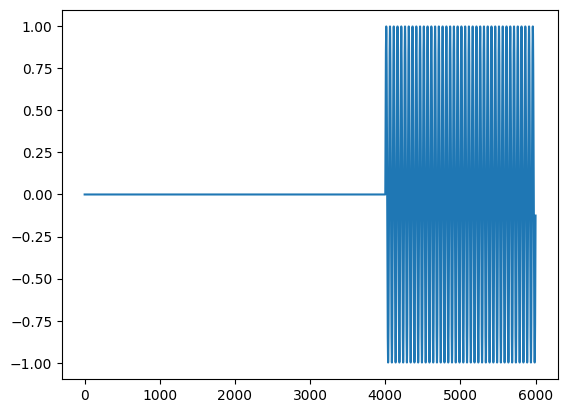

In [45]:
plt.plot(ui.signals[3])

In [49]:
import anywidget
import traitlets
import numpy as np


class SignalDraw(anywidget.AnyWidget):

    signals = traitlets.List([]).tag(sync=True)

    fs = traitlets.List([]).tag(sync=True)

    _esm = r"""

export function render({ model, el }) {

    // =====================================================
    // COLORS
    // =====================================================

    const COLORS = [
        "#0066ff",
        "#ff0000",
        "#00aa00",
        "#ff9900",
        "#9900ff"
    ];

    // =====================================================
    // ROOT
    // =====================================================

    const root = document.createElement("div");

    root.style.width = "100%";
    root.style.maxWidth = "1800px";
    root.style.background = "#efefef";
    root.style.padding = "8px";
    root.style.fontFamily = "Arial";
    root.style.boxSizing = "border-box";

    el.appendChild(root);

    // =====================================================
    // TOPBAR
    // =====================================================

    const topbar = document.createElement("div");

    topbar.style.display = "flex";
    topbar.style.alignItems = "center";
    topbar.style.gap = "12px";
    topbar.style.background = "white";
    topbar.style.padding = "8px";
    topbar.style.borderRadius = "6px";
    topbar.style.marginBottom = "8px";

    root.appendChild(topbar);

    // =====================================================
    // TITLE
    // =====================================================

    const title = document.createElement("h2");

    title.innerText = "SignalDraw";

    title.style.margin = "0";
    title.style.color = "#0066ff";
    title.style.marginRight = "auto";

    topbar.appendChild(title);

    // =====================================================
    // #SIGNALS
    // =====================================================

    const label =
        document.createElement("label");

    label.innerText = "#Signals";

    topbar.appendChild(label);

    const select =
        document.createElement("select");

    for(let i=1;i<=5;i++) {

        const op =
            document.createElement("option");

        op.value = i;
        op.text = i;

        if(i===1) op.selected = true;

        select.appendChild(op);
    }

    topbar.appendChild(select);

    // =====================================================
    // GENERATE BUTTON
    // =====================================================

    const btn =
        document.createElement("button");

    btn.innerText = "GENERATE";

    btn.style.padding = "6px 12px";
    btn.style.background = "#0066ff";
    btn.style.color = "white";
    btn.style.border = "none";
    btn.style.borderRadius = "5px";
    btn.style.cursor = "pointer";

    topbar.appendChild(btn);

    // =====================================================
    // RESET BUTTON
    // =====================================================

    const resetBtn =
        document.createElement("button");

    resetBtn.innerText = "RESET";

    resetBtn.style.padding = "6px 12px";
    resetBtn.style.background = "#ff4444";
    resetBtn.style.color = "white";
    resetBtn.style.border = "none";
    resetBtn.style.borderRadius = "5px";
    resetBtn.style.cursor = "pointer";

    topbar.appendChild(resetBtn);

    // =====================================================
    // MAIN
    // =====================================================

    const main = document.createElement("div");

    main.style.display = "flex";
    main.style.gap = "8px";

    root.appendChild(main);

    // =====================================================
    // LEFT PANEL
    // =====================================================

    const left =
        document.createElement("div");

    left.style.width = "25%";
    left.style.display = "flex";
    left.style.flexDirection = "column";
    left.style.gap = "8px";
    left.style.maxHeight = "1400px";
    left.style.overflowY = "auto";

    main.appendChild(left);

    // =====================================================
    // CENTER PANEL
    // =====================================================

    const center =
        document.createElement("div");

    center.style.width = "35%";
    center.style.display = "flex";
    center.style.flexDirection = "column";
    center.style.gap = "8px";

    main.appendChild(center);

    // =====================================================
    // RIGHT PANEL
    // =====================================================

    const right =
        document.createElement("div");

    right.style.width = "40%";
    right.style.display = "flex";
    right.style.flexDirection = "column";
    right.style.gap = "8px";

    main.appendChild(right);

    // =====================================================
    // CREATE CARD
    // =====================================================

    function createCard(titleText,height=260) {

        const card =
            document.createElement("div");

        card.style.background = "white";
        card.style.padding = "6px";
        card.style.borderRadius = "6px";

        const title =
            document.createElement("div");

        title.innerText = titleText;

        title.style.fontWeight = "bold";
        title.style.marginBottom = "4px";

        card.appendChild(title);

        const svg =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "svg"
            );

        svg.setAttribute("width","620");
        svg.setAttribute("height",height);

        svg.style.border =
            "1px solid #dddddd";

        card.appendChild(svg);

        return {
            card,
            svg
        };
    }

    // =====================================================
    // RESULT PLOTS
    // =====================================================

    const resultPlot =
        createCard(
            "Señal resultante",
            260
        );

    right.appendChild(
        resultPlot.card
    );

    const fftPlot =
        createCard(
            "FFT",
            260
        );

    right.appendChild(
        fftPlot.card
    );

    const stftPlot =
        createCard(
            "STFT Spectrogram",
            320
        );

    right.appendChild(
        stftPlot.card
    );

    // =====================================================
    // INPUT
    // =====================================================

    function createInput(label,value) {

        const c =
            document.createElement("div");

        c.style.display = "flex";
        c.style.flexDirection = "column";
        c.style.marginBottom = "6px";

        const l =
            document.createElement("label");

        l.innerText = label;

        l.style.fontSize = "12px";

        const i =
            document.createElement("input");

        i.type = "number";
        i.value = value;

        i.style.padding = "4px";

        c.appendChild(l);
        c.appendChild(i);

        return {
            container:c,
            input:i
        };
    }

    // =====================================================
    // SLIDER
    // =====================================================

    function createSlider(
        label,
        value,
        minVal=-5,
        maxVal=5
    ) {

        const c =
            document.createElement("div");

        c.style.display = "flex";
        c.style.flexDirection = "column";
        c.style.marginBottom = "6px";

        const row =
            document.createElement("div");

        row.style.display = "flex";

        row.style.justifyContent =
            "space-between";

        const l =
            document.createElement("label");

        l.innerText = label;

        const valueText =
            document.createElement("span");

        valueText.innerText =
            parseFloat(value).toFixed(1);

        valueText.style.fontWeight = "bold";
        valueText.style.color = "#0066ff";

        row.appendChild(l);
        row.appendChild(valueText);

        const s =
            document.createElement("input");

        s.type = "range";

        s.min = minVal;
        s.max = maxVal;
        s.step = 0.1;
        s.value = value;

        s.addEventListener("input",()=>{

            valueText.innerText =
                parseFloat(s.value).toFixed(1);
        });

        c.appendChild(row);
        c.appendChild(s);

        return {
            container:c,
            slider:s
        };
    }

    // =====================================================
    // GRID
    // =====================================================

    function drawGrid(
        svg,
        w,
        h
    ) {

        svg.innerHTML = "";

        for(let x=50;x<w;x+=40) {

            const line =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "line"
                );

            line.setAttribute("x1",x);
            line.setAttribute("y1",10);

            line.setAttribute("x2",x);
            line.setAttribute("y2",h-30);

            line.setAttribute(
                "stroke",
                "#ededed"
            );

            svg.appendChild(line);
        }

        for(let y=20;y<h-30;y+=40) {

            const line =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "line"
                );

            line.setAttribute("x1",50);
            line.setAttribute("y1",y);

            line.setAttribute("x2",w);
            line.setAttribute("y2",y);

            line.setAttribute(
                "stroke",
                "#ededed"
            );

            svg.appendChild(line);
        }

        const xAxis =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "line"
            );

        xAxis.setAttribute("x1",50);
        xAxis.setAttribute("y1",h/2);

        xAxis.setAttribute("x2",w);
        xAxis.setAttribute("y2",h/2);

        xAxis.setAttribute(
            "stroke",
            "#666"
        );

        svg.appendChild(xAxis);

        const yAxis =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "line"
            );

        yAxis.setAttribute("x1",50);
        yAxis.setAttribute("y1",10);

        yAxis.setAttribute("x2",50);
        yAxis.setAttribute("y2",h-30);

        yAxis.setAttribute(
            "stroke",
            "#666"
        );

        svg.appendChild(yAxis);
    }

    // =====================================================
    // DRAW SIGNAL
    // =====================================================

    function drawSignal(
        svg,
        signal,
        color,
        totalTime
    ) {

        const w =
            parseInt(
                svg.getAttribute("width")
            );

        const h =
            parseInt(
                svg.getAttribute("height")
            );

        drawGrid(svg,w,h);

        let peak =
            Math.max(
                ...signal.map(
                    v=>Math.abs(v)
                )
            );

        if(peak < 0.001)
            peak = 1;

        const scale =
            (h*0.35)/peak;

        let path = "";

        for(let i=0;i<signal.length;i++) {

            const x =
                50 +
                i*((w-70)/signal.length);

            const y =
                h/2 -
                signal[i]*scale;

            if(i===0) {

                path += `M ${x} ${y}`;

            } else {

                path += ` L ${x} ${y}`;
            }
        }

        const curve =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "path"
            );

        curve.setAttribute("d",path);

        curve.setAttribute(
            "stroke",
            color
        );

        curve.setAttribute(
            "stroke-width",
            "2"
        );

        curve.setAttribute(
            "fill",
            "none"
        );

        svg.appendChild(curve);

        const txt =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "text"
            );

        txt.setAttribute("x",w-140);

        txt.setAttribute("y","18");

        txt.setAttribute(
            "font-size",
            "11"
        );

        txt.textContent =
            "Peak: ±" +
            peak.toFixed(2);

        svg.appendChild(txt);

        for(let i=0;i<=10;i++) {

            const t =
                i * totalTime / 10;

            const x =
                50 +
                i*((w-70)/10);

            const txt =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "text"
                );

            txt.setAttribute("x",x-8);

            txt.setAttribute("y",h-12);

            txt.setAttribute(
                "font-size",
                "10"
            );

            txt.textContent =
                t.toFixed(1);

            svg.appendChild(txt);
        }
    }

"""
    
    @property
    def signal_numpy(self):

        return np.array(self.signals[0])


    @property
    def signals_numpy(self):

        return [
            np.array(s)
            for s in self.signals
        ]


ui = SignalDraw()

ui

In [50]:


import anywidget
import traitlets
import numpy as np


class SignalDraw(anywidget.AnyWidget):

    signals = traitlets.List([]).tag(sync=True)

    fs = traitlets.List([]).tag(sync=True)

    _esm = r"""

export function render({ model, el }) {

    // =====================================================
    // COLORS
    // =====================================================

    const COLORS = [
        "#0066ff",
        "#ff0000",
        "#00aa00",
        "#ff9900",
        "#9900ff"
    ];

    // =====================================================
    // ROOT
    // =====================================================

    const root = document.createElement("div");

    root.style.width = "100%";
    root.style.maxWidth = "1800px";
    root.style.background = "#efefef";
    root.style.padding = "8px";
    root.style.fontFamily = "Arial";

    el.appendChild(root);

    // =====================================================
    // TOPBAR
    // =====================================================

    const topbar = document.createElement("div");

    topbar.style.display = "flex";
    topbar.style.alignItems = "center";
    topbar.style.gap = "12px";
    topbar.style.background = "white";
    topbar.style.padding = "8px";
    topbar.style.borderRadius = "6px";
    topbar.style.marginBottom = "8px";

    root.appendChild(topbar);

    const title = document.createElement("h2");

    title.innerText = "SignalDraw";

    title.style.margin = "0";
    title.style.color = "#0066ff";
    title.style.marginRight = "auto";

    topbar.appendChild(title);

    // =====================================================
    // #SIGNALS
    // =====================================================

    const label =
        document.createElement("label");

    label.innerText = "#Signals";

    topbar.appendChild(label);

    const select =
        document.createElement("select");

    for(let i=1;i<=5;i++) {

        const op =
            document.createElement("option");

        op.value = i;
        op.text = i;

        if(i===1)
            op.selected = true;

        select.appendChild(op);
    }

    topbar.appendChild(select);

    // =====================================================
    // GENERATE BUTTON
    // =====================================================

    const btn =
        document.createElement("button");

    btn.innerText = "GENERATE";

    btn.style.padding = "6px 12px";
    btn.style.background = "#0066ff";
    btn.style.color = "white";
    btn.style.border = "none";
    btn.style.borderRadius = "5px";
    btn.style.cursor = "pointer";

    topbar.appendChild(btn);

    // =====================================================
    // RESET BUTTON
    // =====================================================

    const resetBtn =
        document.createElement("button");

    resetBtn.innerText = "RESET";

    resetBtn.style.padding = "6px 12px";
    resetBtn.style.background = "#ff4444";
    resetBtn.style.color = "white";
    resetBtn.style.border = "none";
    resetBtn.style.borderRadius = "5px";
    resetBtn.style.cursor = "pointer";

    topbar.appendChild(resetBtn);

    // =====================================================
    // MAIN
    // =====================================================

    const main = document.createElement("div");

    main.style.display = "flex";
    main.style.gap = "8px";

    root.appendChild(main);

    // =====================================================
    // LEFT PANEL
    // =====================================================

    const left =
        document.createElement("div");

    left.style.width = "25%";
    left.style.display = "flex";
    left.style.flexDirection = "column";
    left.style.gap = "8px";
    left.style.maxHeight = "1400px";
    left.style.overflowY = "auto";

    main.appendChild(left);

    // =====================================================
    // CENTER PANEL
    // =====================================================

    const center =
        document.createElement("div");

    center.style.width = "35%";
    center.style.display = "flex";
    center.style.flexDirection = "column";
    center.style.gap = "8px";

    main.appendChild(center);

    // =====================================================
    // RIGHT PANEL
    // =====================================================

    const right =
        document.createElement("div");

    right.style.width = "40%";
    right.style.display = "flex";
    right.style.flexDirection = "column";
    right.style.gap = "8px";

    main.appendChild(right);

    // =====================================================
    // CREATE CARD
    // =====================================================

    function createCard(titleText,height=260) {

        const card =
            document.createElement("div");

        card.style.background = "white";
        card.style.padding = "6px";
        card.style.borderRadius = "6px";

        const title =
            document.createElement("div");

        title.innerText = titleText;

        title.style.fontWeight = "bold";
        title.style.marginBottom = "4px";

        card.appendChild(title);

        const svg =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "svg"
            );

        svg.setAttribute("width","620");
        svg.setAttribute("height",height);

        svg.style.border =
            "1px solid #dddddd";

        card.appendChild(svg);

        return {
            card,
            svg
        };
    }

    // =====================================================
    // RESULT PLOTS
    // =====================================================

    const resultPlot =
        createCard(
            "Señal resultante",
            260
        );

    right.appendChild(
        resultPlot.card
    );

    const fftPlot =
        createCard(
            "FFT",
            260
        );

    right.appendChild(
        fftPlot.card
    );

    const stftPlot =
        createCard(
            "STFT Spectrogram",
            320
        );

    right.appendChild(
        stftPlot.card
    );

    // =====================================================
    // INPUT
    // =====================================================

    function createInput(label,value) {

        const c =
            document.createElement("div");

        c.style.display = "flex";
        c.style.flexDirection = "column";
        c.style.marginBottom = "6px";

        const l =
            document.createElement("label");

        l.innerText = label;

        l.style.fontSize = "12px";

        const i =
            document.createElement("input");

        i.type = "number";
        i.value = value;

        i.style.padding = "4px";

        c.appendChild(l);
        c.appendChild(i);

        return {
            container:c,
            input:i
        };
    }

    // =====================================================
    // SLIDER
    // =====================================================

    function createSlider(
        label,
        value,
        minVal=-5,
        maxVal=5
    ) {

        const c =
            document.createElement("div");

        c.style.display = "flex";
        c.style.flexDirection = "column";
        c.style.marginBottom = "6px";

        const row =
            document.createElement("div");

        row.style.display = "flex";
        row.style.justifyContent =
            "space-between";

        const l =
            document.createElement("label");

        l.innerText = label;

        const valueText =
            document.createElement("span");

        valueText.innerText =
            parseFloat(value).toFixed(1);

        valueText.style.fontWeight = "bold";
        valueText.style.color = "#0066ff";

        row.appendChild(l);
        row.appendChild(valueText);

        const s =
            document.createElement("input");

        s.type = "range";

        s.min = minVal;
        s.max = maxVal;
        s.step = 0.1;
        s.value = value;

        s.addEventListener("input",()=>{

            valueText.innerText =
                parseFloat(s.value).toFixed(1);
        });

        c.appendChild(row);
        c.appendChild(s);

        return {
            container:c,
            slider:s
        };
    }

    // =====================================================
    // GRID
    // =====================================================

    function drawGrid(
        svg,
        w,
        h
    ) {

        svg.innerHTML = "";

        for(let x=50;x<w;x+=40) {

            const line =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "line"
                );

            line.setAttribute("x1",x);
            line.setAttribute("y1",10);

            line.setAttribute("x2",x);
            line.setAttribute("y2",h-30);

            line.setAttribute(
                "stroke",
                "#ededed"
            );

            svg.appendChild(line);
        }

        for(let y=20;y<h-30;y+=40) {

            const line =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "line"
                );

            line.setAttribute("x1",50);
            line.setAttribute("y1",y);

            line.setAttribute("x2",w);
            line.setAttribute("y2",y);

            line.setAttribute(
                "stroke",
                "#ededed"
            );

            svg.appendChild(line);
        }

        const xAxis =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "line"
            );

        xAxis.setAttribute("x1",50);
        xAxis.setAttribute("y1",h/2);

        xAxis.setAttribute("x2",w);
        xAxis.setAttribute("y2",h/2);

        xAxis.setAttribute(
            "stroke",
            "#666"
        );

        svg.appendChild(xAxis);

        const yAxis =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "line"
            );

        yAxis.setAttribute("x1",50);
        yAxis.setAttribute("y1",10);

        yAxis.setAttribute("x2",50);
        yAxis.setAttribute("y2",h-30);

        yAxis.setAttribute(
            "stroke",
            "#666"
        );

        svg.appendChild(yAxis);
    }

    // =====================================================
    // DRAW SIGNAL
    // =====================================================

    function drawSignal(
        svg,
        signal,
        color,
        totalTime
    ) {

        const w =
            parseInt(
                svg.getAttribute("width")
            );

        const h =
            parseInt(
                svg.getAttribute("height")
            );

        drawGrid(svg,w,h);

        let peak =
            Math.max(
                ...signal.map(
                    v=>Math.abs(v)
                )
            );

        if(peak < 0.001)
            peak = 1;

        const scale =
            (h*0.35)/peak;

        let path = "";

        for(let i=0;i<signal.length;i++) {

            const x =
                50 +
                i*((w-70)/signal.length);

            const y =
                h/2 -
                signal[i]*scale;

            if(i===0) {

                path += `M ${x} ${y}`;

            } else {

                path += ` L ${x} ${y}`;
            }
        }

        const curve =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "path"
            );

        curve.setAttribute("d",path);

        curve.setAttribute(
            "stroke",
            color
        );

        curve.setAttribute(
            "stroke-width",
            "2"
        );

        curve.setAttribute(
            "fill",
            "none"
        );

        svg.appendChild(curve);

        // PEAK

        const txt =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "text"
            );

        txt.setAttribute("x",w-140);
        txt.setAttribute("y","18");

        txt.setAttribute(
            "font-size",
            "11"
        );

        txt.textContent =
            "Peak: ±" +
            peak.toFixed(2);

        svg.appendChild(txt);

        // TIME LABELS

        for(let i=0;i<=10;i++) {

            const t =
                i * totalTime / 10;

            const x =
                50 +
                i*((w-70)/10);

            const txt =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "text"
                );

            txt.setAttribute("x",x-8);
            txt.setAttribute("y",h-12);

            txt.setAttribute(
                "font-size",
                "10"
            );

            txt.textContent =
                t.toFixed(1);

            svg.appendChild(txt);
        }
    }

    // =====================================================
    // FFT
    // =====================================================

    function computeFFT(signal, fs) {

        const N = signal.length;

        const halfN =
            Math.floor(N/2);

        let freqs = [];
        let mags = [];

        for(let k=0;k<halfN;k++) {

            let re = 0;
            let im = 0;

            for(let n=0;n<N;n++) {

                const angle =
                    2*Math.PI*k*n/N;

                re +=
                    signal[n] *
                    Math.cos(angle);

                im -=
                    signal[n] *
                    Math.sin(angle);
            }

            const mag =
                Math.sqrt(re*re+im*im)/N;

            freqs.push(k*fs/N);

            mags.push(mag);
        }

        return {
            freqs,
            mags
        };
    }

    // =====================================================
    // DRAW FFT
    // =====================================================

    function drawFFT(
        svg,
        freqs,
        mags,
        fs
    ) {

        const w =
            parseInt(
                svg.getAttribute("width")
            );

        const h =
            parseInt(
                svg.getAttribute("height")
            );

        drawGrid(svg,w,h);

        let maxVal =
            Math.max(...mags);

        if(maxVal < 1e-9)
            maxVal = 1;

        const norm =
            mags.map(v=>v/maxVal);

        const significant =
            freqs.filter(
                (f,i)=>norm[i] > 0.1
            );

        let maxFreq;

        if(significant.length>0) {

            maxFreq =
                Math.max(...significant)*1.4;

        } else {

            maxFreq = fs/2;
        }

        if(maxFreq < 20)
            maxFreq = 20;

        for(let i=0;i<freqs.length;i++) {

            if(freqs[i] > maxFreq)
                continue;

            const x =
                50 +
                (freqs[i]/maxFreq) *
                (w-70);

            const y =
                h-30 -
                norm[i]*(h*0.7);

            const line =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "line"
                );

            line.setAttribute("x1",x);
            line.setAttribute("y1",h-30);

            line.setAttribute("x2",x);
            line.setAttribute("y2",y);

            line.setAttribute(
                "stroke",
                "#00aa00"
            );

            line.setAttribute(
                "stroke-width",
                "2"
            );

            svg.appendChild(line);
        }
    }

    // =====================================================
    // STFT
    // =====================================================

    function computeSTFT(
        signal,
        fs,
        windowSize=256,
        hopSize=64
    ) {

        let spectrogram = [];

        for(
            let start=0;
            start<signal.length-windowSize;
            start+=hopSize
        ) {

            const segment =
                signal.slice(
                    start,
                    start+windowSize
                );

            let mags = [];

            for(let k=0;k<windowSize/2;k++) {

                let re = 0;
                let im = 0;

                for(let n=0;n<windowSize;n++) {

                    const angle =
                        2*Math.PI*k*n/windowSize;

                    re +=
                        segment[n] *
                        Math.cos(angle);

                    im -=
                        segment[n] *
                        Math.sin(angle);
                }

                const mag =
                    Math.sqrt(re*re+im*im);

                mags.push(mag);
            }

            spectrogram.push(mags);
        }

        return spectrogram;
    }

    // =====================================================
    // DRAW STFT
    // =====================================================

    function drawSTFT(
        svg,
        spectrogram,
        fs,
        totalTime
    ) {

        svg.innerHTML = "";

        const w =
            parseInt(
                svg.getAttribute("width")
            );

        const h =
            parseInt(
                svg.getAttribute("height")
            );

        const cols =
            spectrogram.length;

        const rows =
            spectrogram[0].length;

        let maxVal = 0;

        for(let x=0;x<cols;x++) {

            for(let y=0;y<rows;y++) {

                if(
                    spectrogram[x][y]
                    > maxVal
                ) {

                    maxVal =
                        spectrogram[x][y];
                }
            }
        }

        // AUTO SCALE

        let maxRow = rows;

        for(let y=rows-1;y>=0;y--) {

            let found = false;

            for(let x=0;x<cols;x++) {

                const val =
                    spectrogram[x][y]/maxVal;

                if(val > 0.05) {

                    found = true;
                    break;
                }
            }

            if(found) {

                maxRow = y + 8;
                break;
            }
        }

        if(maxRow < 16)
            maxRow = 16;

        maxRow =
            Math.min(maxRow,rows);

        // HEATMAP

        for(let x=0;x<cols;x++) {

            for(let y=0;y<maxRow;y++) {

                const val =
                    spectrogram[x][y]/maxVal;

                const logVal =
                    Math.log10(
                        1 + 9*val
                    );

                const rect =
                    document.createElementNS(
                        "http://www.w3.org/2000/svg",
                        "rect"
                    );

                const px =
                    50 +
                    x*((w-70)/cols);

                const py =
                    h-30 -
                    ((y/maxRow)*(h-40));

                rect.setAttribute("x",px);
                rect.setAttribute("y",py);

                rect.setAttribute(
                    "width",
                    (w-70)/cols + 1
                );

                rect.setAttribute(
                    "height",
                    (h-40)/maxRow + 1
                );

                const r =
                    Math.floor(
                        255*logVal
                    );

                const g =
                    Math.floor(
                        180*logVal
                    );

                const b =
                    Math.floor(
                        255*(1-logVal)
                    );

                rect.setAttribute(
                    "fill",
                    `rgb(${r},${g},${b})`
                );

                svg.appendChild(rect);
            }
        }

        // AXES

        const xAxis =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "line"
            );

        xAxis.setAttribute("x1",50);
        xAxis.setAttribute("y1",h-30);

        xAxis.setAttribute("x2",w);
        xAxis.setAttribute("y2",h-30);

        xAxis.setAttribute(
            "stroke",
            "#666"
        );

        svg.appendChild(xAxis);

        const yAxis =
            document.createElementNS(
                "http://www.w3.org/2000/svg",
                "line"
            );

        yAxis.setAttribute("x1",50);
        yAxis.setAttribute("y1",10);

        yAxis.setAttribute("x2",50);
        yAxis.setAttribute("y2",h-30);

        yAxis.setAttribute(
            "stroke",
            "#666"
        );

        svg.appendChild(yAxis);

        // TIME LABELS

        for(let i=0;i<=10;i++) {

            const t =
                i * totalTime / 10;

            const x =
                50 +
                i*((w-70)/10);

            const txt =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "text"
                );

            txt.setAttribute("x",x-8);
            txt.setAttribute("y",h-10);

            txt.setAttribute(
                "font-size",
                "10"
            );

            txt.textContent =
                t.toFixed(1);

            svg.appendChild(txt);
        }

        // FREQ LABELS

        const maxFreq =
            (maxRow/rows) *
            (fs/2);

        for(let i=0;i<=5;i++) {

            const f =
                i * maxFreq / 5;

            const y =
                h-30 -
                i*((h-40)/5);

            const txt =
                document.createElementNS(
                    "http://www.w3.org/2000/svg",
                    "text"
                );

            txt.setAttribute("x","5");
            txt.setAttribute("y",y+4);

            txt.setAttribute(
                "font-size",
                "10"
            );

            txt.textContent =
                f.toFixed(0);

            svg.appendChild(txt);
        }
    }

    // =====================================================
    // CONFIGS
    // =====================================================

    let configs = [];

    // =====================================================
    // SAVE STATE
    // =====================================================

    function saveCurrentState() {

        return configs.map(cfg => ({

            fs:
                cfg.fs.input.value,

            freq:
                cfg.freq.input.value,

            amp:
                cfg.amp.slider.value,

            phase:
                cfg.phase.input.value,

            offset:
                cfg.offset.slider.value,

            startTime:
                cfg.startTime.input.value,

            endTime:
                cfg.endTime.input.value
        }));
    }

    // =====================================================
    // BUILD UI
    // =====================================================

    function buildUI(previousState=[]) {

        left.innerHTML = "";
        center.innerHTML = "";

        configs = [];

        const n =
            parseInt(select.value);

        for(let i=0;i<n;i++) {

            const prev =
                previousState[i] || {};

            const card =
                document.createElement("div");

            card.style.background = "white";
            card.style.padding = "8px";
            card.style.borderRadius = "6px";

            card.style.borderLeft =
                "4px solid " + COLORS[i];

            const title =
                document.createElement("div");

            title.innerText =
                "Signal " + (i+1);

            title.style.fontWeight = "bold";
            title.style.color = COLORS[i];

            card.appendChild(title);

            const fs =
                createInput(
                    "Fs",
                    prev.fs || 1000
                );

            const freq =
                createInput(
                    "Frequency",
                    prev.freq || (5+i)
                );

            const amp =
                createSlider(
                    "Amplitude",
                    prev.amp || 1,
                    0,
                    5
                );

            const phase =
                createInput(
                    "Phase",
                    prev.phase || 0
                );

            const offset =
                createSlider(
                    "Offset DC",
                    prev.offset || 0,
                    -5,
                    5
                );

            const startTime =
                createInput(
                    "Start Time (s)",
                    prev.startTime || 0
                );

            const endTime =
                createInput(
                    "End Time (s)",
                    prev.endTime || 6
                );

            card.appendChild(fs.container);
            card.appendChild(freq.container);
            card.appendChild(amp.container);
            card.appendChild(phase.container);
            card.appendChild(offset.container);
            card.appendChild(startTime.container);
            card.appendChild(endTime.container);

            left.appendChild(card);

            const graph =
                createCard(
                    "Signal " + (i+1),
                    180
                );

            center.appendChild(
                graph.card
            );

            configs.push({

                fs,
                freq,
                amp,
                phase,
                offset,
                startTime,
                endTime,
                svg:graph.svg,
                color:COLORS[i]
            });
        }
    }

    // =====================================================
    // GENERATE
    // =====================================================

    function generate() {

        let totalTime = 0;

        configs.forEach(cfg => {

            const endT =
                parseFloat(
                    cfg.endTime.input.value
                );

            if(endT > totalTime)
                totalTime = endT;
        });

        const commonFs = 1000;

        const totalSamples =
            Math.floor(
                totalTime * commonFs
            );

        let total =
            new Array(totalSamples).fill(0);

        let allSignals = [];

        let allFs = [];

        configs.forEach(cfg => {

            const fs =
                parseFloat(
                    cfg.fs.input.value
                );

            const amp =
                parseFloat(
                    cfg.amp.slider.value
                );

            const freq =
                parseFloat(
                    cfg.freq.input.value
                );

            const phase =
                parseFloat(
                    cfg.phase.input.value
                );

            const offset =
                parseFloat(
                    cfg.offset.slider.value
                );

            const startT =
                parseFloat(
                    cfg.startTime.input.value
                );

            const endT =
                parseFloat(
                    cfg.endTime.input.value
                );

            let signal =
                new Array(totalSamples).fill(0);

            for(let i=0;i<totalSamples;i++) {

                const t = i/commonFs;

                if(
                    t >= startT &&
                    t <= endT
                ) {

                    signal[i] =
                        offset +
                        amp *
                        Math.sin(
                            2*Math.PI*
                            freq*
                            (t-startT)+
                            phase
                        );
                }
            }

            allSignals.push(signal);

            allFs.push(fs);

            total =
                total.map(
                    (v,i)=>v+signal[i]
                );

            drawSignal(
                cfg.svg,
                signal,
                cfg.color,
                totalTime
            );
        });

        allSignals.unshift(total);

        const allEqualFs =
            allFs.every(
                v => v === allFs[0]
            );

        if(allEqualFs) {

            allFs.unshift(allFs[0]);

        } else {

            allFs.unshift(0);
        }

        drawSignal(
            resultPlot.svg,
            total,
            "#0066ff",
            totalTime
        );

        const fft =
            computeFFT(
                total,
                commonFs
            );

        drawFFT(
            fftPlot.svg,
            fft.freqs,
            fft.mags,
            commonFs
        );

        const spectrogram =
            computeSTFT(
                total,
                commonFs
            );

        drawSTFT(
            stftPlot.svg,
            spectrogram,
            commonFs,
            totalTime
        );

        model.set(
            "signals",
            allSignals
        );

        model.set(
            "fs",
            allFs
        );

        model.save_changes();
    }

    // =====================================================
    // EVENTS
    // =====================================================

    select.addEventListener(
        "change",
        ()=>{

            const prev =
                saveCurrentState();

            buildUI(prev);

            generate();
        }
    );

    btn.addEventListener(
        "click",
        generate
    );

    resetBtn.addEventListener(
        "click",
        ()=>{

            buildUI();

            generate();
        }
    );

    // =====================================================
    // INIT
    // =====================================================

    buildUI();

    generate();
}
"""

    @property
    def signal_numpy(self):

        return np.array(self.signals[0])


    @property
    def signals_numpy(self):

        return [
            np.array(s)
            for s in self.signals
        ]


ui = SignalDraw()

ui